# 🔋🔌**Data Cleaning & EDA of EV charging stations in New Zealand** 🇳🇿

![](https://i.postimg.cc/QC5FPRj0/ev-charging-station-banner.png)

## **About Dataset**
This dataset is having details of 609 EV charging stations in New Zealand extracted from the official website of NZTA (New Zealand Transport Agency).

### Dataset column names:
- **OBJECTID** - Integer unique ID for every EV charging station
- **Name** - Name of the location where the EV charging station is located.
- **Operator** - Name of the Charge Point Operator which powers the chargers in the EV charging station.
- **Owner** - Name of the owner of the EV charging station.
- **Address** - Address of the EV charging station
- **Is 24 Hours** - Boolean representing if the EV charging station is open for 24 hours or not.
- **Car Park Count** - Number of car parks in the EV charging station.
- **Has Carpark cost** - Boolean representing if there is car parking fees in the EV charging station.
- **Max Time Limit** - Maximum time limit for charging an electric vehicle by customer.
- **Has Tourist Attraction** - Boolean representing if the EV electric station has a tourist attraction or not.
- **Latitude** - Latitude of the place where the EV charging station is located.
- **Longitude** - Longitude of the place where the EV charging station is located.
- **Current Type** - String representing the type of current used to power the electric vehicle as DC/AC/Mixed.
- **Date First Operational** - Date in which the EV charging station is opened to the public.
- **Number Of Connectors** - Number of connectors present in the EV charging station.
- **Connectors List** - Details of the different types of connectors in the EV charging station such as power in kW, current type, status of the connectors, number of connectors of that type.
- **Has Charging Cost** - Boolean representing if the EV charging station has paid charging or not.
- **GlobalID** - String unique global ID of the EV charging station.

# 🎯 Objectives:
- Clean and preprocess the dataset to ensure data quality  
- Perform exploratory data analysis (EDA) and visualizations  
- Analyze the geographical distribution of EV charging stations across New Zealand  
- Examine the types and availability of connectors at each station  
- Compare regions and Charge Point Operators based on the availability of high-power connectors for fast charging
- Identify top regions with AC and DC charging infrastructure  
- Explore the distribution of charging stations across the North and South Islands  
- Generate insights into the current EV charging network and technologies in New Zealand

# 📦 **Importing libraries**

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import plotly.express as px
import os

# 📂 **Loading Dataset**

In [2]:
os.makedirs("/kaggle/working/plots/",exist_ok=True)
ev_charging_stations = pd.read_csv("/kaggle/input/datasets/reshmaharidhas/ev-charging-stations-in-new-zealand/EV_Roam_charging_stations_5887486187391234133.csv")
pd.set_option("display.max_columns",None)
ev_charging_stations

,OBJECTID,Name,Operator,Owner,Address,Is 24 Hours,Car Park Count,Has Carpark Cost,Max Time Limit,Has Tourist Attraction,Latitude,Longitude,Current Type,Date First Operational,Number Of Connectors,Connectors List,Has Charging Cost,GlobalID,x,y
0,598672,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,b9f22b5c-54dc-48da-98f2-1ac2af149f91,1.770264e+06,5.907314e+06
1,598673,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,False,-37.778157,175.308059,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,ed446dbb-9e9f-4c91-9155-f6d160ce771e,1.803264e+06,5.816290e+06
2,598674,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,False,-38.008093,175.324989,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,64c5ea2b-f920-4a29-ab6e-8afa034924f3,1.804119e+06,5.790736e+06
3,598675,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,False,-37.788108,175.258356,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,22dd5118-54ca-45fe-b979-bb8aab8c6a92,1.798860e+06,5.815292e+06
4,598676,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,False,-37.793170,175.280269,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,0a0584a9-04fa-4d69-8272-ed30864d2366,1.800776e+06,5.814684e+06
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,599276,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,32e0c236-8d04-43b1-bf89-83fd5edd3c64,1.343472e+06,4.850458e+06
605,599277,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,d5358d41-b7cd-4f1b-a6bb-7800c7dc798c,1.329324e+06,4.837924e+06
606,599278,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",True,1,False,Unlimited,False,-46.571653,168.795896,DC,9/12/2021 12:00:00 AM,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,c3622690-f97a-41d5-a619-fa665f9a84c4,1.277851e+06,4.833844e+06
607,599279,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",True,1,False,Unlimited,False,-46.599706,168.345328,DC,10/2/2019 12:00:00 AM,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,9d45877e-6cbd-479c-b069-6ace64f943e1,1.243513e+06,4.828785e+06


# 🔍 **Initial Data Exploration (EDA)**

### **Shape and structure**

In [3]:
ev_charging_stations.shape

(609, 20)

### **Descriptive analysis**

In [4]:
ev_charging_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 20 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   OBJECTID                609 non-null    int64  
 1   Name                    609 non-null    object 
 2   Operator                609 non-null    object 
 3   Owner                   609 non-null    object 
 4   Address                 609 non-null    object 
 5   Is 24 Hours             609 non-null    bool   
 6   Car Park Count          609 non-null    int64  
 7   Has Carpark Cost        609 non-null    bool   
 8   Max Time Limit          605 non-null    object 
 9   Has Tourist Attraction  609 non-null    bool   
 10  Latitude                609 non-null    float64
 11  Longitude               609 non-null    float64
 12  Current Type            609 non-null    object 
 13  Date First Operational  571 non-null    object 
 14  Number Of Connectors    609 non-null    in

In [5]:
ev_charging_stations.describe()

,OBJECTID,Car Park Count,Latitude,Longitude,Number Of Connectors,x,y
count,609.000000,609.000000,609.000000,609.000000,609.000000,6.090000e+02,6.090000e+02
mean,598976.000000,1.433498,-40.072558,174.004981,3.072250,1.691409e+06,5.561767e+06
std,175.947435,1.011087,3.096443,1.970079,1.758822,1.636722e+05,3.440405e+05
min,598672.000000,1.000000,-46.660900,167.689386,1.000000,1.186312e+06,4.825128e+06
25%,598824.000000,1.000000,-43.323987,172.664343,2.000000,1.572785e+06,5.203151e+06
50%,598976.000000,1.000000,-39.925800,174.771810,2.000000,1.751225e+06,5.578485e+06
75%,599128.000000,1.000000,-36.998846,175.038707,4.000000,1.777729e+06,5.903714e+06
max,599280.000000,14.000000,-34.517702,178.369254,18.000000,2.073918e+06,6.180428e+06


### **Count of missing values**

In [6]:
ev_charging_stations.isna().sum()

OBJECTID                   0
Name                       0
Operator                   0
Owner                      0
Address                    0
Is 24 Hours                0
Car Park Count             0
Has Carpark Cost           0
Max Time Limit             4
Has Tourist Attraction     0
Latitude                   0
Longitude                  0
Current Type               0
Date First Operational    38
Number Of Connectors       0
Connectors List            0
Has Charging Cost          0
GlobalID                   0
x                          0
y                          0
dtype: int64

### **Checking Duplicates**

In [7]:
ev_charging_stations[ev_charging_stations.duplicated]

,OBJECTID,Name,Operator,Owner,Address,Is 24 Hours,Car Park Count,Has Carpark Cost,Max Time Limit,Has Tourist Attraction,Latitude,Longitude,Current Type,Date First Operational,Number Of Connectors,Connectors List,Has Charging Cost,GlobalID,x,y


#### Observations:
- No duplicate rows are present in this dataset.

# 🧹 **Data Cleaning**

## **Dropping irrelevant columns**

In [8]:
ev_charging_stations.drop(columns=["x","y"],inplace=True)
ev_charging_stations.head()

,OBJECTID,Name,Operator,Owner,Address,Is 24 Hours,Car Park Count,Has Carpark Cost,Max Time Limit,Has Tourist Attraction,Latitude,Longitude,Current Type,Date First Operational,Number Of Connectors,Connectors List,Has Charging Cost,GlobalID
0,598672,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,b9f22b5c-54dc-48da-98f2-1ac2af149f91
1,598673,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,False,-37.778157,175.308059,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,ed446dbb-9e9f-4c91-9155-f6d160ce771e
2,598674,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,False,-38.008093,175.324989,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,64c5ea2b-f920-4a29-ab6e-8afa034924f3
3,598675,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,False,-37.788108,175.258356,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,22dd5118-54ca-45fe-b979-bb8aab8c6a92
4,598676,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,False,-37.793170,175.280269,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,0a0584a9-04fa-4d69-8272-ed30864d2366


In [9]:
ev_charging_stations["OBJECTID"].value_counts()

OBJECTID
599280    1
599264    1
599263    1
599262    1
599261    1
         ..
598677    1
598676    1
598675    1
598674    1
598673    1
Name: count, Length: 609, dtype: int64

In [10]:
ev_charging_stations["GlobalID"].value_counts()

GlobalID
36d2ee86-f22f-4e8a-9577-85a3069756a5    1
d51863f5-0f73-431c-aed1-966386fd94cf    1
d6367b8f-01e9-4e62-8ebe-f8f19c34688b    1
1d265d03-973c-4c09-af75-bbd5e8f8d844    1
5bd17088-18d7-4723-b64a-bada999544e4    1
                                       ..
5fca78c4-d147-4eb9-b85f-9743d3f6fad2    1
0a0584a9-04fa-4d69-8272-ed30864d2366    1
22dd5118-54ca-45fe-b979-bb8aab8c6a92    1
64c5ea2b-f920-4a29-ab6e-8afa034924f3    1
ed446dbb-9e9f-4c91-9155-f6d160ce771e    1
Name: count, Length: 609, dtype: int64

In [11]:
ev_charging_stations.drop(columns=["OBJECTID","GlobalID"],inplace=True)
ev_charging_stations.head()

,Name,Operator,Owner,Address,Is 24 Hours,Car Park Count,Has Carpark Cost,Max Time Limit,Has Tourist Attraction,Latitude,Longitude,Current Type,Date First Operational,Number Of Connectors,Connectors List,Has Charging Cost
0,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,False,-37.778157,175.308059,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,False,-38.008093,175.324989,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,False,-37.788108,175.258356,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,False,-37.793170,175.280269,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True


## **Standardizing column names**

In [12]:
ev_charging_stations.columns = ev_charging_stations.columns.str.strip().str.lower().str.replace(" ","_")
ev_charging_stations.head()

,name,operator,owner,address,is_24_hours,car_park_count,has_carpark_cost,max_time_limit,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,number_of_connectors,connectors_list,has_charging_cost
0,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,False,-37.778157,175.308059,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,False,-38.008093,175.324989,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,False,-37.788108,175.258356,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,False,-37.793170,175.280269,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True


## **Renaming column names**

In [13]:
ev_charging_stations = ev_charging_stations.rename(columns={ev_charging_stations.columns[4]:"is_open_24_hours",ev_charging_stations.columns[0]:"location_name",ev_charging_stations.columns[1]:"charge_point_operator",ev_charging_stations.columns[3]:"full_address"})
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,number_of_connectors,connectors_list,has_charging_cost
0,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,False,-37.778157,175.308059,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,False,-38.008093,175.324989,AC,NaN,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,False,-37.788108,175.258356,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,False,-37.793170,175.280269,AC,NaN,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True


## **Changing position of columns**

In [14]:
number_of_connectors_popped = ev_charging_stations.pop("number_of_connectors")
ev_charging_stations.insert(8,"number_of_connectors",number_of_connectors_popped)
connectors_details_popped = ev_charging_stations.pop("connectors_list")
ev_charging_stations.insert(9,"connectors_list",connectors_details_popped)
has_charging_cost_popped = ev_charging_stations.pop("has_charging_cost")
ev_charging_stations.insert(10,"has_charging_cost",has_charging_cost_popped)
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational
0,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN


In [15]:
ev_charging_stations["charge_point_operator"].value_counts()

charge_point_operator
ChargeNet NZ                                  303
MERIDIAN ENERGY LIMITED                        95
JOLT                                           47
Z Energy                                       46
BP                                             42
WEL Networks Ltd                               23
Vector                                         17
Plug and Save                                  10
Counties Energy                                 8
The Lines Company                               7
Hikotron                                        6
Thundergrid Ltd                                 4
Todd Property Ormiston Town Centre Limited      1
Name: count, dtype: int64

In [16]:
ev_charging_stations[ev_charging_stations["charge_point_operator"]=="Todd Property Ormiston Town Centre Limited"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational
0,Ormiston Town Centre,Todd Property Ormiston Town Centre Limited,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM


#### **Observation:**
- "Todd Property Ormiston Town Centre Limited" is not a charge point operator, because it is the owner of the shopping center. This is incorrect data which has to be rectified.

## **Rectifying incorrect data**

In [17]:
# Rectifying incorrect "charge_point_operator" based on external location search.
ev_charging_stations.loc[0,"charge_point_operator"] = "Plug and Save"
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN


In [18]:
ev_charging_stations["current_type"].value_counts()

current_type
DC       534
AC        44
Mixed     31
Name: count, dtype: int64

In [19]:
ev_charging_stations[ev_charging_stations["current_type"]=="DC"]["connectors_list"].unique()

array(['{DC, 180 kW, Type 2 CCS, Status: Operative, Count:2},{DC, 50 kW, CHAdeMO, Status: Operative, Count:2},{DC, 50 kW, Type 2 CCS, Status: Operative, Count:2}',
       '{DC, 75 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 75 kW, CHAdeMO, Status: Operative, Count:1}',
       '{DC, 50 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 50 kW, CHAdeMO, Status: Operative, Count:1}',
       '{DC, 180 kW, Type 2 CCS, Status: Operative, Count:3},{DC, 180 kW, CHAdeMO, Status: Operative, Count:1}',
       '{DC, 180 kW, CHAdeMO, Status: Operative, Count:1},{DC, 180 kW, Type 2 CCS, Status: Operative, Count:1}',
       '{DC, 180 kW, Type 2 CCS, Status: Operative, Count:2},{DC, 50 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 50 kW, CHAdeMO, Status: Operative, Count:1}',
       '{DC, 120 kW, Type 2 CCS, Status: Inoperative, Count:5},{DC, 120 kW, CHAdeMO, Status: Inoperative, Count:2}',
       '{DC, 180 kW, Type 2 CCS, Status: Inoperative, Count:3},{DC, 180 kW, CHAdeMO, Status: Inoperative, C

In [20]:
ev_charging_stations[ev_charging_stations["current_type"]=="AC"]["connectors_list"].unique()

array(['{AC, 32 kW, Type 2 Socketed, Status: Operative, Count:9},{AC, 32 kW, Type 1 Tethered, Status: Operative, Count:4},{AC, 25 kW, Type 2 Socketed, Status: Operative, Count:1}',
       '{AC, 7 kW, Type 2 Socketed, Status: Operative, Count:4}',
       '{AC, 7 kW, Type 2 Socketed, Status: Operative, Count:2}',
       '{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:1}',
       '{AC, 11 kW, Type 2 Socketed, Status: Operative, Count:2},{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:1}',
       '{AC, 7 kW, Type 2 Socketed, Status: Operative, Count:1}',
       '{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:2}',
       '{AC, 22 kW, Type 2 Socketed, Status: Inoperative, Count:2}',
       '{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:4}',
       '{AC, 22 kW, Type 2 Socketed, Status: Unknown, Count:2}'],
      dtype=object)

In [21]:
ev_charging_stations[ev_charging_stations["current_type"]=="Mixed"]["connectors_list"].unique()

array(['{DC, 47 kW, Type 2 CCS, Status: Operative, Count:2},{AC, 11 kW, Type 2 Socketed, Status: Operative, Count:2}',
       '{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:1},{DC, 25 kW, CHAdeMO, Status: Operative, Count:1},{DC, 30 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 25 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 30 kW, CHAdeMO, Status: Operative, Count:1}',
       '{DC, 30 kW, Type 2 CCS, Status: Operative, Count:2},{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:1},{DC, 25 kW, CHAdeMO, Status: Operative, Count:1},{DC, 25 kW, Type 2 CCS, Status: Operative, Count:1}',
       '{AC, 22 kW, Type 2 Socketed, Status: Operative, Count:1},{DC, 30 kW, CHAdeMO, Status: Operative, Count:1},{DC, 25 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 30 kW, Type 2 CCS, Status: Operative, Count:1},{DC, 25 kW, CHAdeMO, Status: Operative, Count:1}',
       '{AC, 7 kW, Type 2 Socketed, Status: Operative, Count:1},{DC, 25 kW, CHAdeMO, Status: Operative, Count:1},{DC, 30 kW

## **Feature Engineering**

In [22]:
ev_charging_stations["operative_status_connectors"] = ev_charging_stations["connectors_list"].apply(lambda connctr: [int(item.split(",")[4].strip(" }").split(":")[1]) for item in connctr.split("},{") if (item.split(",")[3].strip(" ")=="Status: Operative")])
ev_charging_stations["inoperative_status_connectors"] = ev_charging_stations["connectors_list"].apply(lambda connctr: [int(item.split(",")[4].strip(" }").split(":")[1]) for item in connctr.split("},{") if (item.split(",")[3].strip(" ")=="Status: Inoperative")])
ev_charging_stations["unknown_status_connectors"] = ev_charging_stations["connectors_list"].apply(lambda connctr: [int(item.split(",")[4].strip(" }").split(":")[1]) for item in connctr.split("},{") if (item.split(",")[3].strip(" ")=="Status: Unknown")])
ev_charging_stations["operative_status_connectors"] = ev_charging_stations["operative_status_connectors"].apply(lambda item: sum(item))
ev_charging_stations["inoperative_status_connectors"] = ev_charging_stations["inoperative_status_connectors"].apply(lambda item:sum(item))
ev_charging_stations["unknown_status_connectors"] = ev_charging_stations["unknown_status_connectors"].apply(lambda item:sum(item))
ev_charging_stations.head(20)

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0
5,Matangi Factory,Hikotron,Hikotron,"452 Tauwhare Road, Tamahere 3284",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.805253,175.396850,AC,NaN,2,0,0
6,Cambridge Duke St Carpark,Hikotron,Hikotron,"Duke Street Car Park 88 Alpha Street, Cambridg...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.894005,175.471402,AC,NaN,4,0,0
7,Z Rolleston,Z Energy,Z Energy,"4 Brookside Road, Rolleston 7614, New Zealand",True,4,False,Unlimited,6,"{DC, 180 kW, Type 2 CCS, Status: Operative, Co...",True,False,-43.591442,172.377600,DC,5/12/2022 12:00:00 AM,6,0,0
8,Z Moorhouse,Z Energy,Z Energy,"40 Moorhouse Avenue, Half Moon Bay, Christchur...",True,2,False,Unlimited,2,"{DC, 75 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-43.540028,172.622180,DC,11/23/2022 12:00:00 AM,2,0,0
9,Z Botany Downs,Z Energy,Z Energy,"550 Te Irirangi Drive, Botany Downs, Auckland ...",True,2,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-36.931050,174.911330,DC,12/8/2022 12:00:00 AM,2,0,0


In [23]:
ev_charging_stations["ac_type_1_tethered_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 Tethered" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations["ac_type_2_socketed_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Socketed" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations[ev_charging_stations["current_type"]=="AC"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,[Yes],"[Yes, Yes]"
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,[],[Yes]
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,[],[Yes]
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,[],[Yes]
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,[],[Yes]
5,Matangi Factory,Hikotron,Hikotron,"452 Tauwhare Road, Tamahere 3284",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.805253,175.396850,AC,NaN,2,0,0,[],[Yes]
6,Cambridge Duke St Carpark,Hikotron,Hikotron,"Duke Street Car Park 88 Alpha Street, Cambridg...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.894005,175.471402,AC,NaN,4,0,0,[],[Yes]
24,Sustainability Trust - Wellington,Thundergrid Ltd,Thundergrid Ltd,"2 Forresters Lane, Te Aro, Wellington 6011",True,1,True,NaN,1,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",True,False,-41.294274,174.781562,AC,8/16/2022 12:00:00 AM,1,0,0,[],[Yes]
102,Freemasons Martinborough,Thundergrid Ltd,Thundergrid Ltd,"39 Strasbourge Street, Martinborough 5711",True,3,False,NaN,3,"{AC, 11 kW, Type 2 Socketed, Status: Operative...",True,False,-41.217007,175.460703,AC,7/3/2024 12:00:00 AM,3,0,0,[],"[Yes, Yes]"
340,Oneroa,ChargeNet NZ,ChargeNet NZ,"1 Weka Road, Waiheke Island, New Zealand",True,1,True,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-36.783310,175.010147,AC,3/7/2024 12:00:00 AM,2,0,0,[],[Yes]


In [24]:
ev_charging_stations["dc_type_1_tethered_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 Tethered" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_tethered_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Tethered" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_1_ccs_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 CCS" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_ccs_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 CCS" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_socketed_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Socketed" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_chademo_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="CHAdeMO" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations[ev_charging_stations["current_type"]=="DC"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector
7,Z Rolleston,Z Energy,Z Energy,"4 Brookside Road, Rolleston 7614, New Zealand",True,4,False,Unlimited,6,"{DC, 180 kW, Type 2 CCS, Status: Operative, Co...",True,False,-43.591442,172.377600,DC,5/12/2022 12:00:00 AM,6,0,0,[],[],[],[],[],"[Yes, Yes]",[],[Yes]
8,Z Moorhouse,Z Energy,Z Energy,"40 Moorhouse Avenue, Half Moon Bay, Christchur...",True,2,False,Unlimited,2,"{DC, 75 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-43.540028,172.622180,DC,11/23/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
9,Z Botany Downs,Z Energy,Z Energy,"550 Te Irirangi Drive, Botany Downs, Auckland ...",True,2,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-36.931050,174.911330,DC,12/8/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
10,Z Turangi,Z Energy,Z Energy,"Cnr State Highway One and, Pihanga Rd, Turangi...",True,2,False,Unlimited,2,"{DC, 75 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-38.990505,175.810820,DC,10/27/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
11,Z Petone,Z Energy,Z Energy,"Cnr Jackson Street and Hutt Road, Petone, Well...",True,2,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-41.222412,174.869250,DC,12/1/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,9/12/2021 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]
607,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",True,1,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.599706,168.345328,DC,10/2/2019 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes]


In [25]:
ev_charging_stations["ac_type_2_tethered_connector"] = ev_charging_stations["connectors_list"].apply(lambda connctr: ["Yes" for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Tethered" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations[ev_charging_stations["current_type"]=="Mixed"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector
166,Waiata Shores Woolworths,Counties Energy,Woolworths NZ,"2 Periko Way, Takanini, Auckland, 2112",True,4,False,Unlimited,4,"{DC, 47 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-37.035535,174.908137,Mixed,NaN,4,0,0,[],[Yes],[],[],[],[Yes],[],[],[]
178,Woolworths Bridge St,WEL Networks Ltd,WEL Networks Ltd,"Cnr Bridge & Anglesea Street, Hamilton, Waikat...",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.793632,175.286325,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[]
179,Woolworths Claudelands,WEL Networks Ltd,WEL Networks Ltd,"160 Peachgrove Road, Hamilton East 3216",True,4,False,Unlimited,5,"{DC, 30 kW, Type 2 CCS, Status: Operative, Cou...",False,False,-37.778672,175.298762,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],[Yes],[]
180,Woolworths Hamilton North,WEL Networks Ltd,WEL Networks Ltd,"Cnr Anglesea & Liverpool Street, Hamilton 3204",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.781640,175.274263,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[]
181,Woolworths Huntly,WEL Networks Ltd,WEL Networks Ltd,"16 - 18 Tumate Mahuta Drive, Huntly, Waikato 3700",True,4,False,Unlimited,5,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",False,False,-37.564686,175.158396,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[]
182,Woolworths Rototuna,WEL Networks Ltd,WEL Networks Ltd,"3 Fergy Place, Rototuna North, Hamilton 3210",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.722376,175.257781,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[]
183,Woolworths St James,WEL Networks Ltd,WEL Networks Ltd,"Cnr Hukunui & Thomas Rds, Rototuna, Hamilton 3210",True,4,False,Unlimited,5,"{DC, 30 kW, Type 2 CCS, Status: Operative, Cou...",False,False,-37.731923,175.273595,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],[Yes],[]
190,Richmond Woolworths,Counties Energy,Woolworths NZ,"144 Salisbury Rd, Richmond, Nelson, 7020",True,4,False,Unlimited,4,"{DC, 100 kW, Type 2 CCS, Status: Operative, Co...",True,False,-41.334207,173.201828,Mixed,NaN,4,0,0,[],[Yes],[],[],[],[Yes],[],[],[]
352,Grey Lynn,ChargeNet NZ,Quattro Motors Ltd,"150 Great North Rd, Auckland 1245, NZ",True,1,True,Unlimited,5,"{DC, 180 kW, Type 2 CCS, Status: Operative, Co...",True,False,-36.862698,174.749353,Mixed,10/12/2020 12:00:00 AM,5,0,0,[],[],[],[],[],"[Yes, Yes]",[],[Yes],[Yes]
362,Hello Stranger Cafe,ChargeNet NZ,Hello Stranger Cafe,"27a Smales Road, Auckland 2013, New Zealand",True,1,True,Unlimited,3,"{AC, 43 kW, Type 2 Tethered, Status: Unknown, ...",True,False,-36.943471,174.900477,Mixed,NaN,0,0,3,[],[],[],[],[],[Yes],[],[Yes],[Yes]


In [26]:
ev_charging_stations["ac_type_1_tethered_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 Tethered" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations["ac_type_2_socketed_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Socketed" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations[ev_charging_stations["current_type"]=="AC"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,ac_type_1_tethered_connector_power,ac_type_2_socketed_connector_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,[Yes],"[Yes, Yes]",[],[],[],[],[],[],[],[32 kW],"[32 kW, 25 kW]"
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
5,Matangi Factory,Hikotron,Hikotron,"452 Tauwhare Road, Tamahere 3284",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.805253,175.396850,AC,NaN,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
6,Cambridge Duke St Carpark,Hikotron,Hikotron,"Duke Street Car Park 88 Alpha Street, Cambridg...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.894005,175.471402,AC,NaN,4,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]
24,Sustainability Trust - Wellington,Thundergrid Ltd,Thundergrid Ltd,"2 Forresters Lane, Te Aro, Wellington 6011",True,1,True,NaN,1,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",True,False,-41.294274,174.781562,AC,8/16/2022 12:00:00 AM,1,0,0,[],[Yes],[],[],[],[],[],[],[],[],[22 kW]
102,Freemasons Martinborough,Thundergrid Ltd,Thundergrid Ltd,"39 Strasbourge Street, Martinborough 5711",True,3,False,NaN,3,"{AC, 11 kW, Type 2 Socketed, Status: Operative...",True,False,-41.217007,175.460703,AC,7/3/2024 12:00:00 AM,3,0,0,[],"[Yes, Yes]",[],[],[],[],[],[],[],[],"[11 kW, 22 kW]"
340,Oneroa,ChargeNet NZ,ChargeNet NZ,"1 Weka Road, Waiheke Island, New Zealand",True,1,True,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-36.783310,175.010147,AC,3/7/2024 12:00:00 AM,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7 kW]


In [27]:
ev_charging_stations["dc_type_1_ccs_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 CCS" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_ccs_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 CCS" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_1_tethered_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 1 Tethered" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_tethered_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Tethered" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_type_2_socketed_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Socketed" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations["dc_chademo_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="CHAdeMO" and item.split(",")[0].strip("{}")=="DC")])
ev_charging_stations[ev_charging_stations["current_type"]=="DC"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,ac_type_1_tethered_connector_power,ac_type_2_socketed_connector_power,dc_type_1_ccs_connector_power,dc_type_2_ccs_connector_power,dc_type_1_tethered_connector_power,dc_type_2_tethered_connector_power,dc_type_2_socketed_connector_power,dc_chademo_connector_power
7,Z Rolleston,Z Energy,Z Energy,"4 Brookside Road, Rolleston 7614, New Zealand",True,4,False,Unlimited,6,"{DC, 180 kW, Type 2 CCS, Status: Operative, Co...",True,False,-43.591442,172.377600,DC,5/12/2022 12:00:00 AM,6,0,0,[],[],[],[],[],"[Yes, Yes]",[],[Yes],[],[],[],[],"[180 kW, 50 kW]",[],[],[],[50 kW]
8,Z Moorhouse,Z Energy,Z Energy,"40 Moorhouse Avenue, Half Moon Bay, Christchur...",True,2,False,Unlimited,2,"{DC, 75 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-43.540028,172.622180,DC,11/23/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[75 kW],[],[],[],[75 kW]
9,Z Botany Downs,Z Energy,Z Energy,"550 Te Irirangi Drive, Botany Downs, Auckland ...",True,2,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-36.931050,174.911330,DC,12/8/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[50 kW],[],[],[],[50 kW]
10,Z Turangi,Z Energy,Z Energy,"Cnr State Highway One and, Pihanga Rd, Turangi...",True,2,False,Unlimited,2,"{DC, 75 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-38.990505,175.810820,DC,10/27/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[75 kW],[],[],[],[75 kW]
11,Z Petone,Z Energy,Z Energy,"Cnr Jackson Street and Hutt Road, Petone, Well...",True,2,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-41.222412,174.869250,DC,12/1/2022 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[50 kW],[],[],[],[50 kW]
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[25 kW],[],[],[],[25 kW]
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[25 kW],[],[],[],[25 kW]
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,9/12/2021 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[25 kW],[],[],[],[25 kW]
607,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",True,1,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.599706,168.345328,DC,10/2/2019 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[50 kW],[],[],[],[50 kW]


In [28]:
ev_charging_stations["ac_type_2_tethered_connector_power"]=ev_charging_stations["connectors_list"].apply(lambda connctr: [item.split(",")[1].strip(" ") for item in connctr.split("},{") if (item.split(",")[2].strip(" ")=="Type 2 Tethered" and item.split(",")[0].strip("{}")=="AC")])
ev_charging_stations[ev_charging_stations["current_type"]=="Mixed"]

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,ac_type_1_tethered_connector_power,ac_type_2_socketed_connector_power,dc_type_1_ccs_connector_power,dc_type_2_ccs_connector_power,dc_type_1_tethered_connector_power,dc_type_2_tethered_connector_power,dc_type_2_socketed_connector_power,dc_chademo_connector_power,ac_type_2_tethered_connector_power
166,Waiata Shores Woolworths,Counties Energy,Woolworths NZ,"2 Periko Way, Takanini, Auckland, 2112",True,4,False,Unlimited,4,"{DC, 47 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-37.035535,174.908137,Mixed,NaN,4,0,0,[],[Yes],[],[],[],[Yes],[],[],[],[],[11 kW],[],[47 kW],[],[],[],[],[]
178,Woolworths Bridge St,WEL Networks Ltd,WEL Networks Ltd,"Cnr Bridge & Anglesea Street, Hamilton, Waikat...",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.793632,175.286325,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[],[],[22 kW],[],"[30 kW, 25 kW]",[],[],[],"[25 kW, 30 kW]",[]
179,Woolworths Claudelands,WEL Networks Ltd,WEL Networks Ltd,"160 Peachgrove Road, Hamilton East 3216",True,4,False,Unlimited,5,"{DC, 30 kW, Type 2 CCS, Status: Operative, Cou...",False,False,-37.778672,175.298762,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],[Yes],[],[],[22 kW],[],"[30 kW, 25 kW]",[],[],[],[25 kW],[]
180,Woolworths Hamilton North,WEL Networks Ltd,WEL Networks Ltd,"Cnr Anglesea & Liverpool Street, Hamilton 3204",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.781640,175.274263,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[],[],[22 kW],[],"[25 kW, 30 kW]",[],[],[],"[30 kW, 25 kW]",[]
181,Woolworths Huntly,WEL Networks Ltd,WEL Networks Ltd,"16 - 18 Tumate Mahuta Drive, Huntly, Waikato 3700",True,4,False,Unlimited,5,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",False,False,-37.564686,175.158396,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[],[],[7 kW],[],"[30 kW, 25 kW]",[],[],[],"[25 kW, 30 kW]",[]
182,Woolworths Rototuna,WEL Networks Ltd,WEL Networks Ltd,"3 Fergy Place, Rototuna North, Hamilton 3210",True,4,False,Unlimited,5,"{AC, 22 kW, Type 2 Socketed, Status: Operative...",False,False,-37.722376,175.257781,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],"[Yes, Yes]",[],[],[22 kW],[],"[30 kW, 25 kW]",[],[],[],"[25 kW, 30 kW]",[]
183,Woolworths St James,WEL Networks Ltd,WEL Networks Ltd,"Cnr Hukunui & Thomas Rds, Rototuna, Hamilton 3210",True,4,False,Unlimited,5,"{DC, 30 kW, Type 2 CCS, Status: Operative, Cou...",False,False,-37.731923,175.273595,Mixed,1/1/2018 12:00:00 AM,5,0,0,[],[Yes],[],[],[],"[Yes, Yes]",[],[Yes],[],[],[22 kW],[],"[30 kW, 25 kW]",[],[],[],[25 kW],[]
190,Richmond Woolworths,Counties Energy,Woolworths NZ,"144 Salisbury Rd, Richmond, Nelson, 7020",True,4,False,Unlimited,4,"{DC, 100 kW, Type 2 CCS, Status: Operative, Co...",True,False,-41.334207,173.201828,Mixed,NaN,4,0,0,[],[Yes],[],[],[],[Yes],[],[],[],[],[11 kW],[],[100 kW],[],[],[],[],[]
352,Grey Lynn,ChargeNet NZ,Quattro Motors Ltd,"150 Great North Rd, Auckland 1245, NZ",True,1,True,Unlimited,5,"{DC, 180 kW, Type 2 CCS, Status: Operative, Co...",True,False,-36.862698,174.749353,Mixed,10/12/2020 12:00:00 AM,5,0,0,[],[],[],[],[],"[Yes, Yes]",[],[Yes],[Yes],[],[],[],"[180 kW, 50 kW]",[],[],[],[50 kW],[43 kW]
362,Hello Stranger Cafe,ChargeNet NZ,Hello Stranger Cafe,"27a Smale

In [29]:
ev_charging_stations["ac_type_1_tethered_connector_power"] = ev_charging_stations["ac_type_1_tethered_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["ac_type_2_socketed_connector_power"] = ev_charging_stations["ac_type_2_socketed_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_type_1_ccs_connector_power"] = ev_charging_stations["dc_type_1_ccs_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_type_2_ccs_connector_power"] = ev_charging_stations["dc_type_2_ccs_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_type_1_tethered_connector_power"] = ev_charging_stations["dc_type_1_tethered_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_type_2_tethered_connector_power"] = ev_charging_stations["dc_type_2_tethered_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_type_2_socketed_connector_power"] = ev_charging_stations["dc_type_2_socketed_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["dc_chademo_connector_power"] = ev_charging_stations["dc_chademo_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["ac_type_2_tethered_connector_power"] = ev_charging_stations["ac_type_2_tethered_connector_power"].apply(lambda power:[item.strip(" ")[:-3] for item in power])
ev_charging_stations["ac_type_2_tethered_connector_power"].value_counts()

ac_type_2_tethered_connector_power
[]      604
[43]      5
Name: count, dtype: int64

In [30]:
ev_charging_stations["min_ac_type_1_tethered_power"] = ev_charging_stations["ac_type_1_tethered_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_ac_type_1_tethered_power"] = ev_charging_stations["ac_type_1_tethered_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_ac_type_2_socketed_power"] = ev_charging_stations["ac_type_2_socketed_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_ac_type_2_socketed_power"] = ev_charging_stations["ac_type_2_socketed_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_type_1_ccs_power"] = ev_charging_stations["dc_type_1_ccs_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_type_1_ccs_power"] = ev_charging_stations["dc_type_1_ccs_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_type_2_ccs_power"] = ev_charging_stations["dc_type_2_ccs_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_type_2_ccs_power"] = ev_charging_stations["dc_type_2_ccs_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_type_1_tethered_power"] = ev_charging_stations["dc_type_1_tethered_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_type_1_tethered_power"] = ev_charging_stations["dc_type_1_tethered_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_type_2_tethered_power"] = ev_charging_stations["dc_type_2_tethered_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_type_2_tethered_power"] = ev_charging_stations["dc_type_2_tethered_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_type_2_socketed_power"] = ev_charging_stations["dc_type_2_socketed_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_type_2_socketed_power"] = ev_charging_stations["dc_type_2_socketed_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_dc_chademo_power"] = ev_charging_stations["dc_chademo_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_dc_chademo_power"] = ev_charging_stations["dc_chademo_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations["min_ac_type_2_tethered_power"] = ev_charging_stations["ac_type_2_tethered_connector_power"].apply(lambda item:min(item) if len(item)>0 else np.nan)
ev_charging_stations["max_ac_type_2_tethered_power"] = ev_charging_stations["ac_type_2_tethered_connector_power"].apply(lambda item:max(item) if len(item)>0 else np.nan)
ev_charging_stations

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,ac_type_1_tethered_connector_power,ac_type_2_socketed_connector_power,dc_type_1_ccs_connector_power,dc_type_2_ccs_connector_power,dc_type_1_tethered_connector_power,dc_type_2_tethered_connector_power,dc_type_2_socketed_connector_power,dc_chademo_connector_power,ac_type_2_tethered_connector_power,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,[Yes],"[Yes, Yes]",[],[],[],[],[],[],[],[32],"[32, 25]",[],[],[],[],[],[],[],32,32,25,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7],[],[],[],[],[],[],[],NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7],[],[],[],[],[],[],[],NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7],[],[],[],[],[],[],[],NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,[],[Yes],[],[],[],[],[],[],[],[],[7],[],[],[],[],[],[],[],NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],[],[25],[],[],[],[25],[],NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,0,0,[],[],[],[],[],[Yes],[],[Yes],[],[],[],

## **Standardizing data in columns**

In [31]:
ev_charging_stations["ac_type_1_tethered_connector"] = ev_charging_stations["ac_type_1_tethered_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["ac_type_2_socketed_connector"] = ev_charging_stations["ac_type_2_socketed_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_type_1_tethered_connector"] = ev_charging_stations["dc_type_1_tethered_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_type_2_tethered_connector"] = ev_charging_stations["dc_type_2_tethered_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_type_1_ccs_connector"] = ev_charging_stations["dc_type_1_ccs_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_type_2_ccs_connector"] = ev_charging_stations["dc_type_2_ccs_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_type_2_socketed_connector"] = ev_charging_stations["dc_type_2_socketed_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["dc_chademo_connector"] = ev_charging_stations["dc_chademo_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations["ac_type_2_tethered_connector"] = ev_charging_stations["ac_type_2_tethered_connector"].apply(lambda item:True if len(item)>=1 else False)
ev_charging_stations['ac_type_2_tethered_connector'].value_counts()

ac_type_2_tethered_connector
False    604
True       5
Name: count, dtype: int64

## **Dropping irrelevant columns**

In [32]:
ev_charging_stations = ev_charging_stations.drop(columns=["ac_type_1_tethered_connector_power","ac_type_2_socketed_connector_power","dc_type_1_ccs_connector_power","dc_type_2_ccs_connector_power","dc_type_1_tethered_connector_power","dc_type_2_tethered_connector_power","dc_type_2_socketed_connector_power","dc_chademo_connector_power","ac_type_2_tethered_connector_power"])
ev_charging_stations

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,NaN,NaN,7,7,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,0,0,False,False,False,False,False,True,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,0,0,False,False,False,False,False,True,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,9/12/2021 12:00:00 AM,2,0,0,False,False,False,False,False,True,False,True,False,NaN,NaN,NaN,NaN,NaN,NaN,25,25,NaN,NaN,NaN,

## **Datatype correction**

In [33]:
ev_charging_stations["min_ac_type_1_tethered_power"] = ev_charging_stations["min_ac_type_1_tethered_power"].astype("Int64")
ev_charging_stations["max_ac_type_1_tethered_power"] = ev_charging_stations["max_ac_type_1_tethered_power"].astype("Int64")
ev_charging_stations["min_ac_type_2_socketed_power"] = ev_charging_stations["min_ac_type_2_socketed_power"].astype("Int64")
ev_charging_stations["max_ac_type_2_socketed_power"] = ev_charging_stations["max_ac_type_2_socketed_power"].astype("Int64")
ev_charging_stations["min_dc_type_1_ccs_power"] = ev_charging_stations["min_dc_type_1_ccs_power"].astype("Int64")
ev_charging_stations["max_dc_type_1_ccs_power"] = ev_charging_stations["max_dc_type_1_ccs_power"].astype("Int64")
ev_charging_stations["min_dc_type_2_ccs_power"] = ev_charging_stations["min_dc_type_2_ccs_power"].astype("Int64")
ev_charging_stations["max_dc_type_2_ccs_power"] = ev_charging_stations["max_dc_type_2_ccs_power"].astype("Int64")
ev_charging_stations["min_dc_type_1_tethered_power"] = ev_charging_stations["min_dc_type_1_tethered_power"].astype("Int64")
ev_charging_stations["max_dc_type_1_tethered_power"] = ev_charging_stations["max_dc_type_1_tethered_power"].astype("Int64")
ev_charging_stations["min_dc_type_2_tethered_power"] = ev_charging_stations["min_dc_type_2_tethered_power"].astype("Int64")
ev_charging_stations["max_dc_type_2_tethered_power"] = ev_charging_stations["max_dc_type_2_tethered_power"].astype("Int64")
ev_charging_stations["min_dc_type_2_socketed_power"] = ev_charging_stations["min_dc_type_2_socketed_power"].astype("Int64")
ev_charging_stations["max_dc_type_2_socketed_power"] = ev_charging_stations["max_dc_type_2_socketed_power"].astype("Int64")
ev_charging_stations["min_dc_chademo_power"] = ev_charging_stations["min_dc_chademo_power"].astype("Int64")
ev_charging_stations["max_dc_chademo_power"] = ev_charging_stations["max_dc_chademo_power"].astype("Int64")
ev_charging_stations["min_ac_type_2_tethered_power"] = ev_charging_stations["min_ac_type_2_tethered_power"].astype("Int64")
ev_charging_stations["max_ac_type_2_tethered_power"] = ev_charging_stations["max_ac_type_2_tethered_power"].astype("Int64")
ev_charging_stations.dtypes

location_name                     object
charge_point_operator             object
owner                             object
full_address                      object
is_open_24_hours                    bool
car_park_count                     int64
has_carpark_cost                    bool
max_time_limit                    object
number_of_connectors               int64
connectors_list                   object
has_charging_cost                   bool
has_tourist_attraction              bool
latitude                         float64
longitude                        float64
current_type                      object
date_first_operational            object
operative_status_connectors        int64
inoperative_status_connectors      int64
unknown_status_connectors          int64
ac_type_1_tethered_connector        bool
ac_type_2_socketed_connector        bool
dc_type_1_tethered_connector        bool
dc_type_2_tethered_connector        bool
dc_type_1_ccs_connector             bool
dc_type_2_ccs_co

In [34]:
ev_charging_stations["location_name"] = ev_charging_stations["location_name"].str.strip(" ")
ev_charging_stations["location_name"].unique()

array(['Ormiston Town Centre', 'Waikato Innovation Park',
       'Te Awamutu Events Centre', 'Hamilton Electric Vehicles',
       'Colonial City Motel', 'Matangi Factory',
       'Cambridge Duke St Carpark', 'Z Rolleston', 'Z Moorhouse',
       'Z Botany Downs', 'Z Turangi', 'Z Petone', 'Z Beach Road',
       'Z Vivian Street', 'Z Remutaka', 'Z Rotokauri', 'Z Bethlehem',
       'Z Warkworth', 'Z Te Kuiti', 'Z Hautapu', 'Z Kumeu',
       'Z Wiri Station Road', "Moore Wilson's - Porirua",
       "Moore Wilson's - Masterton", 'Sustainability Trust - Wellington',
       'Z Waiouru', 'Z Sawyers Arms', 'Z Masterton', 'Z Miramar',
       'Z Stratford', 'Z Tom Pearce Drive', 'Z Picton', 'Z Fairy Springs',
       'Z Royal Oak', 'Z Point Chevalier', 'Z Pakuranga', 'Z Waikumete',
       'Z Taranaki St', 'Z VIC Corner', 'Z Constellation Drive',
       'Z Matamata', 'Z Bombay', 'Z Kepa Road', 'Z Ngatea', 'Z Ashburton',
       'Z Putaruru', 'bp charge Bombay', 'bp charge Cambridge',
       'bp charg

## **Feature Engineering through mapping dictionaries**

In [35]:
north_island = np.array(["Ormiston Town Centre","Waikato Innovation Park","Te Awamutu Events Centre","Hamilton Electric Vehicles","Colonial City Motel",
                         "Matangi Factory","Cambridge Duke St Carpark","Z Botany Downs","Z Turangi","Z Beach Road","Z Rotokauri","Z Bethlehem","Z Warkworth",
                         "Z Te Kuiti","Z Hautapu","Z Kumeu","Z Wiri Station Road","Moore Wilson's - Porirua","Moore Wilson's - Masterton","Z Waiouru","Z Masterton",
                         "Z Stratford","Z Tom Pearce Drive","Z Fairy Springs","Z Royal Oak","Z Point Chevalier","Z Pakuranga","Z Waikumete","Z VIC Corner",
                         "Z Constellation Drive","Z Matamata","Z Bombay","Z Kepa Road","Z Ngatea","Z Putaruru","bp charge Bombay","bp charge Cambridge",
                         "bp charge Cavendish","bp charge Dairy Flat","bp charge Flat Bush","bp charge Frankton","bp charge Glenview","bp charge Greenlane",
                         "bp charge Herne bay","bp charge Horsham downs","bp charge Kapiti","bp charge Larnoch","bp charge Levin","bp charge Lincoln Road",
                         "bp charge Mana","bp charge Mangere","bp charge Massey Road","bp charge Melling","bp charge Millwater","bp charge Newmarket",
                         "bp charge Pacific","bp charge Rosedale","bp charge Taihape","bp charge Takanini","bp charge Tristram Street","bp charge Whitiora",
                         "bp charge Glendene","Paeratea","Pukehoke","Waiuku","Pokeno","Waitomo","Whakamaru","Taumarunui","Piopio","Ōtorohanga","Ohakune",
                         "Z Kahikatea Drive","Albany","Te Rapa","Counties Energy HQ","Meadowbank Shopping Centre","217-225 Great South Road",
                         "Stoneridge on Ngahue - 1","312 Ti Rakau Drive","Wairau Junction","Edinburgh Retail Centre (Broadway Pukekohe)","Mitre 10 Henderson",
                         "Mitre 10 New Lynn","119-121 Onewa Road","Stoneridge on Lunn - 2","345 Chapel Road","38-42 Orly Avenue","335 Ti Rakau Drive",
                         "8-14 Quay Street_1","Mitre 10 Ponsonby","8-14 Quay Street_2","The Point","Mitre 10 Manukau","bp charge Wairakei",
                         "Waimauku\xa0 /Huapai Shopping centre\xa0 \xa0","Browns Bay","Albany Mega centre","Eastridge Shopping centre","Meadowlands",
                         "Takapuna - Smales Farm","Cameron Rd","Mangawhai","639 Great South Road","112 Whitford Road on Whitford","4 Carr Road",
                         "3050 Great South Road","6 Alfriston Road","155 Lincoln Road","228 Great South Road","112 Whitford Road on Meadowland",
                         "627 Mount Wellington Highway","Z Taipa","Z Courtenay St","Gisborne Woolworths","Waiata Shores Woolworths","Caro St","Hampton Downs",
                         "Innovation Park","MADE Building","Matamata CBD","Maui St","Morrinsville Event Center","Raglan Bow St","Te Kauwhata",
                         "Waitomo Mystery Creek","Waitomo Ruakura Superhub","Waitomo Ruakura Superhub","Woolworths Claudelands","Woolworths Hamilton North",
                         "Woolworths Huntly","Woolworths Rototuna","Woolworths St James","Waitomo Rotorua Central","Waihi Silverton Carpark",
                         "New Plymouth Vivian St","Raglan Wallis St","Waitomo Rotorua Fairy Springs","Z Wairoa","Z Greenlane","BP Connect Warkworth","Vector",
                         "Takanini Village","BP Connect Pakuranga","Vodafone Events Centre","Newmarket Substation","McDonalds Greenlane",
                         "Auckland Hospital Wilsons Car park","Kumeu New World","Piha Cafe","McDonalds Constellation Drive","Northwest Shopping Centre",
                         "Hobson Street Substation","Kings Plant Barn","Auckland War Memorial Museum","Britomart Carpark","Auckland Airport Shopping Centre",
                         "Waitomo Wellington Tinakori","NAIRNVILLE RECREATION CENTRE","THE RISE","POWERSHOP MASTERTON","COBHAM OVAL","SEAVIEW MARINA CAR PARK",
                         "WELLESLEY STREET CARPARK","MANLEY TERRACE","CARTERTON EVENTS CENTRE","WILLIAMS PARK EASTBOURNE","MOERA LIBRARY & TOWN HALL",
                         "WORSER BAY BOAT CLUB","NAENAE POOL","SUMMERSET RETIREMENT VILLAGE, KENEPURU","PARK ROAD","WAINUIOMATA HUB","MEDWAY STREET",
                         "STOKES VALLEY COMMUNITY HUB","MARSDEN COVE MARINA","NZ BLOOD SERVICE","KENSINGTON SPORTS CENTRE","AUCKLAND AIRPORT",
                         "MERVYN KEMP LIBRARY CARPARK","ORIENTAL PARADE","SEAVIEW MARINA","CLEVEDON","SUMMERSET RETIREMENT VILLAGE, ROTOTUNA","POHUTUKAWA LANDING",
                         "COASTLANDS AQUATIC CENTRE","RICOH SPORTS CENTRE","CRITERION LANE CARPARK","SUMMERSET RETIREMENT VILLAGE, PALMERSTON NORTH",
                         "SUMMERSET RETIREMENT VILLAGE, ELLERSLIE","SUMMERSET RETIREMENT VILLAGE, FITZROY","KILBIRNIE RECREATION CENTRE","WALTER NASH STADIUM",
                         "WHANGAREI AQUATIC CENTRE","ORION POINT","GREENWICH GARDENS","FAIRWAY GARDENS","ASHHURST ENGINEERING & CONSTRUCTION CO","SKYCITY HAMILTON",
                         "ĀKAU TANGI SPORTS CENTRE","MANSFIELD STREET","STANLEY STREET","KARORI RECREATION CENTRE","NGAIO TOWN HALL","DIXON STREET CARPARK",
                         "PUKAHA NATIONAL WILDLIFE CENTRE","OROUA STREET EASTBOURNE","AVALON HUB","GULF RISE","SUMMERSET RETIREMENT VILLAGE, KATIKATI",
                         "KARORI POOLS","NORTHLAND ROAD","CENTRE CITY SHOPPING CENTRE","WILLIAM FRASER MEMORIAL PARK",
                         "WHITIREIA COMMUNITY POLYTECHNIC, PORIRUA CAMPUS","MEVO QUEENS WHARF LOBSTER LOOS","OAKRIDGE KERIKERI","MCMILLAN COURT","Waitiki Landing",
                         "Houhora","Coopers Beach","Kaitaia","Waipapa","Kerikeri","Paihia","Kawakawa","Kaikohe","Opononi","Tutukaka","Tikipunga",
                         "Whangārei Waterfront","Whangārei","Raumanga","Dargaville","Waipu","Kaiwaka","Kaiwaka HPC","Warkworth","Orewa","Silverdale PnS",
                         "Silverdale","Constellation Drive","Coromandel","Kumeu","Continental Cars","Oneroa","Surfdale","Hobsonville","Kennedy Point","Birkenhead",
                         "Devonport","Whitianga","Whitianga HPC","Hobson Street","Lincoln Road","Eastridge","Auckland Hospital","Grey Lynn","Motat","Newmarket",
                         "St Lukes HPC","Greenlane","Highland Park","Mt Roskill","New Lynn","Botany HPC","Highbrook","Hello Stranger Cafe","Piha","Pavillion Drive",
                         "Manukau","Amble + Birch Café","Due Drop","Tairua","Takanini","Thames HPC","Thames","Bombay HPC","Whangamatā","Svendsen Road","Waihi",
                         "Te Araroa","Morrinsville","Farmer Autovillage","Bayfair","Tauranga CBD","Bethlehem","Cameron Road","Tauriko","Te Kaha","Hamilton",
                         "Te Puke","Matamata","Tamahere","Ruatoria","Cambridge","Whakatāne","Tirau","Pirongia","Te Awamutu","Opotiki","Kawerau","Tokomaru Bay",
                         "Rotorua","Rotorua HPC","Ngapuna","Te Puia","Tokoroa","Te Kūiti","Matawai","Tolaga Bay","Murupara","Gisborne","Drive EV","Taupo HPC",
                         "Taupo Central","Mōkau","Rangitaiki","Mōrere","Wairoa","New Plymouth","Māhia","Putorino","McVicar Rd","National Park","Ōpunake","Napier",
                         "Waiouru","Greenmeadows","Hāwera","Hastings","Taihape","Waverley","Mangaweka","Whanganui","Waipukurau","Marton","Bulls Te Matapihi",
                         "Dannevirke","Feilding","Woodville","Palmerston North","Pahiatua","Foxton","Shannon","Levin","Eketāhuna","Ōtaki","Waikanae","Paraparaumu",
                         "Raumati","Masterton","Paekākāriki","Paremata","Featherston","Upper Hutt","Porirua","Silver Stream","Tawa HPC","Churton Park","Lower Hutt",
                         "Johnsonville","Petone","Rodney St","Karori","Grey Street","Bond St","Barnett St Carpark","Inglewood Pl","Holloway Rd","Epuni St",
                         "Austin St","Karepa St","Miramar North Rd","Wright St","North Coromandel St","Hall St","South Coromandel St","Kilbirnie","Wellington Zoo",
                         "Stanley St","Melbourne Rd","Hornsey Rd","Jackson St","Island Bay","Sustainability Trust - Wellington","Z Petone","Z Vivian Street",
                         "Z Remutaka","Z Miramar","Z Taranaki St","bp charge Lunn Ave","bp charge Tawa","bp charge Tirau","Freemasons Martinborough",
                         "91 Johnsonville Road","Woolworths Bridge St","Palmerston","Riverton"])

south_island = np.array(["Z Rolleston","Z Moorhouse","Z Sawyers Arms","Z Picton","Z Ashburton","bp charge Dallington","bp charge Edgeware","bp charge Fendalton",
                         "bp charge Marshlands","bp charge QEII","bp charge Rangiora","bp charge Ravenswood","bp charge Richmond","bp charge Rolleston",
                         "bp charge Russley Road","bp charge Timaru","290 Colombo Street","482 Cranford St","Clocktower Hornby - 2","Brougham St",
                         "Waltham Road","255 St Asaph Street","Central Park - Lichfield","68 Fitzgerald Avenue","64 Carmen Road","228 Tuam Street",
                         "Central Park - Kilmore","MacKenzies Hotel","22 Harewood Road","Clocktower Hornby - 1","75 Shands Rd","462 Tuam St","427 Main South Road",
                         "149 Blenheim Road","179 Blenheim Road","Challenge Culverden","Z Queenstown","Z Curletts Rd","Z Caroline Bay","Richmond Woolworths",
                         "Z Mosgiel","NPD SPRINGS JUNCTION","TU WAKA WAIPAPA - CHCH HOSPITAL CARPARK","KMART, RIVER CROSSING","CHRISTCHURCH ARTS CENTRE",
                         "TIMARU AIRPORT","ROBERT HARRIS, WEST STREET",
                         "REDRUTH ECOCENTRE","EASTGATE SHOPPING CENTRE","THE LONELY STAG, WHATAROA","SELWYN AQUATIC CENTRE",
                         "WEST MELTON COMMUNITY AND RECREATION CENTRE","TOWER JUNCTION SHOPPING MALL - ALE HOUSE","KAKAHA PARK","VICTORIA PARK & RANGIORA LIBRARY",
                         "PIC'S PEANUT BUTTER FACTORY","THE TANNERY","ROLLESTON TOWN CENTRE - TENNYSON STREET CARPARK","SILKY OTTER - WIGRAM SKIES",
                         "FARMLANDS INVERCARGILL","FOSTER PARK","DOLOMITE POINT","OXFORD FARMERS MARKET","WOODEND COMMUNITY CENTRE",
                         "c","CANTERBURY TENNIS","OPUKE THERMAL POOLS & SPA","FLAT ROCK CAFE - KOHATU",
                         "HANMER SPRINGS THERMAL POOLS AND SPA - CAR PARK","INVERCARGILL CENTRAL","CHRISTCHURCH ADVENTURE PARK",
                         "TOWER JUNCTION SHOPPING MALL - EZIBUY","JUMP - COX ST CARPARK","HORORATA GOLF CLUB","SUMMERSET RETIREMENT VILLAGE, STOKE",
                         "STADIUM SOUTHLAND","Tākaka","Motueka","Karamea","Nelson","Havelock","PCTN1","Richmond","Spring Creek","Blenheim","Park Terrace","Westport",
                         "Murchison","Ward","Reefton","Kaikōura","Greymouth","Hokitika","Culverden","Cheviot","Arthurs Pass","Amberley","Castle Hill",
                         "Ravenswood","Rangiora","Springfield","Kaiapoi","Franz Josef","Northwood Supa Centa","Northwood","Prestons","Harewood HPC",
                         "Parklands Library","Darfield","New Brighton","Wainoni","Fendalton","Canterbury Uni","Ilam","Botanic Gardens","Durham St",
                         "Moorhouse Ave HPC","St Martins","Redcliffs","Sumner","Halswell","Rolleston","Methven","Lincoln Library","Lincoln","Dunsandel Com Centre",
                         "Mt Cook","Rakaia","Leeston","Little River","Akaroa","Ashburton","Tekapo","Geraldine","Fairlie","Orari","Temuka","Twizel","Timaru",
                         "Ōmārama","Wanaka","Waimate","Glenorchy","Shotover Jet","Frankton","Queenstown HPC","Queenstown","Cromwell","Omakau","Ōamaru","Ranfurly",
                         "Alexandra","Hampden","Te Anau","Middlemarch","Athol","Roxburgh","Lumsden","University of Otago","Dunedin Central","Mosgiel",
                         "Dunedin South","Lawrence","Tapanui","Gore","Milton","Tuatapere","Winton","Balclutha","Invercargill","Ōwaka","Papatowai",
                         "Fortrose","Bluff","Curio Bay"])

In [36]:
ev_charging_stations["island"] = ev_charging_stations["location_name"].apply(lambda station_location:"North" if station_location in north_island else "South")
ev_charging_stations

,location_name,charge_point_operator,owner,full_address,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power,island
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,North
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,North
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,North
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,North
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,North
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,9/27/2021 12:00:00 AM,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,South
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,8/5/2020 12:00:00 AM,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,South
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou..."

## **Changing position of column**

In [37]:
popped_island = ev_charging_stations.pop("island")
ev_charging_stations.insert(4,"island",popped_island)
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",North,True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## **Standardizing data in columns**

In [38]:
ev_charging_stations['charge_point_operator'] = ev_charging_stations["charge_point_operator"].str.strip(" ")
ev_charging_stations['owner'] = ev_charging_stations["owner"].str.strip(" ")
ev_charging_stations["max_time_limit"] = ev_charging_stations["max_time_limit"].str.strip(" ")
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",North,True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,3/25/2021 12:00:00 AM,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,NaN,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## **Handling missing data**

In [39]:
ev_charging_stations.loc[1,"date_first_operational"] = "10/1/2022 12:00:00 AM"
ev_charging_stations.loc[2,"date_first_operational"] = "5/10/2022 12:00:00 AM"
ev_charging_stations.loc[4,"date_first_operational"] = "3/1/2022 12:00:00 AM"
ev_charging_stations.loc[5,"date_first_operational"] = "5/21/2022 12:00:00 AM"
ev_charging_stations.loc[6,"date_first_operational"] = "1/1/2022 12:00:00 AM"
ev_charging_stations[ev_charging_stations["charge_point_operator"]=="Hikotron"]

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,10/1/2022 12:00:00 AM,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,5/10/2022 12:00:00 AM,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaN,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,3/1/2022 12:00:00 AM,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
5,Matangi Factory,Hikotron,Hikotron,"452 Tauwhare Road, Tamahere 3284",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.805253,175.396850,AC,5/21/2022 12:00:00 AM,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
6,Cambridge Duke St Carpark,Hikotron,Hikotron,"Duke Street Car Park 88 Alpha Street, Cambridg...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.894005,175.471402,AC,1/1/2022 12:00:00 AM,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


## **Changing datatype of column to datetime**

In [40]:
ev_charging_stations["date_first_operational"] = pd.to_datetime(ev_charging_stations["date_first_operational"],format="%m/%d/%Y %I:%M:%S %p",errors="coerce")
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",North,True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,2021-03-25,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,2022-10-01,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",North,True,4,False,No Limit,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,2022-05-10,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,NaT,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",North,True,2,False,No Limit,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,2022-03-01,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>


In [41]:
ev_charging_stations.dtypes

location_name                            object
charge_point_operator                    object
owner                                    object
full_address                             object
island                                   object
is_open_24_hours                           bool
car_park_count                            int64
has_carpark_cost                           bool
max_time_limit                           object
number_of_connectors                      int64
connectors_list                          object
has_charging_cost                          bool
has_tourist_attraction                     bool
latitude                                float64
longitude                               float64
current_type                             object
date_first_operational           datetime64[ns]
operative_status_connectors               int64
inoperative_status_connectors             int64
unknown_status_connectors                 int64
ac_type_1_tethered_connector            

## **Feature Extraction**

In [42]:
ev_charging_stations["operational_month"] = ev_charging_stations["date_first_operational"].dt.month
ev_charging_stations["operational_year"] = ev_charging_stations["date_first_operational"].dt.year
ev_charging_stations.tail()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power,operational_month,operational_year
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,2021-09-27,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,9.0,2021.0
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,2020-08-05,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,8.0,2020.0
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,2021-09-12,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,9.0,2021.0
607,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",South,True,1,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.599706,168.345328,DC,2019-10-02,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,10.0,2019.0
608,Curio Bay,ChargeNet NZ,ChargeNet NZ,"Mair Rd, Curio Bay 9884, NZ",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.660900,169.100384,DC,2020-10-28,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,10.0,2020.0


In [43]:
ev_charging_stations["operational_year"] = ev_charging_stations["operational_year"].astype("Int64")
ev_charging_stations["operational_month"] = ev_charging_stations["operational_month"].astype("Int64")
ev_charging_stations.tail()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,date_first_operational,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power,operational_month,operational_year
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,2021-09-27,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,9,2021
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,2020-08-05,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,8,2020
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,2021-09-12,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,9,2021
607,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",South,True,1,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.599706,168.345328,DC,2019-10-02,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,10,2019
608,Curio Bay,ChargeNet NZ,ChargeNet NZ,"Mair Rd, Curio Bay 9884, NZ",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.660900,169.100384,DC,2020-10-28,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,10,2020


## **Changing position of columns**

In [44]:
popped_date_first_operational = ev_charging_stations.pop("date_first_operational")
ev_charging_stations.insert(46,"date_first_operational",popped_date_first_operational)
ev_charging_stations.tail()

,location_name,charge_point_operator,owner,full_address,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power,max_ac_type_1_tethered_power,min_ac_type_2_socketed_power,max_ac_type_2_socketed_power,min_dc_type_1_ccs_power,max_dc_type_1_ccs_power,min_dc_type_2_ccs_power,max_dc_type_2_ccs_power,min_dc_type_1_tethered_power,max_dc_type_1_tethered_power,min_dc_type_2_tethered_power,max_dc_type_2_tethered_power,min_dc_type_2_socketed_power,max_dc_type_2_socketed_power,min_dc_chademo_power,max_dc_chademo_power,min_ac_type_2_tethered_power,max_ac_type_2_tethered_power,date_first_operational,operational_month,operational_year
604,Ōwaka,ChargeNet NZ,ChargeNet NZ,"1 Main Road, Ōwaka 9546, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.450650,169.659753,DC,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,2021-09-27,9,2021
605,Papatowai,ChargeNet NZ,ChargeNet NZ,"2501 Papatowai Highway, Papatowai 9586, New Ze...",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.557705,169.468590,DC,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,2020-08-05,8,2020
606,Fortrose,ChargeNet NZ,ChargeNet NZ,"Moray Tce, Fortrose, New Zealand",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.571653,168.795896,DC,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,2021-09-12,9,2021
607,Bluff,ChargeNet NZ,ChargeNet NZ,"54 Gore St, Bluff 9814, New Zealand",South,True,1,False,Unlimited,2,"{DC, 50 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.599706,168.345328,DC,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,50,50,<NA>,<NA>,2019-10-02,10,2019
608,Curio Bay,ChargeNet NZ,ChargeNet NZ,"Mair Rd, Curio Bay 9884, NZ",South,True,1,False,Unlimited,2,"{DC, 25 kW, Type 2 CCS, Status: Operative, Cou...",True,False,-46.660900,169.100384,DC,2,0,0,False,False,False,False,False,True,False,True,False,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,25,25,<NA>,<NA>,2020-10-28,10,2020


## **Renaming column names**

In [45]:
ev_charging_stations = ev_charging_stations.rename(columns={ev_charging_stations.columns[28]:"min_ac_type_1_tethered_power_kw",ev_charging_stations.columns[29]:"max_ac_type_1_tethered_power_kw",
                                     ev_charging_stations.columns[30]:"min_ac_type_2_socketed_power_kw",ev_charging_stations.columns[31]:"max_ac_type_2_socketed_power_kw",
                                     ev_charging_stations.columns[32]:"min_dc_type_1_ccs_power_kw",ev_charging_stations.columns[33]:"max_dc_type_1_ccs_power_kw",
                                     ev_charging_stations.columns[34]:"min_dc_type_2_ccs_power_kw",ev_charging_stations.columns[35]:"max_dc_type_2_ccs_power_kw",
                                     ev_charging_stations.columns[36]:"min_dc_type_1_tethered_power_kw",ev_charging_stations.columns[37]:"max_dc_type_1_tethered_power_kw",
                                     ev_charging_stations.columns[38]:"min_dc_type_2_tethered_power_kw",ev_charging_stations.columns[39]:"max_dc_type_2_tethered_power_kw",
                                     ev_charging_stations.columns[40]:"min_dc_type_2_socketed_power_kw",ev_charging_stations.columns[41]:"max_dc_type_2_socketed_power_kw",
                                     ev_charging_stations.columns[42]:"min_dc_chademo_power_kw",ev_charging_stations.columns[43]:"max_dc_chademo_power_kw",
                                     ev_charging_stations.columns[44]:"min_ac_type_2_tethered_power_kw",ev_charging_stations.columns[45]:"max_ac_type_2_tethered_power_kw"})
ev_charging_stations.columns

Index(['location_name', 'charge_point_operator', 'owner', 'full_address',
       'island', 'is_open_24_hours', 'car_park_count', 'has_carpark_cost',
       'max_time_limit', 'number_of_connectors', 'connectors_list',
       'has_charging_cost', 'has_tourist_attraction', 'latitude', 'longitude',
       'current_type', 'operative_status_connectors',
       'inoperative_status_connectors', 'unknown_status_connectors',
       'ac_type_1_tethered_connector', 'ac_type_2_socketed_connector',
       'dc_type_1_tethered_connector', 'dc_type_2_tethered_connector',
       'dc_type_1_ccs_connector', 'dc_type_2_ccs_connector',
       'dc_type_2_socketed_connector', 'dc_chademo_connector',
       'ac_type_2_tethered_connector', 'min_ac_type_1_tethered_power_kw',
       'max_ac_type_1_tethered_power_kw', 'min_ac_type_2_socketed_power_kw',
       'max_ac_type_2_socketed_power_kw', 'min_dc_type_1_ccs_power_kw',
       'max_dc_type_1_ccs_power_kw', 'min_dc_type_2_ccs_power_kw',
       'max_dc_type_2_ccs

## **Handling Inconsistent data**

In [46]:
ev_charging_stations.loc[ev_charging_stations["max_time_limit"]=="No Limit","max_time_limit"] = "Unlimited"
ev_charging_stations["max_time_limit"].value_counts()

max_time_limit
Unlimited    587
120           17
90             1
Name: count, dtype: int64

## **Feature Engineering**

In [47]:
ev_charging_stations["region"] = ev_charging_stations["full_address"].apply(lambda location:"Auckland" if "Auckland" in location else("Auckland" if "Waiheke" in location else("Auckland" if "Clevedon" in location else("Auckland" if "Takanini" in location else("Waikato" if "Waikato" in location else("Waikato" if "Hamilton" in location else("Waikato" if "Tamahere" in location else("Waikato" if "Cambridge" in location else("Waikato" if "Matamata" in location else("Waikato" if "Taupo" in location else("Waikato" if "Thames" in location else("Waikato" if "Te Kūiti" in location else("Waikato" if "Raglan" in location else("Northland" if "Northland" in location else("Northland" if "Whangarei" in location else("Northland" if "Whangārei" in location else("Northland" if "Kaitaia" in location else("Northland" if "Kaiwaka" in location else("Northland" if "Waipapa" in location else("Northland" if "Mangawhai" in location else("Northland" if "Kawakawa" in location else("Bay of Plenty" if "Tauranga" in location else("Bay of Plenty" if "Rotorua" in location else("Bay of Plenty" if "Whakatāne" in location else("Gisborne" if "Gisborne" in location else("Hawke's Bay" if "Napier" in location else("Taranaki" if "Taranaki" in location else("Taranaki" if "Plymouth" in location else("Manawatu-Whanganui" if "Manawat" in location else("Manawatu-Whanganui" if "Palmerston" in location else("Manawatu-Whanganui" if "Whanganui" in location else("Manawatu-Whanganui" if "Taihape" in location else("Manawatu-Whanganui" if "Taumarunui" in location else("Manawatu-Whanganui" if "Ohakune" in location else("Wellington" if "Wellington" in location else("Wellington" if "Upper Hutt" in location else("Wellington" if "Lower Hutt" in location else("Wellington" if "Masterton" in location else("Wellington" if "Newtown" in location else("Wellington" if "Paraparaumu" in location else("Wellington" if "Porirua" in location else("Wellington" if "Seaview" in location else("Nelson" if "Richmond" in location else("Nelson" if "Nelson" in location else("Canterbury" if "Christchurch" in location else("Canterbury" if "Christchruch" in location else("Canterbury" if "Canterbury" in location else("Canterbury" if "West Melton" in location else("Canterbury" if "Rolleston" in location else("Canterbury" if "Ashburton" in location else("Canterbury" if "Tekapo" in location else("Canterbury" if "Timaru" in location else("Canterbury" if "Lincoln" in location else("Canterbury" if "Kaikōura" in location else("Canterbury" if "Kaiapoi" in location else("Canterbury" if "Akaroa" in location else("Canterbury" if "Culverden" in location else("Canterbury" if "Rangiora" in location else("Marlborough" if "Blenheim" in location else("Marlborough" if "Picton" in location else("West Coast" if "Greymouth" in location else("West Coast" if "West Coast" in location else("Otago" if "Dunedin" in location else("Otago" if "Queenstown" in location else("Otago" if "Ōamaru" in location else("Otago" if "Omakau" in location else("Otago" if "Wanaka" in location else("Otago" if "Mosgiel" in location else("Otago" if "Cromwell" in location else("Southland" if "Invercargill" in location else("Tasman" if "Motueka" in location else "Unknown")))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))))
ev_charging_stations["region"].value_counts()

region
Unknown               197
Auckland              117
Canterbury             84
Wellington             65
Waikato                46
Otago                  18
Northland              18
Bay of Plenty          16
Manawatu-Whanganui     14
Marlborough             6
Taranaki                5
Nelson                  5
Southland               5
Gisborne                4
Hawke's Bay             4
Tasman                  3
West Coast              2
Name: count, dtype: int64

In [48]:
location_name_to_region_map = {"Te Awamutu Events Centre":"Waikato","Z Turangi":"Waikato","Z Te Kuiti":"Waikato","Z Wiri Station Road":"Auckland",
                               "Z Waiouru":"Manawatu-Whanganui","Z Stratford":"Taranaki","Z Ngatea":"Waikato","Z Putaruru":"Waikato","bp charge Kapiti":"Wellington",
                               "bp charge Mana":"Wellington","Waiuku":"Auckland","Waitomo":"Waikato","Whakamaru":"Waikato","Piopio":"Waikato",
                               "Ōtorohanga":"Waikato","Counties Energy HQ":"Auckland","Freemasons Martinborough":"Wellington","91 Johnsonville Road":"Wellington",
                               "Waimauku\xa0 /Huapai Shopping centre\xa0 \xa0":"Auckland","Browns Bay":"Auckland","Albany Mega centre":"Auckland",
                               "Eastridge Shopping centre":"Auckland","Meadowlands":"Auckland","Takapuna - Smales Farm":"Auckland","Z Taipa":"Northland",
                               "Z Courtenay St":"Taranaki","Z Queenstown":"Otago","Z Curletts Rd":"Canterbury","Hampton Downs":"Waikato",
                               "Morrinsville Event Center":"Waikato","Te Kauwhata":"Waikato","Waihi Silverton Carpark":"Waikato","Z Wairoa":"Hawke's Bay",
                               "Vodafone Events Centre":"Auckland","Kings Plant Barn":"Auckland","NPD SPRINGS JUNCTION":"West Coast",
                               "NAIRNVILLE RECREATION CENTRE":"Wellington","TIMARU AIRPORT":"Canterbury","CARTERTON EVENTS CENTRE":"Wellington",
                               "MOERA LIBRARY & TOWN HALL":"Wellington","WORSER BAY BOAT CLUB":"Wellington","NAENAE POOL":"Wellington",
                               "SUMMERSET RETIREMENT VILLAGE, KENEPURU":"Wellington","THE LONELY STAG, WHATAROA":"West Coast","PARK ROAD":"Wellington",
                               "WAINUIOMATA HUB":"Wellington","MEDWAY STREET":"Wellington","MARSDEN COVE MARINA":"Northland","KAKAHA PARK":"Canterbury",
                               "NZ BLOOD SERVICE":"Auckland","PIC'S PEANUT BUTTER FACTORY":"Nelson","KENSINGTON SPORTS CENTRE":"Northland",
                               "MERVYN KEMP LIBRARY CARPARK":"Wellington","THE TANNERY":"Canterbury","ORIENTAL PARADE":"Wellington",
                               "SILKY OTTER - WIGRAM SKIES":"Canterbury","POHUTUKAWA LANDING":"Auckland",
                               "SUMMERSET RETIREMENT VILLAGE, PALMERSTON NORTH":"Manawatu-Whanganui","SUMMERSET RETIREMENT VILLAGE, FITZROY":"Taranaki",
                               "DOLOMITE POINT":"West Coast","OXFORD FARMERS MARKET":"Canterbury","WALTER NASH STADIUM":"Wellington",
                               "WHANGAREI AQUATIC CENTRE":"Northland","ORION POINT":"Auckland","ASHHURST ENGINEERING & CONSTRUCTION CO":"Manawatu-Whanganui",
                               "WOODEND COMMUNITY CENTRE":"Canterbury","ĀKAU TANGI SPORTS CENTRE":"Wellington","STANLEY STREET":"Wellington",
                               "NGAIO TOWN HALL":"Wellington","OPUKE THERMAL POOLS & SPA":"Canterbury","OROUA STREET EASTBOURNE":"Wellington",
                               "AVALON HUB":"Wellington","HANMER SPRINGS THERMAL POOLS AND SPA - CAR PARK":"Canterbury",
                               "SUMMERSET RETIREMENT VILLAGE, KATIKATI":"Bay of Plenty","KARORI POOLS":"Wellington","CHRISTCHURCH ADVENTURE PARK":"Canterbury",
                               "TOWER JUNCTION SHOPPING MALL - EZIBUY":"Canterbury","JUMP - COX ST CARPARK":"Canterbury","OAKRIDGE KERIKERI":"Northland",
                               "HORORATA GOLF CLUB":"Canterbury","SUMMERSET RETIREMENT VILLAGE, STOKE":"Nelson","MCMILLAN COURT":"Wellington",
                               "Waitiki Landing":"Northland","Houhora":"Northland","Coopers Beach":"Northland","Kerikeri":"Northland","Paihia":"Northland",
                               "Kaikohe":"Northland","Opononi":"Northland","Tutukaka":"Northland","Dargaville":"Northland","Waipu":"Northland",
                               "Warkworth":"Auckland","Orewa":"Auckland","Coromandel":"Waikato","Kumeu":"Auckland","Whitianga":"Waikato",
                               "Whitianga HPC":"Waikato","Eastridge":"Auckland","Due Drop":"Auckland","Tairua":"Waikato","Bombay HPC":"Auckland",
                               "Whangamatā":"Waikato","Waihi":"Waikato","Te Araroa":"Northland","Farmer Autovillage":"Bay of Plenty","Te Kaha":"Bay of Plenty",
                               "Te Rapa":"Waikato","Te Puke":"Bay of Plenty","Ruatoria":"Gisborne","Tirau":"Waikato","Pirongia":"Waikato","Te Awamutu":"Waikato",
                               "Opotiki":"Bay of Plenty","Kawerau":"Bay of Plenty","Tokomaru Bay":"Gisborne","Tokoroa":"Waikato","Matawai":"Gisborne",
                               "Tolaga Bay":"Gisborne","Murupara":"Bay of Plenty","Mōkau":"Waikato","Rangitaiki":"Bay of Plenty","Wairoa":"Hawke's Bay",
                               "Māhia":"Hawke's Bay","Putorino":"Hawke's Bay","McVicar Rd":"Hawke's Bay","National Park":"Waikato",
                               "Waiouru":"Manawatu-Whanganui","Hāwera":"Taranaki","Hastings":"Hawke's Bay","Waverley":"Taranaki","Mangaweka":"Manawatu-Whanganui",
                               "Waipukurau":"Hawke's Bay","Bulls Te Matapihi":"Manawatu-Whanganui","Dannevirke":"Manawatu-Whanganui","Feilding":"Manawatu-Whanganui",
                               "Woodville":"Manawatu-Whanganui","Pahiatua":"Manawatu-Whanganui","Foxton":"Manawatu-Whanganui","Shannon":"Manawatu-Whanganui",
                               "Levin":"Manawatu-Whanganui","Eketāhuna":"Manawatu-Whanganui","Ōtaki":"Wellington","Waikanae":"Wellington","Tākaka":"Tasman",
                               "Featherston":"Wellington","Karamea":"West Coast","Havelock":"Marlborough","Westport":"West Coast","Murchison":"Tasman",
                               "Ward":"Marlborough","Reefton":"West Coast","Hokitika":"West Coast","Cheviot":"Canterbury","Arthurs Pass":"Canterbury",
                               "Amberley":"Canterbury","Castle Hill":"Canterbury","Ravenswood":"Canterbury","Springfield":"Canterbury","Franz Josef":"West Coast",
                               "Darfield":"Canterbury","Sumner":"Canterbury","Methven":"Canterbury","Dunsandel Com Centre":"Canterbury","Mt Cook":"Canterbury",
                               "Rakaia":"Canterbury","Leeston":"Canterbury","Geraldine":"Canterbury","Fairlie":"Canterbury","Orari":"Canterbury",
                               "Temuka":"Canterbury","Twizel":"Canterbury","Ōmārama":"Canterbury","Kurow":"Canterbury","Waimate":"Canterbury","Glenorchy":"Otago",
                               "Ranfurly":"Otago","Alexandra":"Otago","Hampden":"Otago","Te Anau":"Southland","Middlemarch":"Otago","Athol":"Southland",
                               "Roxburgh":"Otago","Lumsden":"Southland","Lawrence":"Otago","Tapanui":"Otago","Gore":"Southland","Milton":"Otago",
                               "Tuatapere":"Southland","Winton":"Southland","Balclutha":"Otago","Ōwaka":"Otago","Papatowai":"Otago","Fortrose":"Southland",
                               "Bluff":"Southland","Curio Bay":"Southland","GULF RISE":"Auckland"}
ev_charging_stations["region"] = ev_charging_stations.apply(lambda row: location_name_to_region_map.get(row["location_name"]) if row["location_name"] in location_name_to_region_map else row["region"],axis=1)
ev_charging_stations["region"].value_counts()

region
Auckland              138
Canterbury            118
Wellington             91
Waikato                72
Northland              34
Otago                  31
Manawatu-Whanganui     28
Bay of Plenty          24
Southland              14
Hawke's Bay            11
West Coast             10
Taranaki               10
Marlborough             8
Gisborne                8
Nelson                  7
Tasman                  5
Name: count, dtype: int64

In [49]:
popped_region = ev_charging_stations.pop("region")
ev_charging_stations.insert(4,"region",popped_region)
ev_charging_stations.head()

,location_name,charge_point_operator,owner,full_address,region,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power_kw,max_ac_type_1_tethered_power_kw,min_ac_type_2_socketed_power_kw,max_ac_type_2_socketed_power_kw,min_dc_type_1_ccs_power_kw,max_dc_type_1_ccs_power_kw,min_dc_type_2_ccs_power_kw,max_dc_type_2_ccs_power_kw,min_dc_type_1_tethered_power_kw,max_dc_type_1_tethered_power_kw,min_dc_type_2_tethered_power_kw,max_dc_type_2_tethered_power_kw,min_dc_type_2_socketed_power_kw,max_dc_type_2_socketed_power_kw,min_dc_chademo_power_kw,max_dc_chademo_power_kw,min_ac_type_2_tethered_power_kw,max_ac_type_2_tethered_power_kw,date_first_operational,operational_month,operational_year
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",Auckland,North,True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-03-25,3,2021
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",Waikato,North,True,4,False,Unlimited,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-10-01,10,2022
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",Waikato,North,True,4,False,Unlimited,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-10,5,2022
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",Waikato,North,True,2,False,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",Waikato,North,True,2,False,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-03-01,3,2022


## **Data Validation after cleaning**

In [50]:
ev_charging_stations.describe()

,car_park_count,number_of_connectors,latitude,longitude,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,min_ac_type_1_tethered_power_kw,max_ac_type_1_tethered_power_kw,min_ac_type_2_socketed_power_kw,max_ac_type_2_socketed_power_kw,min_dc_type_1_ccs_power_kw,max_dc_type_1_ccs_power_kw,min_dc_type_2_ccs_power_kw,max_dc_type_2_ccs_power_kw,min_dc_type_1_tethered_power_kw,max_dc_type_1_tethered_power_kw,min_dc_type_2_tethered_power_kw,max_dc_type_2_tethered_power_kw,min_dc_type_2_socketed_power_kw,max_dc_type_2_socketed_power_kw,min_dc_chademo_power_kw,max_dc_chademo_power_kw,min_ac_type_2_tethered_power_kw,max_ac_type_2_tethered_power_kw,date_first_operational,operational_month,operational_year
count,609.000000,609.000000,609.000000,609.000000,609.000000,609.000000,609.000000,1.0,1.0,70.0,70.0,8.0,8.0,487.0,487.0,5.0,5.0,14.0,14.0,74.0,74.0,475.0,475.0,5.0,5.0,576,576.0,576.0
mean,1.433498,3.072250,-40.072558,174.004981,2.722496,0.264368,0.085386,32.0,32.0,15.571429,15.828571,68.75,68.75,73.700205,71.281314,3.0,3.0,30.571429,30.571429,21.216216,21.216216,53.846316,54.204211,43.0,43.0,2021-11-29 08:07:30,6.871528,2021.383681
min,1.000000,1.000000,-46.660900,167.689386,0.000000,0.000000,0.000000,32.0,32.0,7.0,7.0,50.0,50.0,7.0,7.0,3.0,3.0,3.0,3.0,3.0,3.0,7.0,7.0,43.0,43.0,2015-10-29 00:00:00,1.0,2015.0
25%,1.000000,2.000000,-43.323987,172.664343,2.000000,0.000000,0.000000,32.0,32.0,7.0,7.0,50.0,50.0,25.0,30.0,3.0,3.0,3.0,3.0,22.0,22.0,25.0,25.0,43.0,43.0,2019-10-11 06:00:00,3.0,2019.0
50%,1.000000,2.000000,-39.925800,174.771810,2.000000,0.000000,0.000000,32.0,32.0,22.0,22.0,50.0,50.0,50.0,50.0,3.0,3.0,50.0,50.0,22.0,22.0,50.0,50.0,43.0,43.0,2022-11-26 00:00:00,7.0,2022.0
75%,1.000000,4.000000,-36.998846,175.038707,4.000000,0.000000,0.000000,32.0,32.0,22.0,22.0,75.0,75.0,75.0,75.0,3.0,3.0,50.0,50.0,22.0,22.0,50.0,50.0,43.0,43.0,2023-12-16 06:00:00,10.0,2023.0
max,14.000000,18.000000,-34.517702,178.369254,18.000000,7.000000,4.000000,32.0,32.0,25.0,32.0,150.0,150.0,300.0,300.0,3.0,3.0,60.0,60.0,50.0,50.0,180.0,180.0,43.0,43.0,2026-05-30 00:00:00,12.0,2026.0
std,1.011087,1.758822,3.096443,1.970079,1.966036,0.813574,0.465168,<NA>,<NA>,7.400688,7.590939,34.718254,34.718254,59.269563,56.609384,0.0,0.0,24.914359,24.914359,6.538129,6.538129,34.45237,34.267599,0.0,0.0,NaN,3.582686,2.608417


In [51]:
ev_charging_stations.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 609 entries, 0 to 608
Data columns (total 50 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   location_name                    609 non-null    object        
 1   charge_point_operator            609 non-null    object        
 2   owner                            609 non-null    object        
 3   full_address                     609 non-null    object        
 4   region                           609 non-null    object        
 5   island                           609 non-null    object        
 6   is_open_24_hours                 609 non-null    bool          
 7   car_park_count                   609 non-null    int64         
 8   has_carpark_cost                 609 non-null    bool          
 9   max_time_limit                   605 non-null    object        
 10  number_of_connectors             609 non-null    int64        

In [52]:
ev_charging_stations.shape

(609, 50)

## **Cleaned Dataset**

In [53]:
ev_charging_stations.head(10)

,location_name,charge_point_operator,owner,full_address,region,island,is_open_24_hours,car_park_count,has_carpark_cost,max_time_limit,number_of_connectors,connectors_list,has_charging_cost,has_tourist_attraction,latitude,longitude,current_type,operative_status_connectors,inoperative_status_connectors,unknown_status_connectors,ac_type_1_tethered_connector,ac_type_2_socketed_connector,dc_type_1_tethered_connector,dc_type_2_tethered_connector,dc_type_1_ccs_connector,dc_type_2_ccs_connector,dc_type_2_socketed_connector,dc_chademo_connector,ac_type_2_tethered_connector,min_ac_type_1_tethered_power_kw,max_ac_type_1_tethered_power_kw,min_ac_type_2_socketed_power_kw,max_ac_type_2_socketed_power_kw,min_dc_type_1_ccs_power_kw,max_dc_type_1_ccs_power_kw,min_dc_type_2_ccs_power_kw,max_dc_type_2_ccs_power_kw,min_dc_type_1_tethered_power_kw,max_dc_type_1_tethered_power_kw,min_dc_type_2_tethered_power_kw,max_dc_type_2_tethered_power_kw,min_dc_type_2_socketed_power_kw,max_dc_type_2_socketed_power_kw,min_dc_chademo_power_kw,max_dc_chademo_power_kw,min_ac_type_2_tethered_power_kw,max_ac_type_2_tethered_power_kw,date_first_operational,operational_month,operational_year
0,Ormiston Town Centre,Plug and Save,Todd Property Ormiston Town Centre Limited,"240 Ormiston road, Flat Bush, Auckland, 2012, ...",Auckland,North,True,14,False,Unlimited,14,"{AC, 32 kW, Type 2 Socketed, Status: Operative...",False,False,-36.964886,174.912617,AC,14,0,0,True,True,False,False,False,False,False,False,False,32,32,25,32,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2021-03-25,3,2021
1,Waikato Innovation Park,Hikotron,Hikotron,"Waikato Innovation Park, 1 Melody Lane, Hamilt...",Waikato,North,True,4,False,Unlimited,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.778157,175.308059,AC,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-10-01,10,2022
2,Te Awamutu Events Centre,Hikotron,Hikotron,"Events Centre Car Park Mahoe Street, Te Awamut...",Waikato,North,True,4,False,Unlimited,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-38.008093,175.324989,AC,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-10,5,2022
3,Hamilton Electric Vehicles,Hikotron,Hikotron,"Cnr West Street and, Lincoln Street, Frankton,...",Waikato,North,True,2,False,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.788108,175.258356,AC,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,NaT,<NA>,<NA>
4,Colonial City Motel,Hikotron,Hikotron,"2 Pembroke Lane, Hamilton Lake, Hamilton 3204",Waikato,North,True,2,False,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.793170,175.280269,AC,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-03-01,3,2022
5,Matangi Factory,Hikotron,Hikotron,"452 Tauwhare Road, Tamahere 3284",Waikato,North,True,2,False,Unlimited,2,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.805253,175.396850,AC,2,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-05-21,5,2022
6,Cambridge Duke St Carpark,Hikotron,Hikotron,"Duke Street Car Park 88 Alpha Street, Cambridg...",Waikato,North,True,4,False,Unlimited,4,"{AC, 7 kW, Type 2 Socketed, Status: Operative,...",True,False,-37.894005,175.471402,AC,4,0,0,False,True,False,False,False,False,False,False,False,<NA>,<NA>,7,7,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,<NA>,2022-01-01,1,2022
7,Z Rolleston,Z Energy,Z Energy,"4 Brookside Road, Rolleston 7614, New Zealand",Canterbury,South,True,4,False,Unlimited,6,"{DC, 180 kW,

# 💾 **Saving cleaned dataset**

In [54]:
ev_charging_stations.to_csv("cleaned_dataset_ev_charging_stations.csv")

# 📊 **Data Visualization**

## **Univariate analysis**

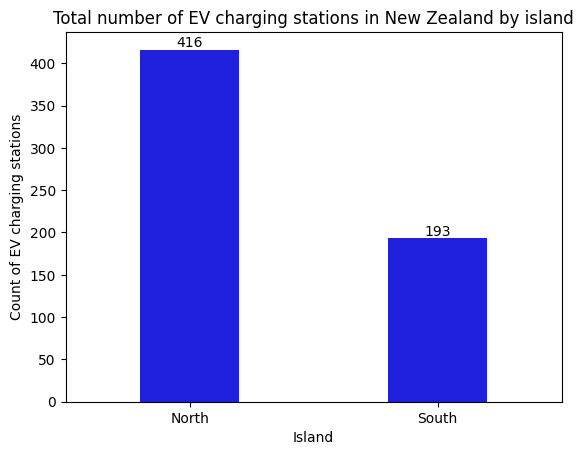

In [55]:
ax = seaborn.countplot(data=ev_charging_stations,x="island",width=0.4,color="blue")
ax.bar_label(ax.containers[0],fontsize=10)
plt.xlabel("Island")
plt.ylabel("Count of EV charging stations")
plt.title("Total number of EV charging stations in New Zealand by island")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_in_nz_by_island.png");

#### 💡**Insights:**
- North island has more EV charging stations than the South island in New Zealand.

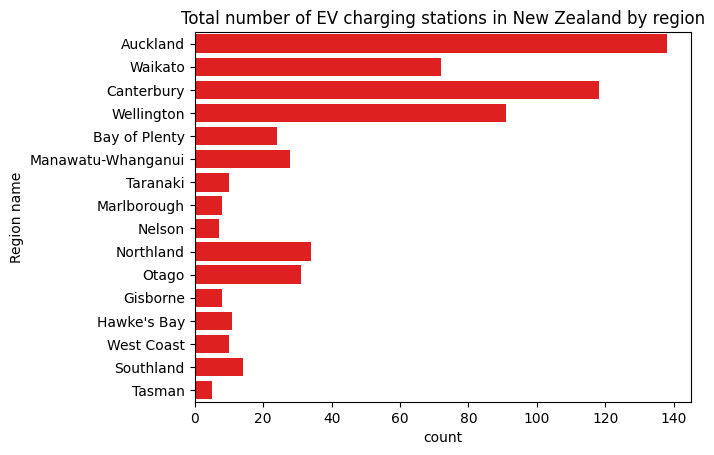

In [56]:
seaborn.countplot(data=ev_charging_stations,y="region",color="red")
plt.ylabel("Region name")
plt.title("Total number of EV charging stations in New Zealand by region")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_in_nz_by_region.png");

#### 💡**Insights:**
- Auckland region has the highest number of EV charging stations in New Zealand which is around 140.
- Canterbury region is the second region to have the highest number of EV charging stations in New Zealand which is around 120.
- Tasman region has the lowest number of EV charging stations in New Zealand.

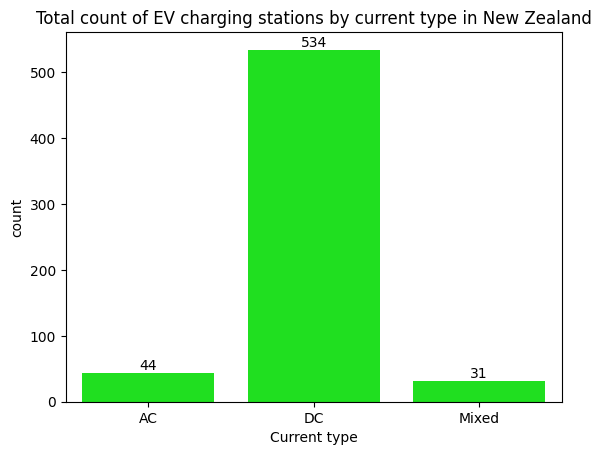

In [57]:
ax=seaborn.countplot(data=ev_charging_stations,x="current_type",color="lime")
ax.bar_label(ax.containers[0])
plt.xlabel("Current type")
plt.title("Total count of EV charging stations by current type in New Zealand")
plt.savefig("/kaggle/working/plots/total_count_of_ev_charging_stations_by_current_type_in_nz.png");

#### 💡**Insights:**
- 534 EV charging stations in New Zealand have Direct Current (DC) EV chargers making it the highest number of current type among connectors.
- The number of EV charging stations using AC current, or a mix of AC and DC chargers is lesss than 45.

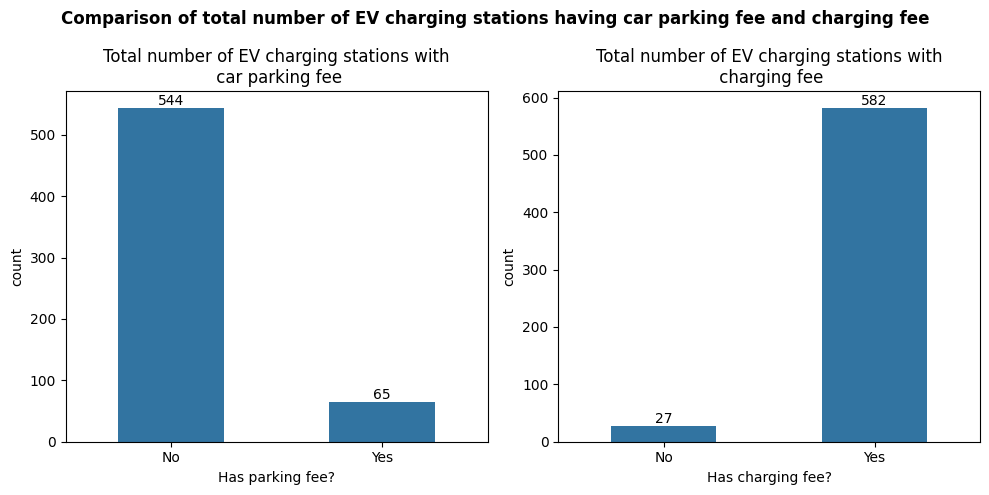

In [58]:
f, ax = plt.subplots(1,2,figsize=(10,5))
seaborn.countplot(data=ev_charging_stations,x="has_carpark_cost",ax=ax[0],width=0.5)
ax[0].bar_label(ax[0].containers[0])
seaborn.countplot(data=ev_charging_stations,x="has_charging_cost",ax=ax[1],width=0.5)
ax[1].bar_label(ax[1].containers[0])
ax[0].set_xlabel("Has parking fee?")
ax[0].set_title("Total number of EV charging stations with\n car parking fee")
ax[0].set_xticks(ax[0].get_xticks())
ax[0].set_xticklabels(["No","Yes"])
ax[1].set_xlabel("Has charging fee?")
ax[1].set_title("Total number of EV charging stations with\n charging fee")
ax[1].set_xticks(ax[1].get_xticks())
ax[1].set_xticklabels(["No","Yes"])
plt.suptitle("Comparison of total number of EV charging stations having car parking fee and charging fee",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_total_number_of_ev_charging_stations_having_car_parking_fee_and_charging_fee.png");

#### 💡**Insights:**
- Most of the EV charging stations in New Zealand have free car parking.
- Only 65 EV charging stations in New Zealand have car parking fee.
- Most of the EV charging stations have paid charging in New Zealand, while only 27 EV stations have free charging.

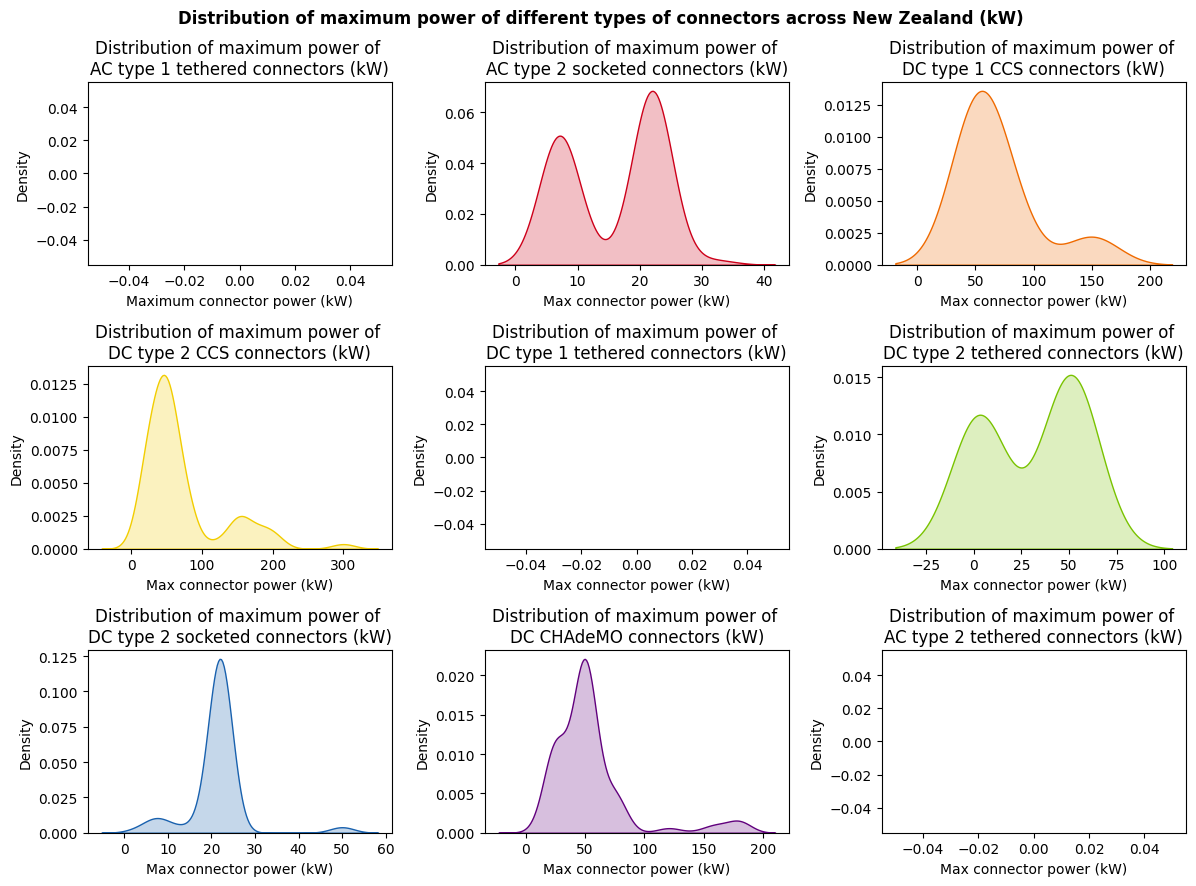

In [59]:
f, ax = plt.subplots(3,3,figsize=(12,9))
seaborn.kdeplot(data=ev_charging_stations,x="max_ac_type_1_tethered_power_kw",fill=True,ax=ax[0,0],warn_singular=False)
seaborn.kdeplot(data=ev_charging_stations,x="max_ac_type_2_socketed_power_kw",fill=True,ax=ax[0,1],warn_singular=False,color="#cd001a")
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_type_1_ccs_power_kw",fill=True,ax=ax[0,2],color="#ef6a00")
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_type_2_ccs_power_kw",fill=True,ax=ax[1,0],color="#f2cd00")
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_type_1_tethered_power_kw",fill=True,ax=ax[1,1],warn_singular=False)
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_type_2_tethered_power_kw",fill=True,ax=ax[1,2],color="#79c300")
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_type_2_socketed_power_kw",fill=True,ax=ax[2,0],color="#1961ae")
seaborn.kdeplot(data=ev_charging_stations,x="max_dc_chademo_power_kw",fill=True,ax=ax[2,1],color="#61007d")
seaborn.kdeplot(data=ev_charging_stations,x="max_ac_type_2_tethered_power_kw",fill=True,ax=ax[2,2],warn_singular=False)
ax[0,0].set_xlabel("Maximum connector power (kW)")
ax[0,0].set_title("Distribution of maximum power of \nAC type 1 tethered connectors (kW)")
ax[0,1].set_xlabel("Max connector power (kW)")
ax[0,1].set_title("Distribution of maximum power of \nAC type 2 socketed connectors (kW)")
ax[0,2].set_xlabel("Max connector power (kW)")
ax[0,2].set_title("Distribution of maximum power of \nDC type 1 CCS connectors (kW)")
ax[1,0].set_xlabel("Max connector power (kW)")
ax[1,0].set_title("Distribution of maximum power of \nDC type 2 CCS connectors (kW)")
ax[1,1].set_xlabel("Max connector power (kW)")
ax[1,1].set_title("Distribution of maximum power of \nDC type 1 tethered connectors (kW)")
ax[1,2].set_xlabel("Max connector power (kW)")
ax[1,2].set_title("Distribution of maximum power of \nDC type 2 tethered connectors (kW)")
ax[2,0].set_xlabel("Max connector power (kW)")
ax[2,0].set_title("Distribution of maximum power of \nDC type 2 socketed connectors (kW)")
ax[2,1].set_xlabel("Max connector power (kW)")
ax[2,1].set_title("Distribution of maximum power of \nDC CHAdeMO connectors (kW)")
ax[2,2].set_xlabel("Max connector power (kW)")
ax[2,2].set_title("Distribution of maximum power of \nAC type 2 tethered connectors (kW)")
plt.suptitle("Distribution of maximum power of different types of connectors across New Zealand (kW)",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/distribution_of_maximum_power_of_different_types_of_connectors_across_nz.png");

#### 💡**Insights:**
- DC Type 2 CCS connectors have the highest maximum power of upto 300 kW which helps in fast charging of electric vehicles in New Zealand.
- Most of the DC Type 2 CCS connectors in the EV charging stations of New Zealand has maxium power of around 50 kW.
- Most of the DC Type 1 CCS connectors in the EV charging stations has maximum power of around 60 kW.
- Most of the DC CHAdeMO connectors and DC Type 2 Tethered connectors have a maximum power of around 60 kW.
- AC Type 2 Socketed connectors in New Zealand has mostly 25 kW as maximum power.

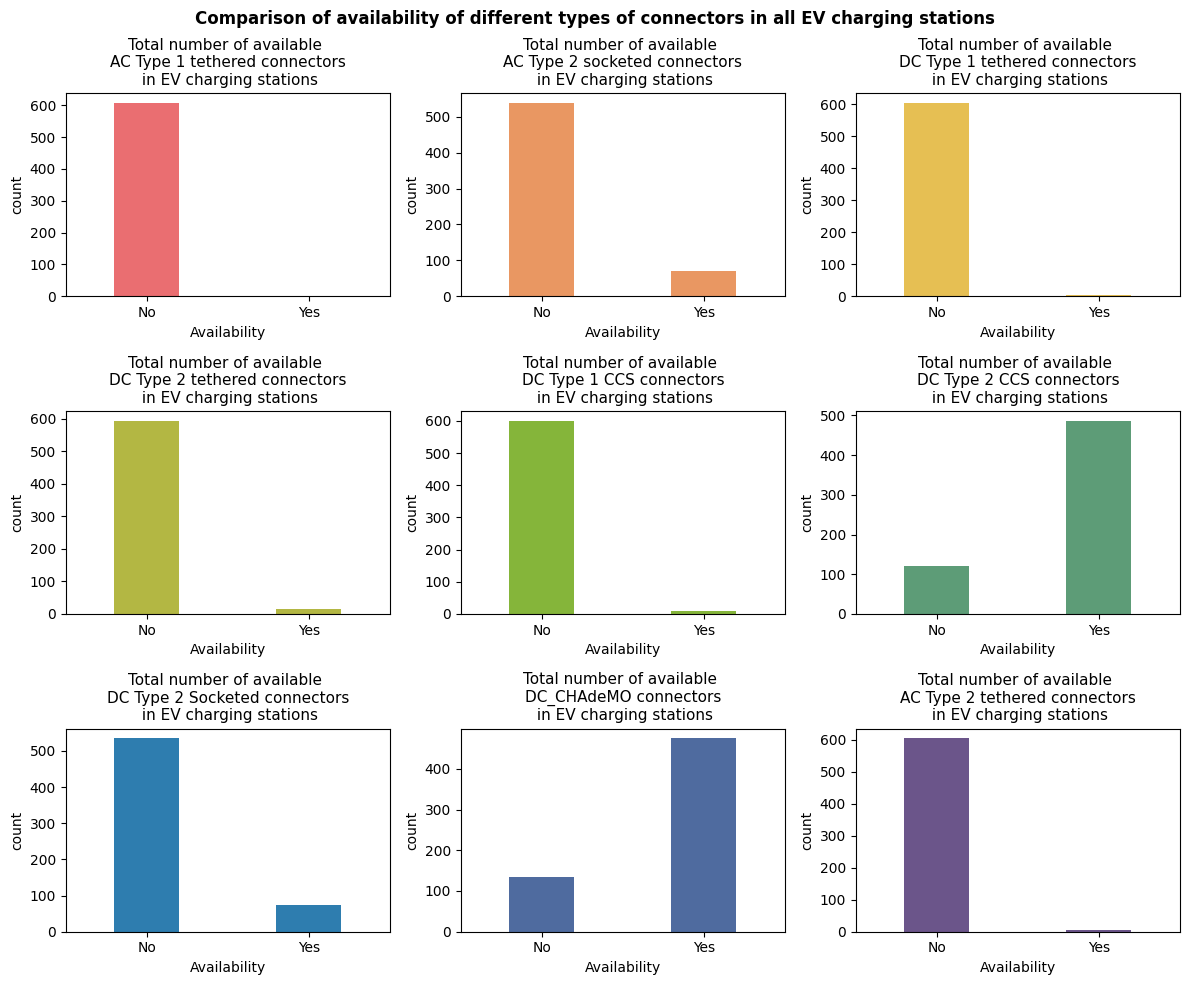

In [60]:
f,ax = plt.subplots(3,3,figsize=(12,10))
connector_types = ["AC Type 1 tethered","AC Type 2 socketed","DC Type 1 tethered","DC Type 2 tethered","DC Type 1 CCS","DC Type 2 CCS","DC Type 2 Socketed","DC_CHAdeMO","AC Type 2 tethered"]
seaborn.countplot(data=ev_charging_stations,x="ac_type_1_tethered_connector",ax=ax[0,0],width=0.4,color="#ff595e")
seaborn.countplot(data=ev_charging_stations,x="ac_type_2_socketed_connector",ax=ax[0,1],width=0.4,color="#ff924c")
seaborn.countplot(data=ev_charging_stations,x="dc_type_1_tethered_connector",ax=ax[0,2],width=0.4,color="#ffca3a")
seaborn.countplot(data=ev_charging_stations,x="dc_type_2_tethered_connector",ax=ax[1,0],width=0.4,color="#c5ca30")
seaborn.countplot(data=ev_charging_stations,x="dc_type_1_ccs_connector",ax=ax[1,1],width=0.4,color="#8ac926")
seaborn.countplot(data=ev_charging_stations,x="dc_type_2_ccs_connector",ax=ax[1,2],width=0.4,color="#52a675")
seaborn.countplot(data=ev_charging_stations,x="dc_type_2_socketed_connector",ax=ax[2,0],width=0.4,color="#1982c4")
seaborn.countplot(data=ev_charging_stations,x="dc_chademo_connector",ax=ax[2,1],width=0.4,color="#4267ac")
seaborn.countplot(data=ev_charging_stations,x="ac_type_2_tethered_connector",ax=ax[2,2],width=0.4,color="#6a4c93")
subplot_pointer = 0
for subplot_row in range(3):
  for subplot_column in range(3):
    ax[subplot_row,subplot_column].set_xticks(ax[subplot_row,subplot_column].get_xticks())
    ax[subplot_row,subplot_column].set_xticklabels(["No","Yes"])
    ax[subplot_row,subplot_column].set_xlabel("Availability")
    ax[subplot_row,subplot_column].set_title(f"Total number of available \n{connector_types[subplot_pointer]} connectors\n in EV charging stations",fontsize=11)
    subplot_pointer += 1
plt.suptitle("Comparison of availability of different types of connectors in all EV charging stations",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_availability_of_different_types_of_connectors_in_all_ev_charging_stations.png");

#### 💡**Insights:**
- Around 450 connectors in DC Type 2 CCS, and DC CHAdeMO model are present in the EV charging stations of New Zealand making them the highest number of connector models in New Zealand.

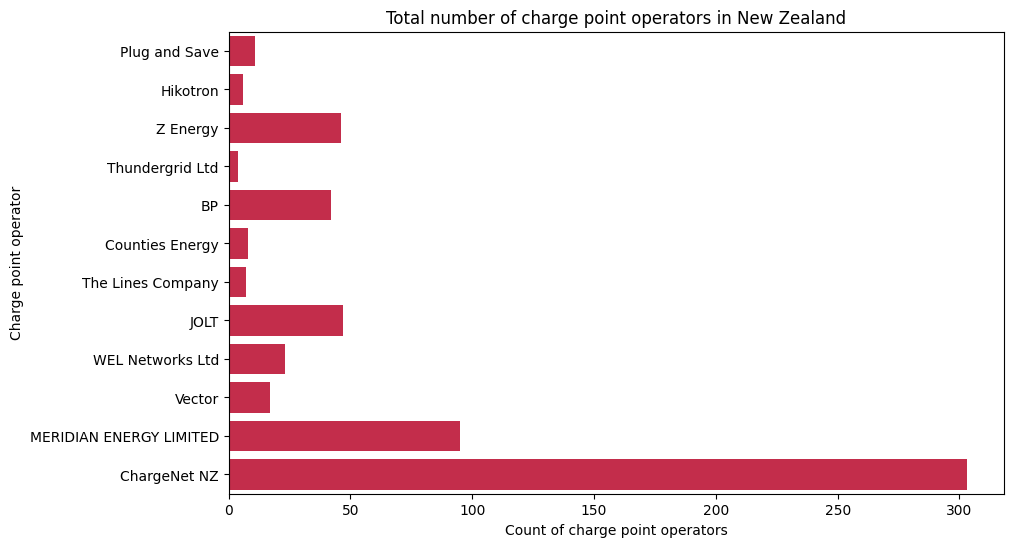

In [61]:
plt.figure(figsize=(10,6))
seaborn.countplot(data=ev_charging_stations,y="charge_point_operator",color="crimson")
plt.xlabel("Count of charge point operators")
plt.ylabel("Charge point operator")
plt.title("Total number of charge point operators in New Zealand")
plt.savefig("/kaggle/working/plots/total_number_of_charge_point_operators_in_new_zealand.png");

#### 💡**Insights:**
- ChargeNet NZ is the mostly operating Charge Point Operator of New Zealand with more than 300 EV charging stations.
- Meridian Energy Limited is the second mostly operating CPO in New Zealand.
- Thundergrid Ltd has the least number of EV charging stations in New Zealand.

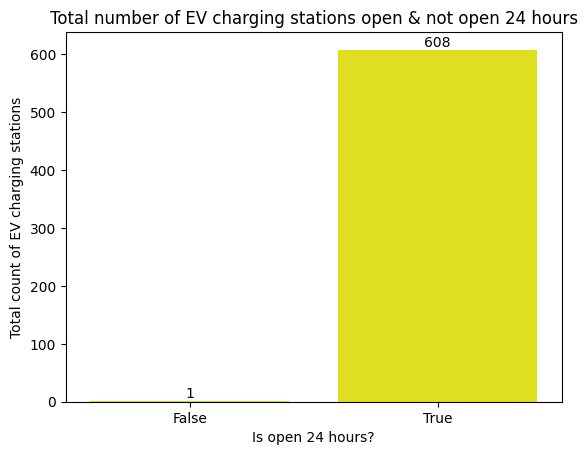

In [62]:
ax = seaborn.countplot(data=ev_charging_stations,x="is_open_24_hours",color="yellow")
ax.bar_label(ax.containers[0])
plt.xlabel("Is open 24 hours?")
plt.ylabel("Total count of EV charging stations")
plt.title("Total number of EV charging stations open & not open 24 hours")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_open_and_not_open_24_hours.png");

#### 💡**Insights:**
- Except 1 charging station, all the other EV charging stations in NZ are open 24 hours.

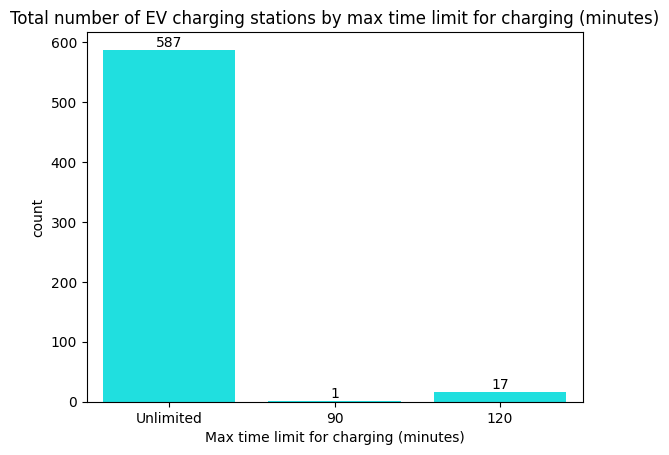

In [63]:
ax = seaborn.countplot(data=ev_charging_stations,x="max_time_limit",color="cyan")
ax.bar_label(ax.containers[0])
plt.xlabel("Max time limit for charging (minutes)")
plt.title("Total number of EV charging stations by max time limit for charging (minutes)")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_by_max_time_limit_for_charging.png");

#### 💡**Insights:**
- Most of the EV charging stations have no time limit for charging electric vehicles.
- Only 1 charging station restricts the time limit for charging electric vehicles to 90 minutes.
- 17 EV charging stations have set a maximum time limit of 120 minutes.

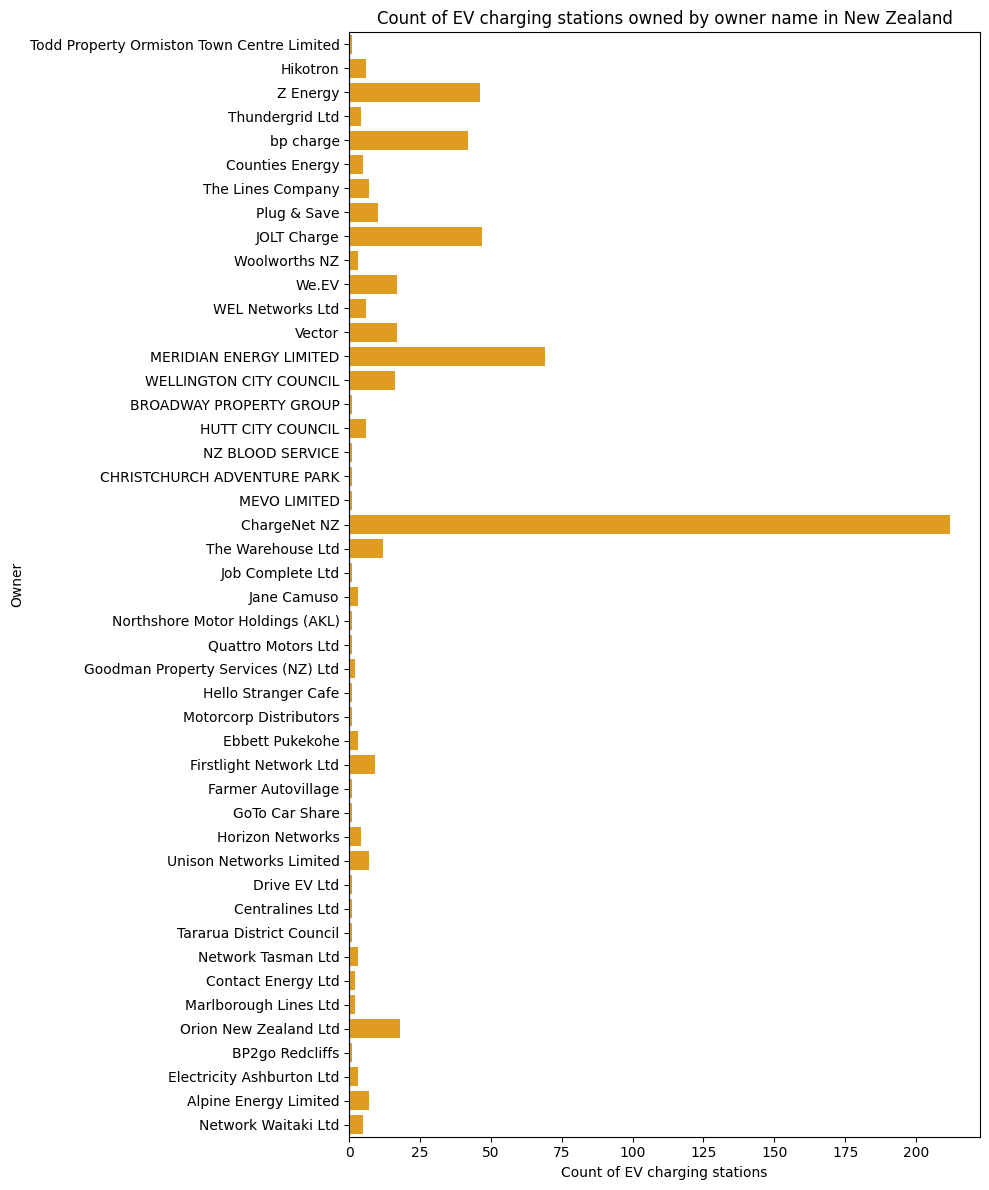

In [64]:
plt.figure(figsize=(10,12))
seaborn.countplot(data=ev_charging_stations,y="owner",color="orange")
plt.xlabel("Count of EV charging stations")
plt.ylabel("Owner")
plt.title("Count of EV charging stations owned by owner name in New Zealand")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/count_of_ev_charging_stations_owned_by_owner_name_in_nz.png");

#### 💡**Insights:**
- Most of the EV charging stations in New Zealand are owned by ChargeNet NZ, which is more than 200.
- All the other owners of EV charging stations in New Zealand are owning less than 60.

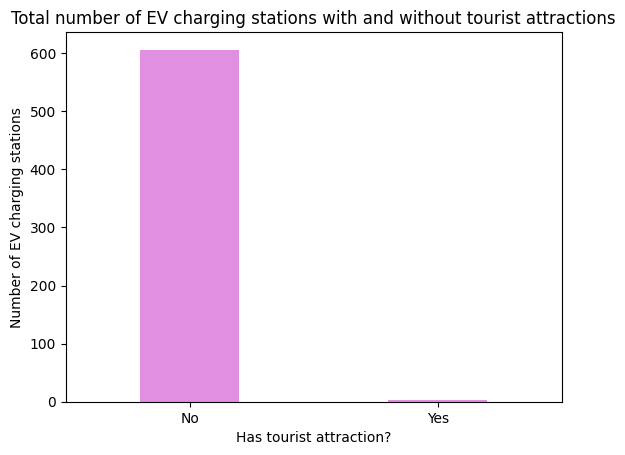

In [65]:
ax = seaborn.countplot(data=ev_charging_stations,x="has_tourist_attraction",color="violet",width=0.4)
ax.set_xticks(ax.get_xticks())
ax.set_xticklabels(["No","Yes"])
plt.xlabel("Has tourist attraction?")
plt.ylabel("Number of EV charging stations")
plt.title("Total number of EV charging stations with and without tourist attractions")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_with_and_without_tourist_attractions.png");

#### 💡**Insights:**
- Most of the EV charging stations in New Zealand are not in a tourist attraction.

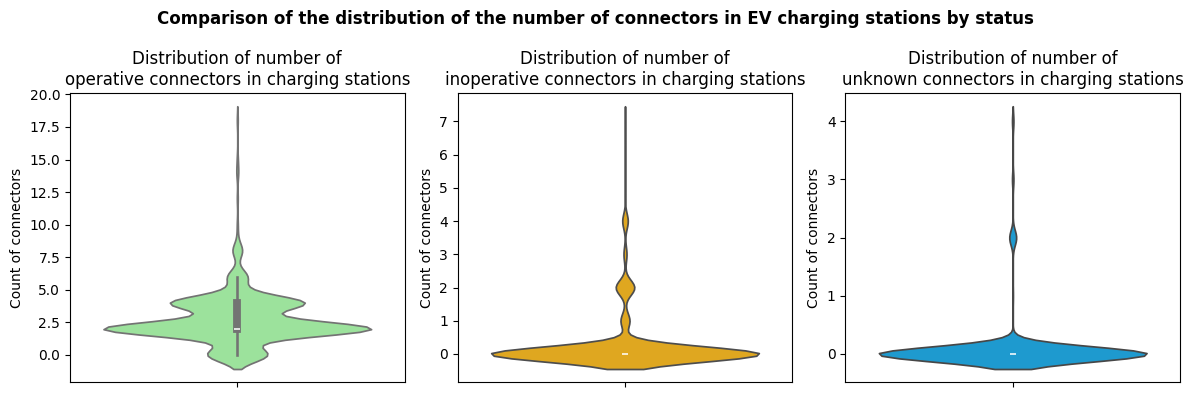

In [66]:
f,ax = plt.subplots(1,3,figsize=(12,4))
seaborn.violinplot(data=ev_charging_stations,y="operative_status_connectors",ax=ax[0],color="lightgreen")
seaborn.violinplot(data=ev_charging_stations,y="inoperative_status_connectors",ax=ax[1],color="#ffb400")
seaborn.violinplot(data=ev_charging_stations,y="unknown_status_connectors",ax=ax[2],color="#00a6ed")
ax[0].set_ylabel("Count of connectors")
ax[1].set_ylabel("Count of connectors")
ax[2].set_ylabel("Count of connectors")
ax[0].set_title("Distribution of number of\noperative connectors in charging stations")
ax[1].set_title("Distribution of number of\ninoperative connectors in charging stations")
ax[2].set_title("Distribution of number of\nunknown connectors in charging stations")
plt.suptitle("Comparison of the distribution of the number of connectors in EV charging stations by status",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_the_distribution_of_the_number_of_connectors_in_ev_charging_stations_by_status.png");

#### 💡**Insights:**
- Most of the EV charging stations in New Zealand has 2 or 4 operative connectors.
- The EV charging stations in New Zealand usually has a maximmum of around 18 connectors.
- Few connectors of around 2 are inoperative in EV charging stations, because most of the EV charging stations have no inoperative connectors.
- The status of a maximum of 4 connectors in a EV charging station are unknown.

## **Bivariate analysis**

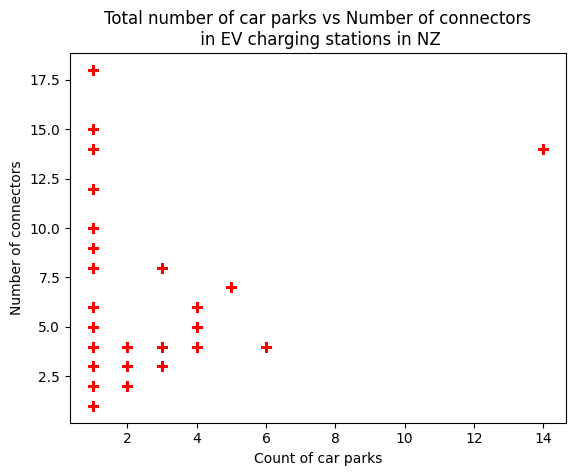

In [67]:
seaborn.scatterplot(data=ev_charging_stations,x="car_park_count",y="number_of_connectors",marker="P",s=80,color="red")
plt.xlabel("Count of car parks")
plt.ylabel("Number of connectors")
plt.title("Total number of car parks vs Number of connectors\n in EV charging stations in NZ")
plt.savefig("/kaggle/working/plots/total_number_of_car_parks_vs_number_of_connectors_in_ev_charging_stations.png");

#### 💡**Insights:**
- The number of connectors in EV charging stations decreases as the number of car parks increases in New Zealand.
- The number of connectors are exceededing above 15 when there is only 1 car parking in the EV charging station.

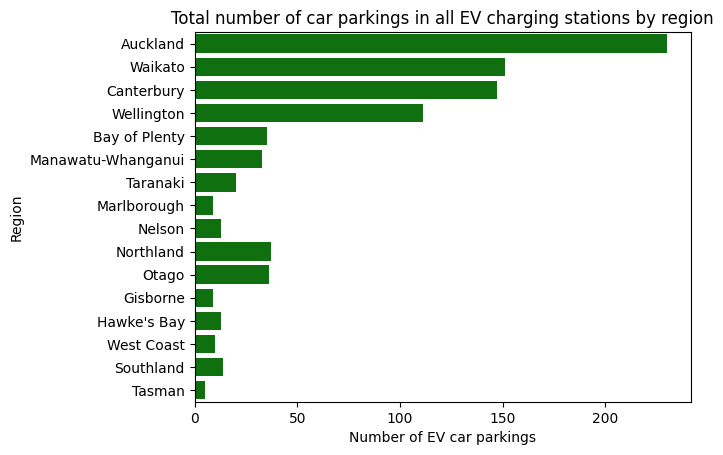

In [68]:
seaborn.barplot(data=ev_charging_stations,y="region",x="car_park_count",errorbar=None,estimator="sum",color="green")
plt.ylabel("Region")
plt.xlabel("Number of EV car parkings")
plt.title("Total number of car parkings in all EV charging stations by region")
plt.savefig("/kaggle/working/plots/total_number_of_car_parkings_in_all_ev_charging_stations_by_region.png");

#### 💡**Insights:**
- Auckland region has the highest number of car parkings of more than 200 in the EV charging stations.
- Waikato region and Canterbury region have the second highest number of car parks.

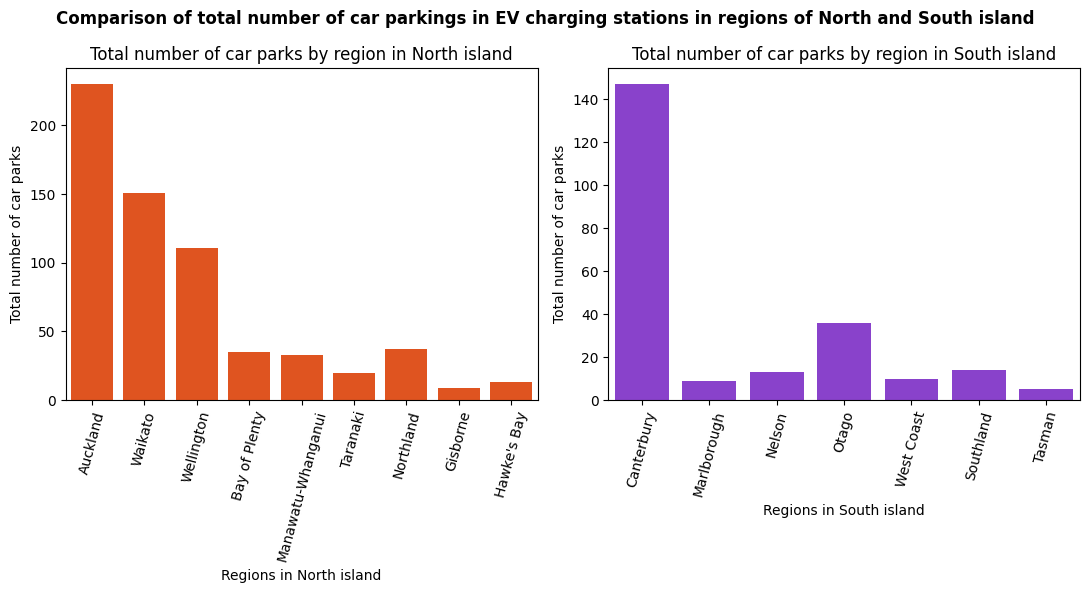

In [69]:
f,ax = plt.subplots(1,2,figsize=(11,6))
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["island"]=="North"],x="region",y="car_park_count",estimator="sum",errorbar=None,ax=ax[0],color="orangered")
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["island"]=="South"],x="region",y="car_park_count",estimator="sum",errorbar=None,ax=ax[1],color="blueviolet")
ax[0].set_title("Total number of car parks by region in North island")
ax[1].set_title("Total number of car parks by region in South island")
ax[0].set_xlabel("Regions in North island")
ax[1].set_xlabel("Regions in South island")
for _ in range(2):
  ax[_].tick_params(axis="x",rotation=75)
  ax[_].set_ylabel("Total number of car parks")
plt.suptitle("Comparison of total number of car parkings in EV charging stations in regions of North and South island",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_total_number_of_car_parkings_in_ev_charging_stations_in_regions_of_north_and_south_island.png");

#### 💡**Insights:**
- The number of car parks in the EV charging stations are more in the North island than in the South island.

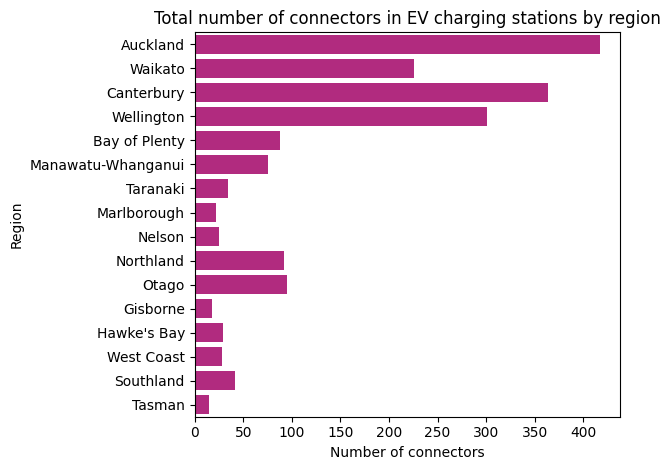

In [70]:
seaborn.barplot(data=ev_charging_stations,y="region",x="number_of_connectors",errorbar=None,estimator="sum",color="mediumvioletred")
plt.ylabel("Region")
plt.xlabel("Number of connectors")
plt.title("Total number of connectors in EV charging stations by region")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/total_number_of_connectors_in_ev_charging_stations_by_region.png");

#### 💡**Insights:**
- Auckland region has the highest number of connectors in EV charging stations of New Zealand which is more than 400.
- Canterbury region has the second highest number of connectors in EV charging stations in New Zealand which is around 370.

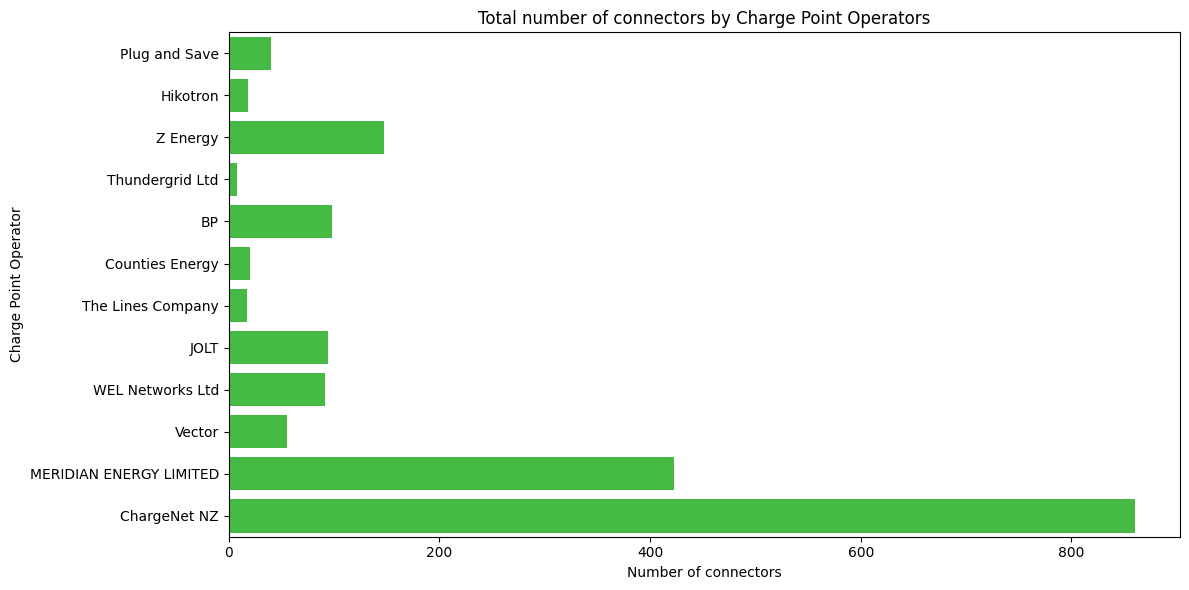

In [71]:
plt.figure(figsize=(12,6))
seaborn.barplot(data=ev_charging_stations,y="charge_point_operator",x="number_of_connectors",estimator="sum",errorbar=None,color="limegreen")
plt.xlabel("Number of connectors")
plt.ylabel("Charge Point Operator")
plt.title("Total number of connectors by Charge Point Operators")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/total_number_of_connectors_by_charge_point_operators.png");

#### 💡**Insights:**
- ChargeNet NZ has the highest number of connectors of above 850.
- Meridian Energy Limited has the second highest number of connectors of around 420.
- Thundergrid Ltd has the lowest number of connectors.

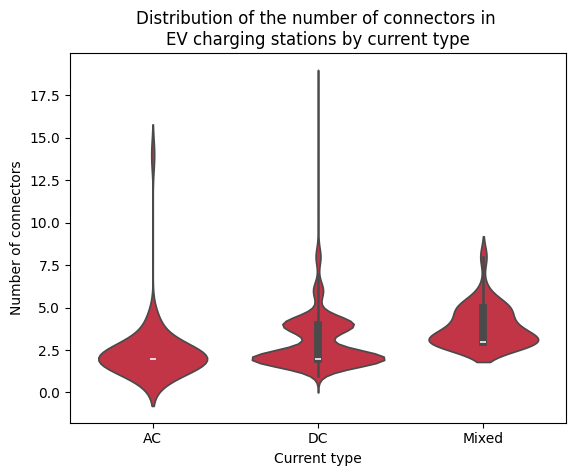

In [72]:
seaborn.violinplot(data=ev_charging_stations,x="current_type",y="number_of_connectors",color="#d91e36")
plt.xlabel("Current type")
plt.ylabel("Number of connectors")
plt.title("Distribution of the number of connectors in \nEV charging stations by current type")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_by_current_type.png");

#### 💡**Insights:**
- Most of the number of AC and DC connectors present in the EV charging stations is 2.
- Most of the number of mixed type connectors in EV charging stations is 3.
- The number of DC connectors in EV charging stations are between 2 to 18, while the number of AC connectors in EV charging stations is less.

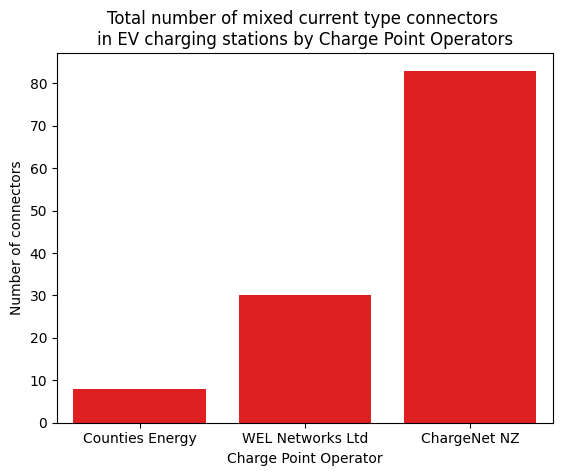

In [73]:
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["current_type"]=="Mixed"],x="charge_point_operator",y="number_of_connectors",estimator="sum",errorbar=None,color="red")
plt.xlabel("Charge Point Operator")
plt.ylabel("Number of connectors")
plt.title("Total number of mixed current type connectors \nin EV charging stations by Charge Point Operators")
plt.savefig("/kaggle/working/plots/total_number_of_mixed_current_type_connectors_in_ev_charging_stations_by_charge_point_operators.png");

#### 💡**Insights:**
- ChargeNet NZ is the Charge Point Operator having highest number of mixed current type connectors.
- ChargeNet NZ has around 80 mixed type connectors in EV charging stations of New Zealand.
- The other key-players having mixed current type of connectors in EV charging stations are WEL Networks Ltd, and Counties Energy.
- WEL Networks Ltd has around 30 mixed current type connectors in EV charging stations which is less than half the quantity of connectors installed by ChargeNet NZ.

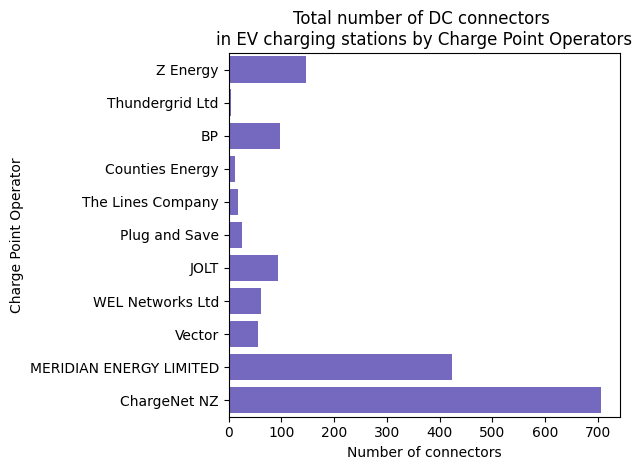

In [74]:
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["current_type"]=="DC"],y="charge_point_operator",x="number_of_connectors",estimator="sum",errorbar=None,color="slateblue")
plt.ylabel("Charge Point Operator")
plt.xlabel("Number of connectors")
plt.title("Total number of DC connectors \nin EV charging stations by Charge Point Operators")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/total_number_of_dc_connectors_in_ev_charging_stations_by_charge_point_operators.png");

#### 💡**Insights:**
- ChargeNet NZ has the highest number of DC connectors in the EV charging stations of New Zealand which is more than 700 connectors.
- Meridian Energy Limited is the second largest Charge Point Operator having around 420 connectors in the EV charging stations.
- Other Charge Point Operators have less than 100 DC connectors in the EV charging stations of New Zealand.

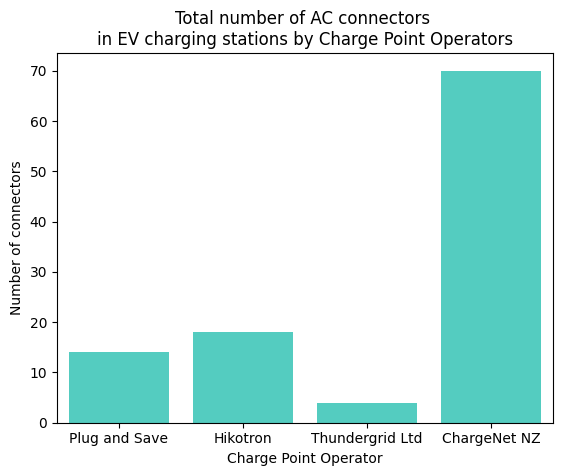

In [75]:
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["current_type"]=="AC"],x="charge_point_operator",y="number_of_connectors",estimator="sum",errorbar=None,color="turquoise")
plt.xlabel("Charge Point Operator")
plt.ylabel("Number of connectors")
plt.title("Total number of AC connectors \nin EV charging stations by Charge Point Operators")
plt.savefig("/kaggle/working/plots/total_number_of_ac_connectors_in_ev_charging_stations_by_charge_point_operators.png");

#### 💡**Insights:**
- ChargeNet NZ is the CPO having highest number of AC connectors in the EV charging stations of New Zealand, which is around 70.
- Hikotron has the second highest number of AC connectors in the EV charging stations of New Zealand.
- Plug and Save is the third largest CPO having around 14 connectors in the EV charging stations.

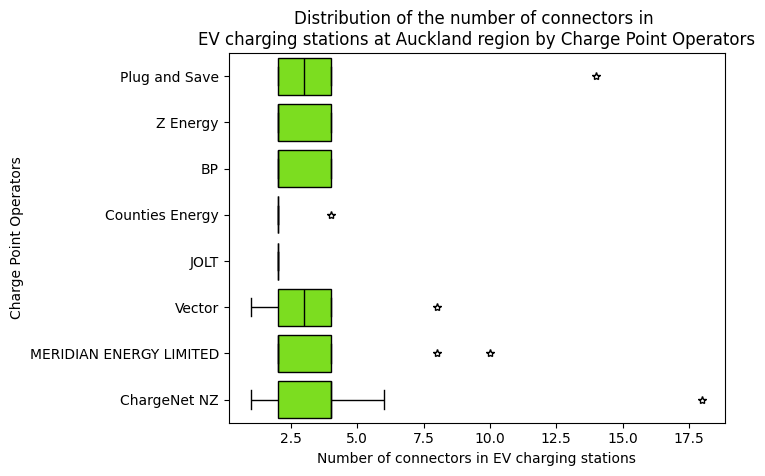

In [76]:
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Auckland"],y="charge_point_operator",x="number_of_connectors",color="lawngreen",linecolor="k",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors in \nEV charging stations at Auckland region by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_auckland_region_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the EV charging stations in Auckland region have 2 to 4 connectors.
- Few of the EV charging stations in Auckland region has highest number of 18 connectors by ChargeNet NZ.
- Plug and Save have few EV charging stations in Auckland region that have around 14 connectors.

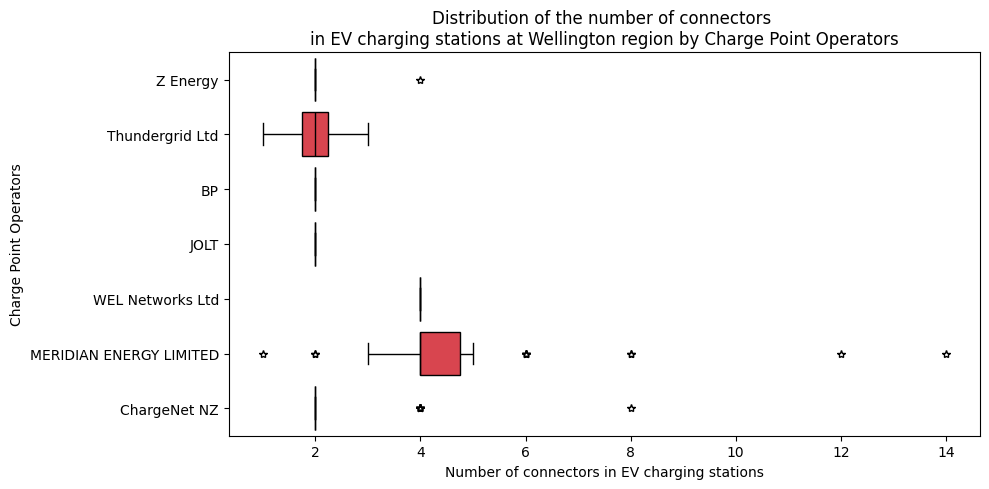

In [77]:
plt.figure(figsize=(10,5))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Wellington"],y="charge_point_operator",x="number_of_connectors",color="#f02d3a",linecolor="k",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Wellington region by Charge Point Operators")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_wellington_region_by_charge_point_operators.png");

#### 💡**Insights:**
- The number of connectors by Meridian Energy Limited in the Wellington region are mostly between 4 to 5.
- Few of the EV charging stations managed by Meridian Energy Limited have highest number of connectors between 12 to 14 in the Wellington region.
- The EV charging stations by ChargeNet NZ in the Wellington region has mostly 2 connectors, while few charging stations have 8 connectors.
- The EV charging stations managed by BP and JOLT have only 2 connectors in the Wellington region.

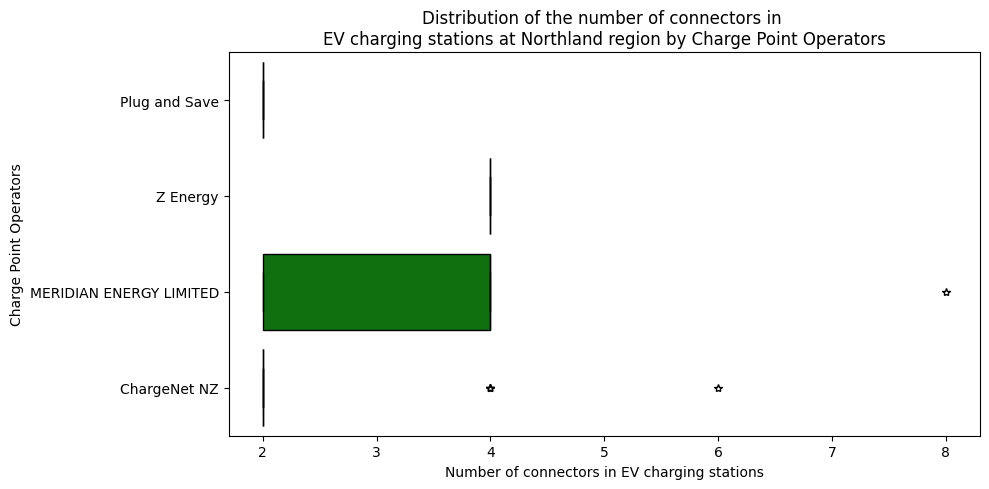

In [78]:
plt.figure(figsize=(10,5))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Northland"],y="charge_point_operator",x="number_of_connectors",color="green",linecolor="k",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors in \nEV charging stations at Northland region by Charge Point Operators")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_northland_region_by_charge_point_operators.png");

#### 💡**Insights:**
- Meridian Energy Limited is the CPO having the highest number of connectors in the Northland region of New Zealand which is around 8 in some EV charging stations.
- The EV charging stations having connectors by Z Energy have mostly 4 connectors.

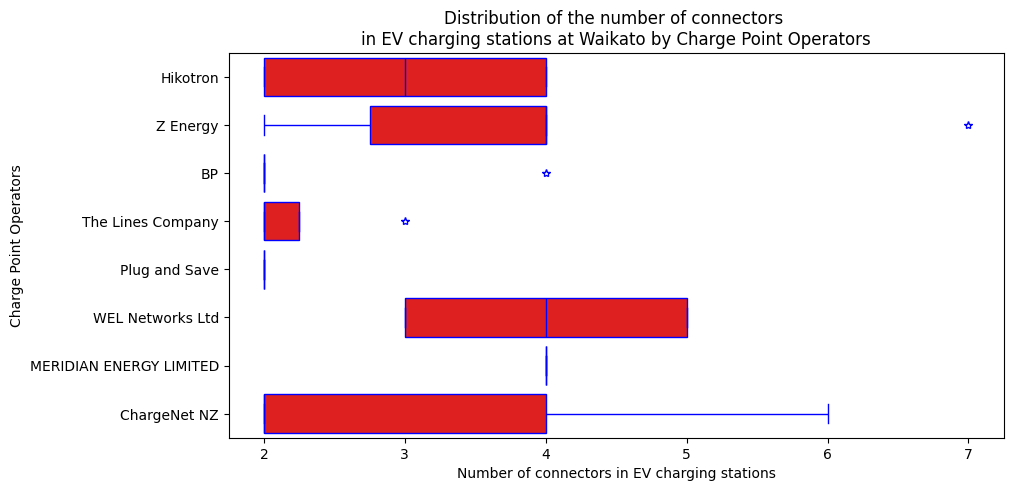

In [79]:
plt.figure(figsize=(10,5))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Waikato"],y="charge_point_operator",x="number_of_connectors",color="red",linecolor="blue",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Waikato by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_waikato_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the EV charging stations in Waikato has 2 to 4 connectors by ChargeNet NZ, and Hikotron, while WEL Networks Ltd has mostly 3 to 5 connectors in EV charging stations.
- Few EV charging stations in Waikato which have Z Energy as CPO has 7 connectors.

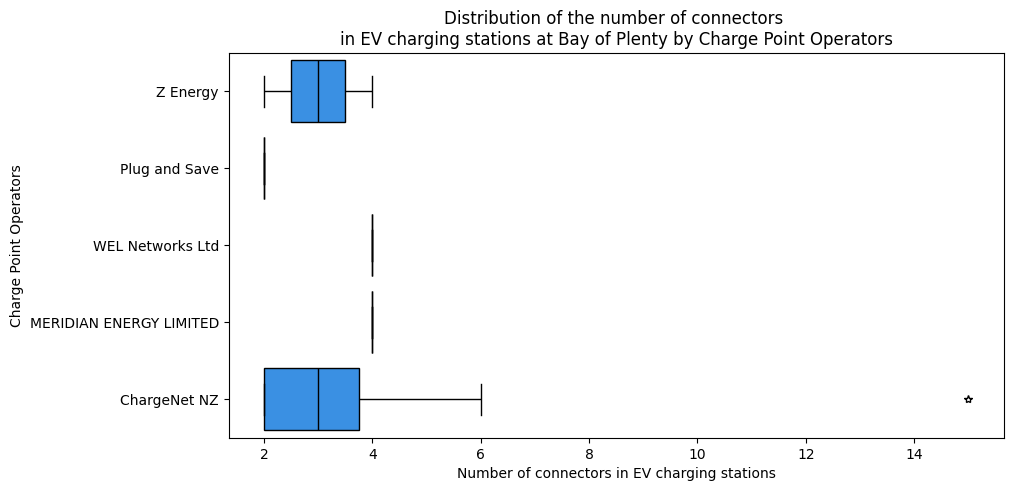

In [80]:
plt.figure(figsize=(10,5))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Bay of Plenty"],y="charge_point_operator",x="number_of_connectors",color="dodgerblue",linecolor="k",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Bay of Plenty by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_bay_of_plenty_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the EV charging stations having ChargeNet NZ as the CPO at Bay of Plenty has 2 to 4 connectors, while few stations have the highest number of 15 connectors.

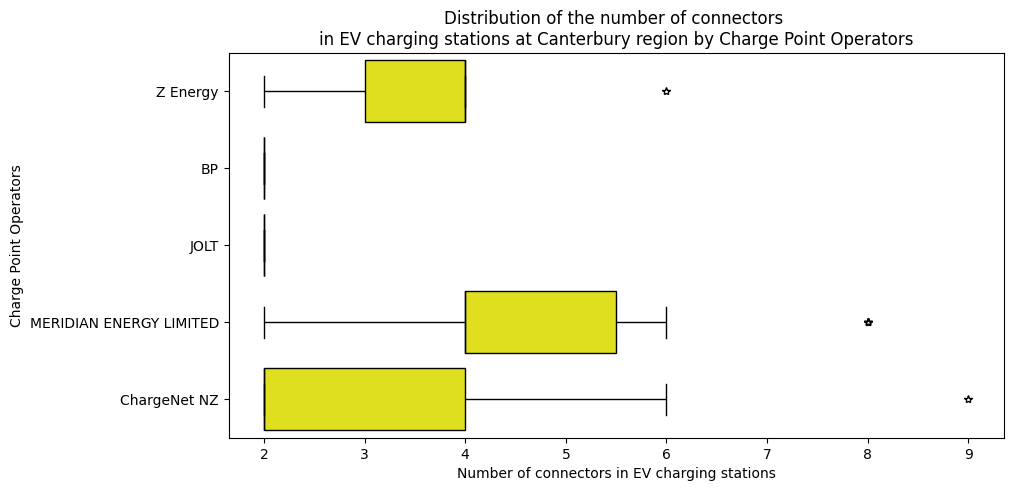

In [81]:
plt.figure(figsize=(10,5))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Canterbury"],y="charge_point_operator",x="number_of_connectors",color="yellow",linecolor="k",flierprops={"marker":"*"})
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Canterbury region by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_canterbury_region_by_charge_point_operators.png");

#### 💡**Insights:**
- Meridian Energy Limited is the CPO having mostly 4 to 6 connectors in the EV charging stations of Canterbury region.
- Few of the EV charging stations in Canterbury have maximum number of connectors of around 9 by ChargeNet NZ as the CPO.
- The EV charging stations with BP and JOLT as the CPO have only 2 connectors.

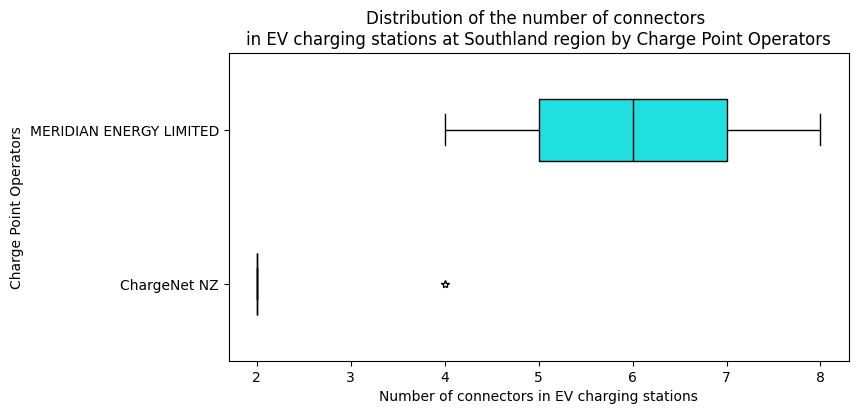

In [82]:
plt.figure(figsize=(8,4))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Southland"],y="charge_point_operator",x="number_of_connectors",color="cyan",linecolor="k",flierprops={"marker":"*"},width=0.4)
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Southland region by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_southland_region_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the EV charging stations in the Southland region by Meridian Energy Limited as CPO has 5 to 7 connectors.
- ChargeNet NZ has less than 4 connectors in the EV charging stations of Southland region.

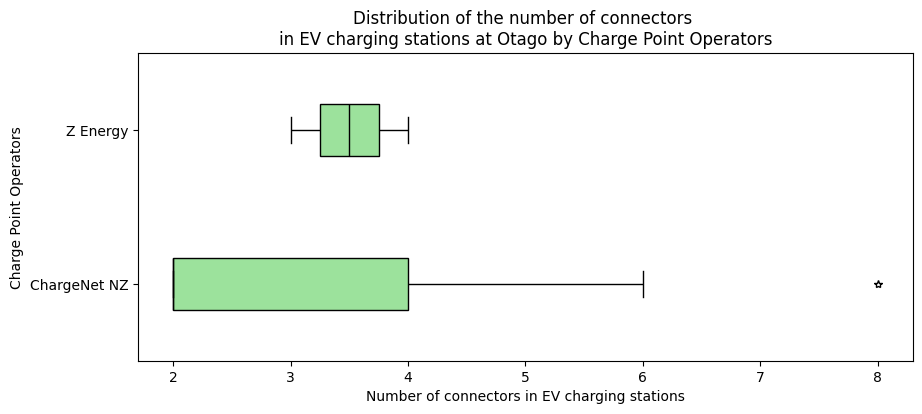

In [83]:
plt.figure(figsize=(10,4))
seaborn.boxplot(data=ev_charging_stations[ev_charging_stations["region"]=="Otago"],y="charge_point_operator",x="number_of_connectors",color="lightgreen",linecolor="k",flierprops={"marker":"*"},width=0.34)
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Charge Point Operators")
plt.title("Distribution of the number of connectors \nin EV charging stations at Otago by Charge Point Operators")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_at_otago_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the EV charging stations in Otago with ChargeNet NZ as the CPO have 2 to 4 connectors, while few stations have 8 connectors.
- Only ChargeNet NZ and Z Energy are the Charge Point Operators in the Otago region of New Zealand.

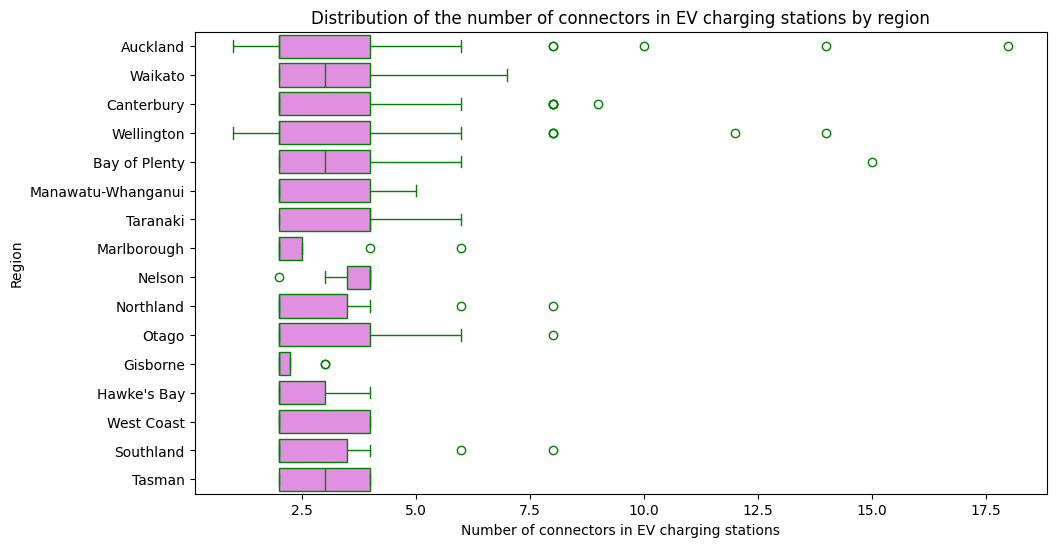

In [84]:
plt.figure(figsize=(11,6))
seaborn.boxplot(data=ev_charging_stations,y="region",x="number_of_connectors",color="violet",linecolor="green")
plt.xlabel("Number of connectors in EV charging stations")
plt.ylabel("Region")
plt.title("Distribution of the number of connectors in EV charging stations by region")
plt.savefig("/kaggle/working/plots/distribution_of_the_number_of_connectors_in_ev_charging_stations_by_region.png");

#### 💡**Insights:**
- Few of the EV charging stations in Auckland region has the highest number of connectors of around 17.
- Most of the EV charging stations in Gisborne region have only 2 connectors.
- Other regions in New Zealand mostly have 2 to 4 connectors in their EV charging stations.

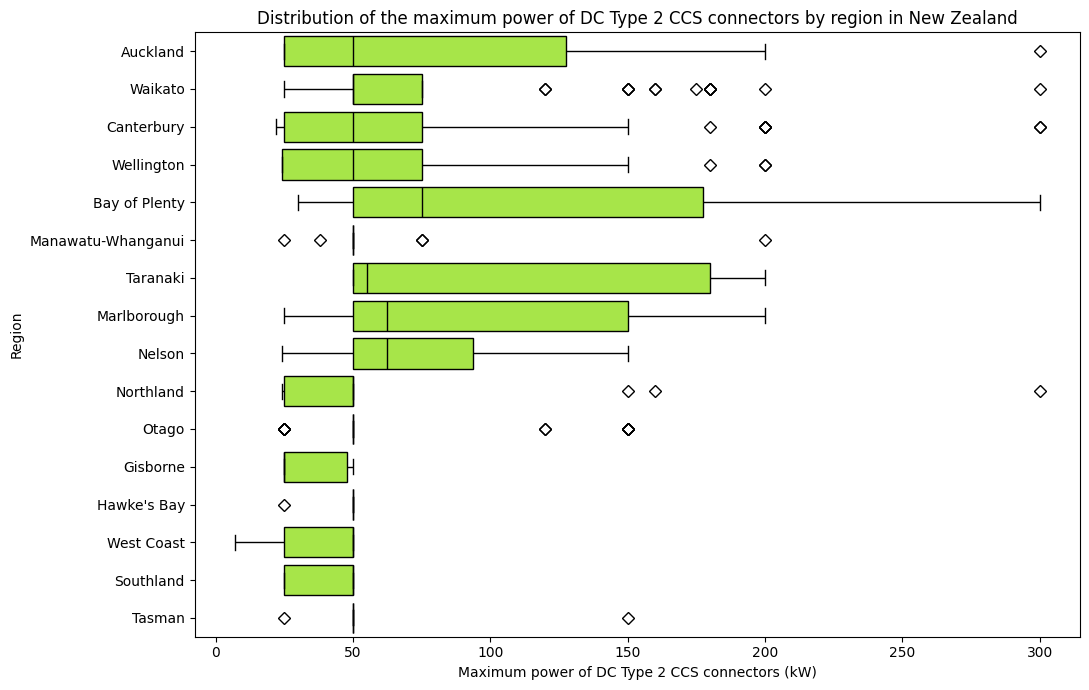

In [85]:
plt.figure(figsize=(11,7))
seaborn.boxplot(data=ev_charging_stations,y="region",x="max_dc_type_2_ccs_power_kw",color="greenyellow",flierprops={"marker":"D"},linecolor="k")
plt.xlabel("Maximum power of DC Type 2 CCS connectors (kW)")
plt.ylabel("Region")
plt.title("Distribution of the maximum power of DC Type 2 CCS connectors by region in New Zealand")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/distribution_of_the_maximum_power_of_dc_type_2_ccs_connectors_by_region_in_nz.png");

#### 💡**Insights:**
- Few of the EV charging stations in Auckland, Canterbury, Wellington, and Northland region have the highest maximum power for DC Type 2 CCS connectors which is around 300 kW.
- Most of the EV charging stations having DC Type 2 CCS connectors in Taranaki and Bay of Plenty have 50 kW to 180 kW as the maximum power.
- All the EV charging stations in Gisborne, Hawke's Bay, West Coast, Southland, and Tasman having DC Type 2 CCS connectors have less than 50 kW as the maximum power.

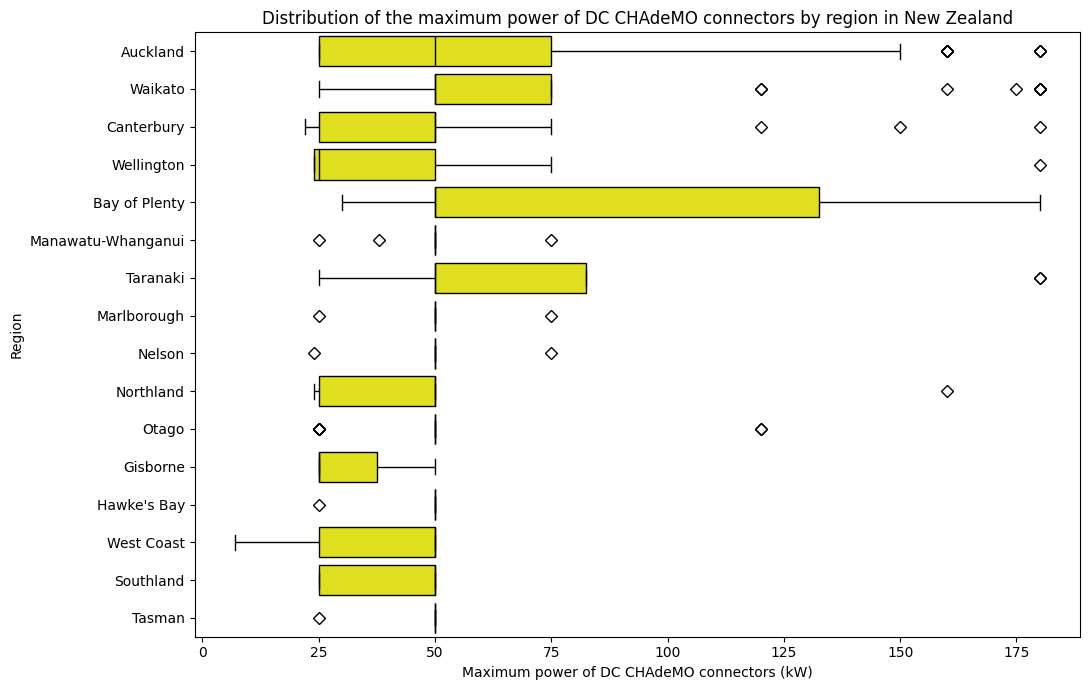

In [86]:
plt.figure(figsize=(11,7))
seaborn.boxplot(data=ev_charging_stations,y="region",x="max_dc_chademo_power_kw",color="yellow",flierprops={"marker":"D"},linecolor="k")
plt.xlabel("Maximum power of DC CHAdeMO connectors (kW)")
plt.ylabel("Region")
plt.title("Distribution of the maximum power of DC CHAdeMO connectors by region in New Zealand")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/distribution_of_the_maximum_power_of_dc_chademo_connectors_by_region_in_nz.png");

#### 💡**Insights:**
- Few of the EV charging stations at Auckland, Waikato, Canterbury, Wellington, Bay of Plenty, and Taranaki have DC CHAdeMO connectors with maximum power of around 175 kW.
- Around 50% of the EV charging stations at Bay of Plenty region with DC CHAdeMO connectors have a maximum power between 50 to 125 kW.
- Around 50% of the EV charging stations at Auckland region with DC CHAdeMO connectors have a maximum power between 25 to 75 kW.

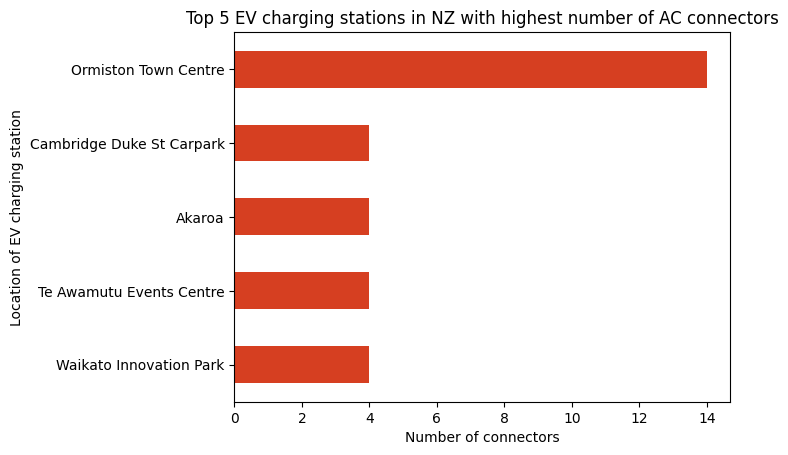

In [87]:
top_5_charging_stations_more_ac_connectors = ev_charging_stations[ev_charging_stations["current_type"]=="AC"].groupby("location_name")["number_of_connectors"].sum().sort_values(ascending=False).head(5)
seaborn.barplot(y=top_5_charging_stations_more_ac_connectors.index,x=top_5_charging_stations_more_ac_connectors.values,color="#f42b03",width=0.5)
plt.xlabel("Number of connectors")
plt.ylabel("Location of EV charging station")
plt.title("Top 5 EV charging stations in NZ with highest number of AC connectors")
plt.savefig("/kaggle/working/plots/top_5_ev_charging_stations_in_nz_with_highest_number_of_ac_connectors.png");

#### 💡**Insights:**
- Most of the AC connectors of around 14 are in the EV charging station at Ormiston Town Centre.
- The EV charging stations located at Cambridge Duke St Carpark, Akaroa, Te Awamutu Events Centre, and Waikato Innovation Park have 4 AC connectors in New Zealand.

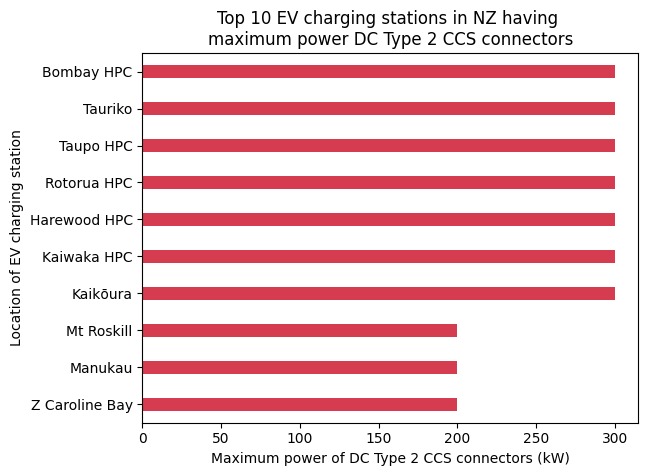

In [88]:
top_10_charging_stations_with_max_dc_type_2_ccs_connectors = ev_charging_stations.groupby("location_name")["max_dc_type_2_ccs_power_kw"].max().sort_values(ascending=False).head(10)
seaborn.barplot(y=top_10_charging_stations_with_max_dc_type_2_ccs_connectors.index,x=top_10_charging_stations_with_max_dc_type_2_ccs_connectors.values,color="#ef233c",width=0.35)
plt.xlabel("Maximum power of DC Type 2 CCS connectors (kW)")
plt.ylabel("Location of EV charging station")
plt.title("Top 10 EV charging stations in NZ having \nmaximum power DC Type 2 CCS connectors")
plt.savefig("/kaggle/working/plots/top_10_ev_charging_stations_in_nz_having_maximum_power_dc_type_2_ccs_connectors.png");

#### 💡**Insights:**
- The EV charging stations located at Bombay HPC, Tauriko, Taupo HPC, Rotorua HPC, Kaiwaka HPC, and Kaikoura have the DC Type 2 CCS connectors with maximum power of 300 kW which helps in fast charging of electric vehicles.
- The EV charging stations at Mt Roskill, Manukau, and Z Caroline Bay have the DC Type 2 CCS connectors with maximum power of 200 kW.

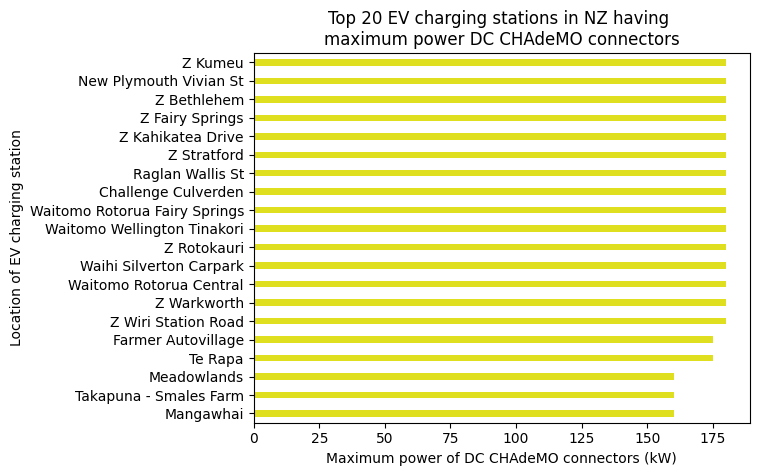

In [89]:
top_20_charging_stations_with_max_dc_chademo_connectors = ev_charging_stations.groupby("location_name")["max_dc_chademo_power_kw"].max().sort_values(ascending=False).head(20)
seaborn.barplot(y=top_20_charging_stations_with_max_dc_chademo_connectors.index,x=top_20_charging_stations_with_max_dc_chademo_connectors.values,color="yellow",width=0.35)
plt.xlabel("Maximum power of DC CHAdeMO connectors (kW)")
plt.ylabel("Location of EV charging station")
plt.title("Top 20 EV charging stations in NZ having \nmaximum power DC CHAdeMO connectors")
plt.savefig("/kaggle/working/plots/top_20_ev_charging_stations_in_nz_having_maximum_power_dc_chademo_connectors.png");

#### 💡**Insights:**
- The EV charging stations at Z Fairy Springs, Z Kahikatea Drive, Z Stratford, Ragian Wallis St, Challenge Culvrden, Waitomo Rotorua Fairy springs, Z Rotokauri, Z Warkworth, Waihi Silverton Carpark, Z Wiri Station Road, Te Rapa, Farmer Autovillage have DC CHAdeMO connectors having maximum power of 175 kW in New Zealand.

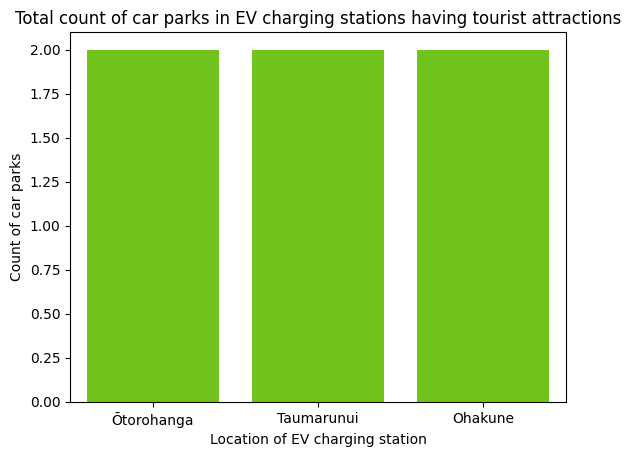

In [90]:
seaborn.barplot(data=ev_charging_stations[ev_charging_stations["has_tourist_attraction"]==True],x="location_name",y="car_park_count",estimator="sum",color="#70e000")
plt.xlabel("Location of EV charging station")
plt.ylabel("Count of car parks")
plt.title("Total count of car parks in EV charging stations having tourist attractions")
plt.savefig("/kaggle/working/plots/total_count_of_car_parks_in_ev_charging_stations_having_tourist_attractions.png");

#### 💡**Insights:**
- The EV charging stations at Otorohanga, Taumarunui, and Ohakune have tourist attractions in it, while the other EV charging stations in New Zealand are not in tourist places.
- The number of connectors in the EV charging stations with tourist attractions is 2.

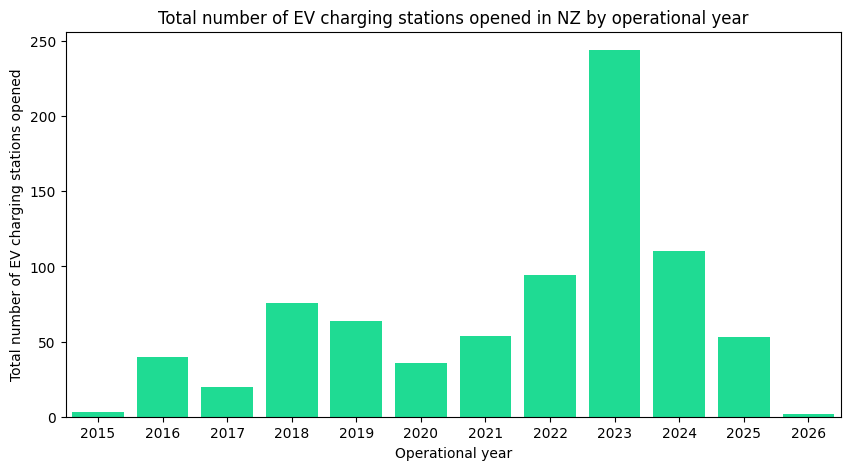

In [91]:
plt.figure(figsize=(10,5))
grouped_by_year_total_sum_of_ev_charging_stations_opened = ev_charging_stations.groupby("operational_year")["car_park_count"].sum()
seaborn.barplot(x=grouped_by_year_total_sum_of_ev_charging_stations_opened.index,y=grouped_by_year_total_sum_of_ev_charging_stations_opened.values,color="mediumspringgreen")
plt.xlabel("Operational year")
plt.ylabel("Total number of EV charging stations opened")
plt.title("Total number of EV charging stations opened in NZ by operational year")
plt.savefig("/kaggle/working/plots/total_number_of_ev_charging_stations_opened_in_nz_by_operational_year.png");

#### 💡**Insights:**
- There is a steady increase in the number of new EV charging stations opened between 2020 and 2023.
- The highest number of EV charging stations are opened in the year 2023 in New Zealand.
- Around 240 new EV charging stations are opened in the year 2023 which is the highest since 2015.
- The year 2024 is the second largest year having highest number of new EV charging stations opened in New Zealand, which is around 110.
- There is a decrease in the number of new EV charging stations opened since 2024.

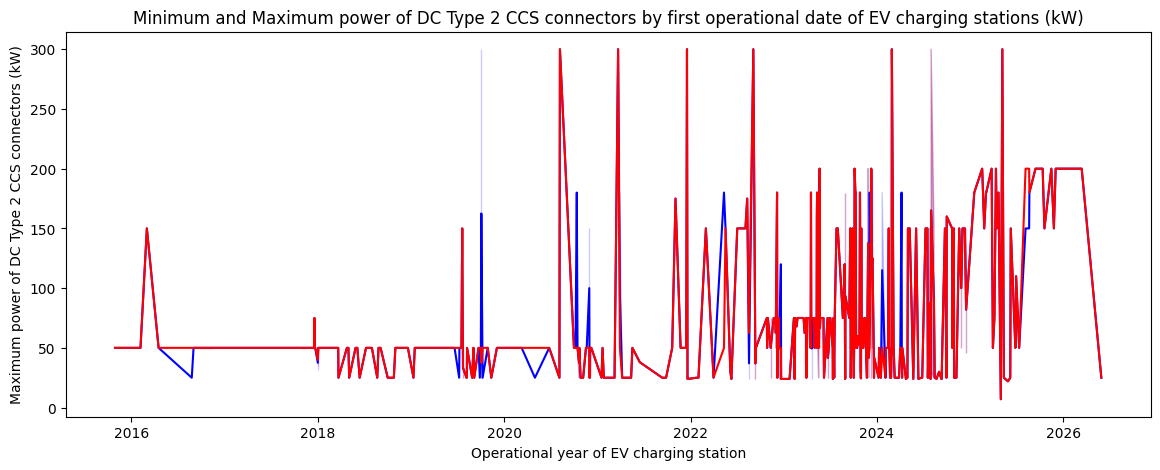

In [92]:
plt.figure(figsize=(14,5))
seaborn.lineplot(data=ev_charging_stations,x="date_first_operational",y="min_dc_type_2_ccs_power_kw",color="blue")
seaborn.lineplot(data=ev_charging_stations,x="date_first_operational",y="max_dc_type_2_ccs_power_kw",color="red")
plt.xlabel("Operational year of EV charging station")
plt.ylabel("Maximum power of DC Type 2 CCS connectors (kW)")
plt.title("Minimum and Maximum power of DC Type 2 CCS connectors by first operational date of EV charging stations (kW)")
plt.savefig("/kaggle/working/plots/minimum_and_maximum_power_of_dc_type_2_ccs_connectors_by_first_operational_date_of_ev_charging_stations.png");

#### 💡**Insights:**
- The maximum power of DC Type 2 CCS connectors in the EV charging stations opened in 2016 is around 50 kW, and the maximum power has peaked to around 300 kW in the EV charging stations opened since the mid of the year 2020.
- The minimum power of DC Type 2 CCS connectors in the EV charging stations opened from the mid of 2019 has increased to around 175 kW.

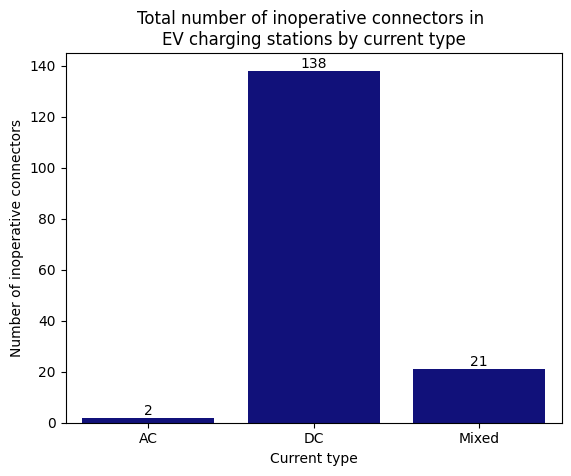

In [93]:
ax = seaborn.barplot(data=ev_charging_stations,x="current_type",y="inoperative_status_connectors",color="darkblue",errorbar=None,estimator="sum")
ax.bar_label(ax.containers[0])
plt.xlabel("Current type")
plt.ylabel("Number of inoperative connectors")
plt.title("Total number of inoperative connectors in \nEV charging stations by current type")
plt.savefig("/kaggle/working/plots/total_number_of_inoperative_connectors_in_ev_charging_stations_by_current_type.png");

#### 💡**Insights:**
- Most of the inoperative connectors in the EV charging stations are mostly DC connectors, which are 138 connectors.
- Only 2 AC connectors are inoperative in the EV charging stations having AC connectors in New Zealand.

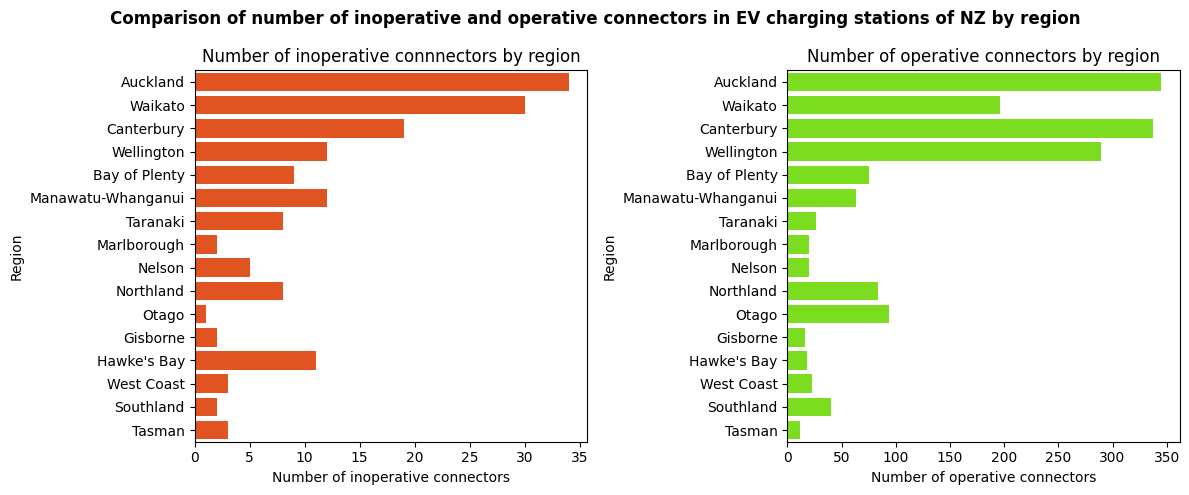

In [94]:
f,ax = plt.subplots(1,2,figsize=(12,5))
seaborn.barplot(data=ev_charging_stations,y="region",x="inoperative_status_connectors",errorbar=None,estimator="sum",ax=ax[0],color="orangered")
seaborn.barplot(data=ev_charging_stations,y="region",x="operative_status_connectors",errorbar=None,estimator="sum",ax=ax[1],color="lawngreen")
ax[0].set_xlabel("Number of inoperative connectors")
ax[0].set_ylabel("Region")
ax[0].set_title("Number of inoperative connnectors by region")
ax[1].set_xlabel("Number of operative connectors")
ax[1].set_ylabel("Region")
ax[1].set_title("Number of operative connectors by region")
plt.suptitle("Comparison of number of inoperative and operative connectors in EV charging stations of NZ by region",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_number_of_inoperative_and_operative_connectors_in_ev_charging_stations_of_nz_by_region.png");

#### 💡**Insights:**
- Auckland has got the highest number of operative and inoperative connectors in the EV charging stations.
- Waikato region ranks fourth place in the number of operative connectors, while it ranks the second place in the number of inoperative connectors.
- The number of operative connectors in Otago is around 100, while the number of inoperative connectors in Otago is less than 3.

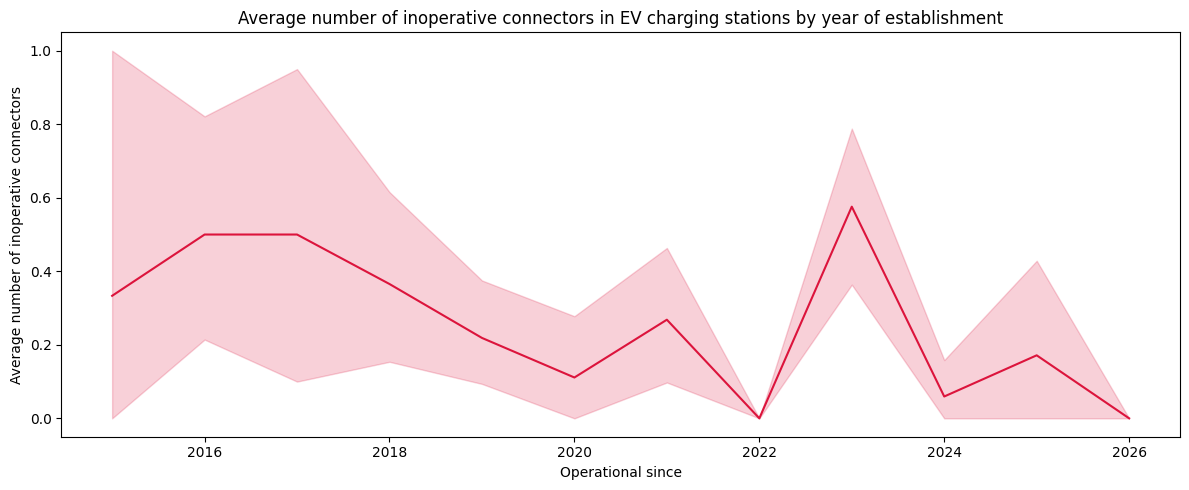

In [95]:
plt.figure(figsize=(12,5))
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="inoperative_status_connectors",color="crimson")
plt.xlabel("Operational since")
plt.ylabel("Average number of inoperative connectors")
plt.title("Average number of inoperative connectors in EV charging stations by year of establishment")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/average_number_of_inoperative_connectors_in_ev_charging_stations_by_year_of_establishment.png");

#### 💡**Insights:**
- The number of inoperative connectors in the EV charging stations are higher in the stations opened in the year 2023.
- The number of inoperative connectors are also higher in the EV charging stations opened between 2016 and 2017.

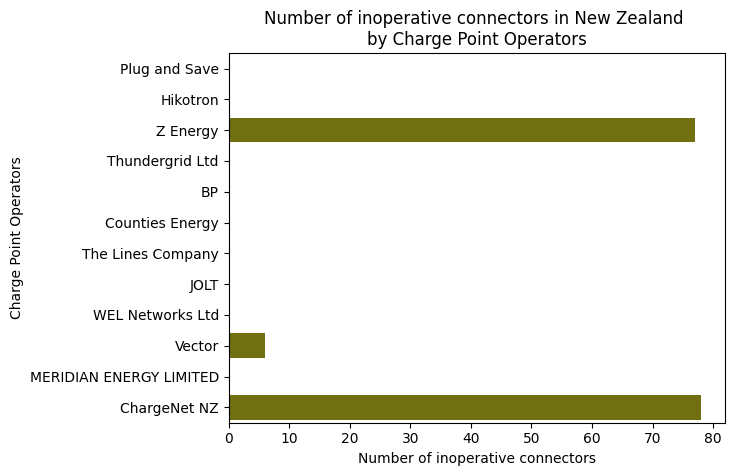

In [96]:
seaborn.barplot(data=ev_charging_stations,y="charge_point_operator",x="inoperative_status_connectors",errorbar=None,estimator="sum",color="olive")
plt.ylabel("Charge Point Operators")
plt.xlabel("Number of inoperative connectors")
plt.title("Number of inoperative connectors in New Zealand \nby Charge Point Operators")
plt.savefig("/kaggle/working/plots/number_of_inoperative_connectors_in_nz_by_charge_point_operators.png");

#### 💡**Insights:**
- The Charge Point Operators of the inoperative connectors in the EV charging stations are mostly ChargeNet NZ, and Z Energy, which are between 75 and 80.
- Vector has the least number of inoperative connectors in the EV charging stations of New Zealand which has around 5 inoperative connectors.

## **Multivariate analysis**

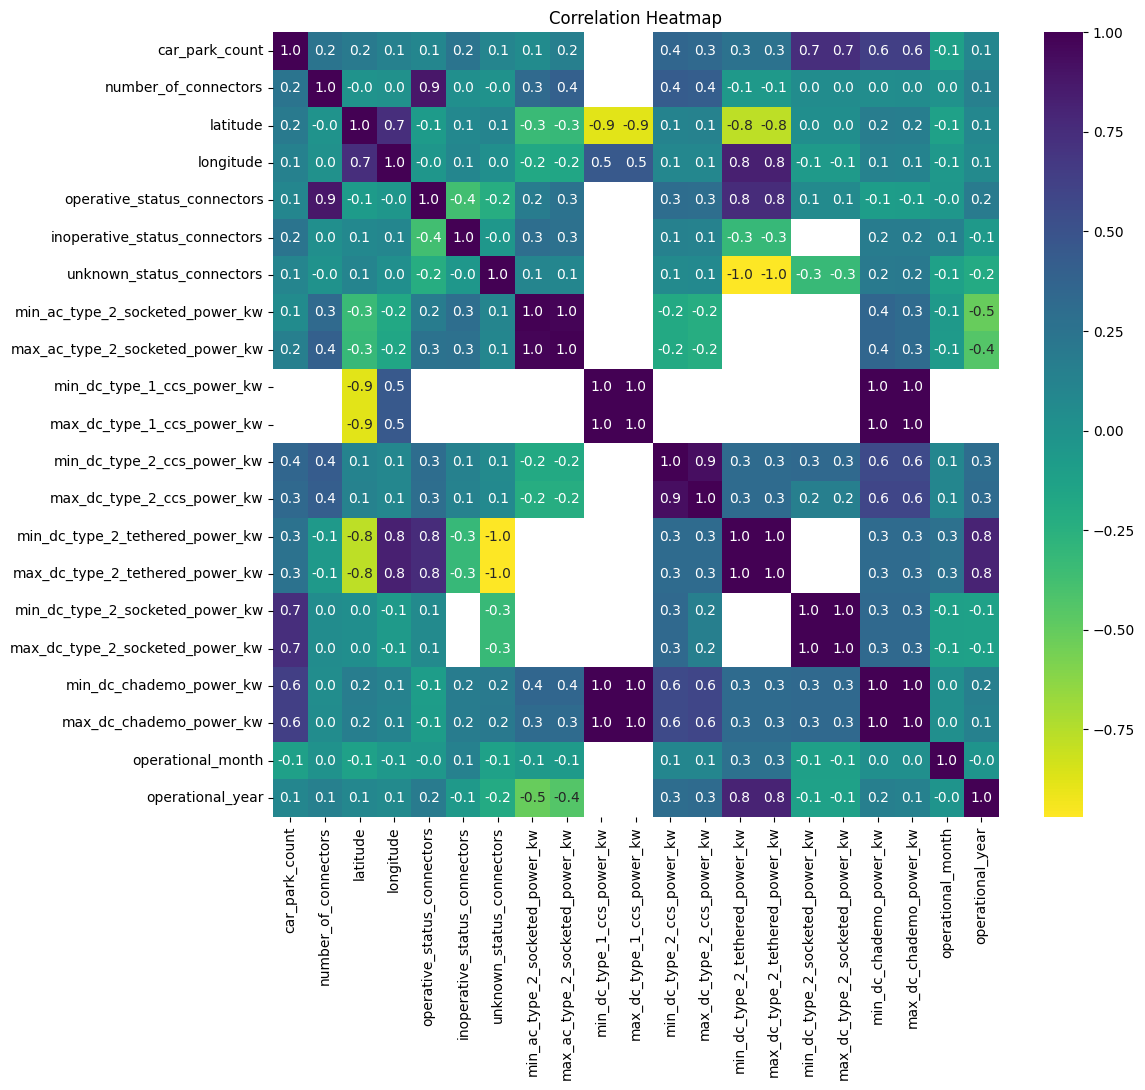

In [97]:
plt.figure(figsize=(12,11))
corr_matrix = ev_charging_stations[["car_park_count","number_of_connectors","latitude","longitude","current_type","operative_status_connectors",
                                    "inoperative_status_connectors","unknown_status_connectors","min_ac_type_2_socketed_power_kw","max_ac_type_2_socketed_power_kw",
                                    "min_dc_type_1_ccs_power_kw","max_dc_type_1_ccs_power_kw","min_dc_type_2_ccs_power_kw","max_dc_type_2_ccs_power_kw",
                                    "min_dc_type_2_tethered_power_kw","max_dc_type_2_tethered_power_kw","min_dc_type_2_socketed_power_kw",
                                    "max_dc_type_2_socketed_power_kw","min_dc_chademo_power_kw","max_dc_chademo_power_kw",
                                    "operational_month","operational_year"]].corr(numeric_only=True)
seaborn.heatmap(corr_matrix,annot=True,fmt=".1f",cmap="viridis_r")
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/correlation_heatmap.png");

#### 💡**Insights:**
- A strong positive correlation exists between the number of connectors and number of operative connectors in EV charging stations, which indicates that the number of operative connectors depends largely on the number of connectors present in an EV charging station.
- A moderate positive correlation exists between car park count, and the minimum and maximum power of DC Type 2 socketed connectors and DC CHAdeMO connectors, indicating that the power of DC Type 2 socketed and DC CHAdeMO connectors depends upon the car park count.
- The operational year and the power of DC Type 2 tethered connectors have a strong positive correlation indicating that as the year goes by, the power of DC Type 2 tethered connectors also increases.
- Weak correlation between the count of inoperative connectors with other vairables indicating that the number of inoperative connectors increasing or decreasing does not depend on other variables like operational date, car park couont, power of connectors.

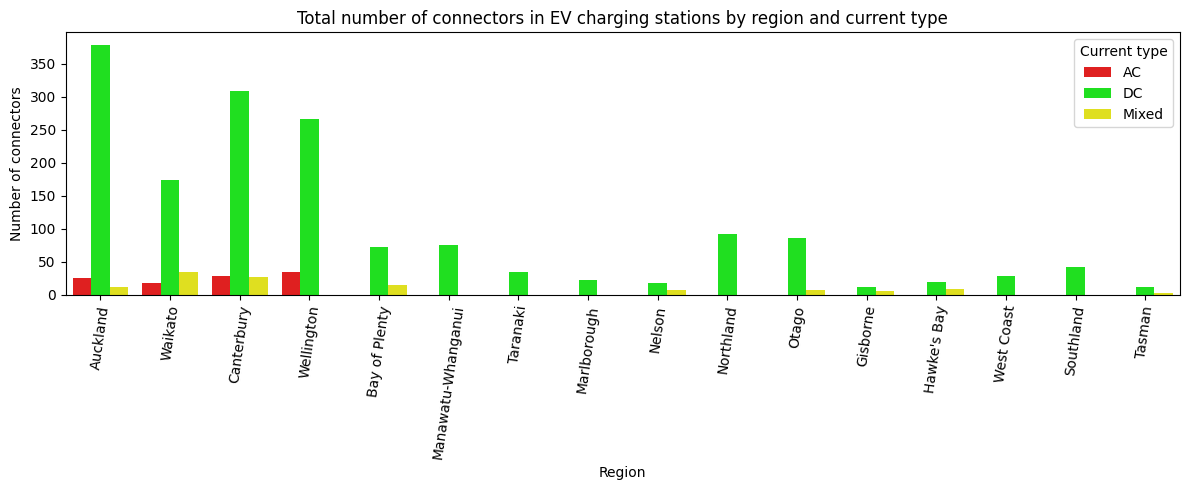

In [98]:
plt.figure(figsize=(12,5))
custom_palette = {"AC":"red","DC":"lime","Mixed":"yellow"}
seaborn.barplot(data=ev_charging_stations,x="region",y="number_of_connectors",hue="current_type",errorbar=None,estimator="sum",palette=custom_palette)
plt.xticks(rotation=82)
plt.xlabel("Region")
plt.ylabel("Number of connectors")
plt.legend(title="Current type")
plt.title("Total number of connectors in EV charging stations by region and current type")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/total_number_of_connectors_in_ev_charging_stations_by_region_and_current_type.png");

#### 💡**Insights:**
- Auckland has the highest number of connectors in the EV charging stations among all the other regions.
- DC connectors are more prevalent in all the EV charging stations of New Zealand, thus making fast-charging an easily accessible option for customers.
- EV charging stations with only AC connectors are available in the Auckland, Waikato, Canterbury, and Wellington regions.
- There are no EV charging stations in Wellington that provide mixed current type connectors.
- Mixed current connectors are not available in the EV charging stations of Manawatu-Whanganui, Taranaki, Marlborough, Nelson, Northland, Otago, Gisborne, Hawke's Bay, West Coast, Southland, and Tasman regions.

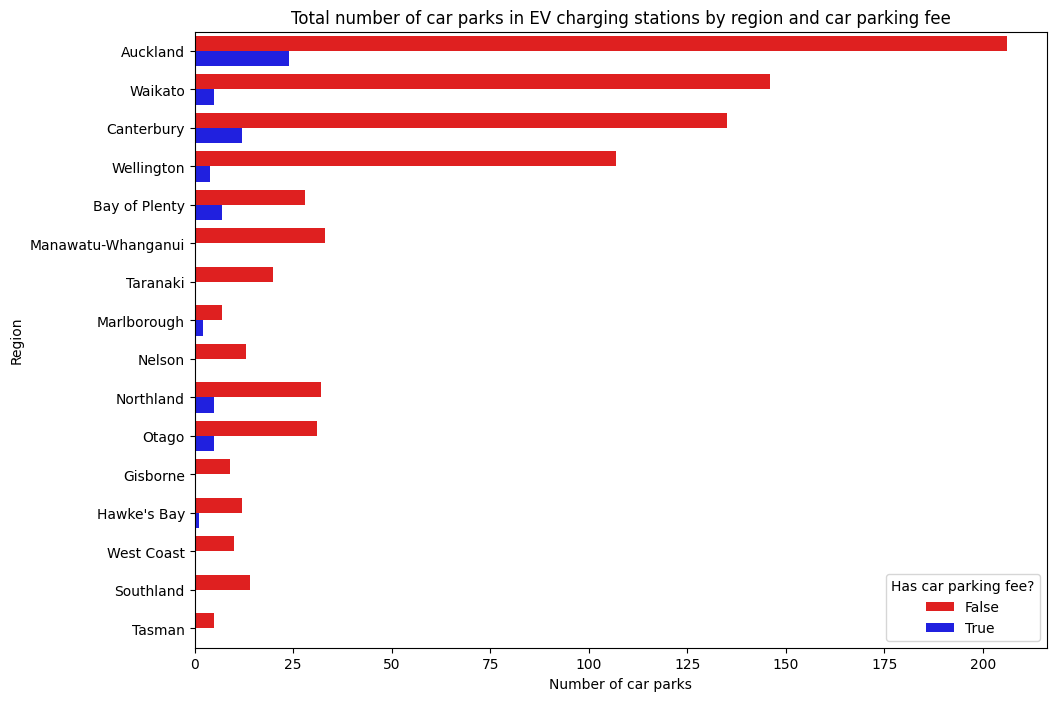

In [99]:
plt.figure(figsize=(11,8))
custom_palette = {False:"red",True:"blue"}
seaborn.barplot(data=ev_charging_stations,y="region",x="car_park_count",errorbar=None,estimator="sum",hue="has_carpark_cost",palette=custom_palette)
plt.xlabel("Number of car parks")
plt.ylabel("Region")
plt.legend(title="Has car parking fee?")
plt.title("Total number of car parks in EV charging stations by region and car parking fee")
plt.savefig("/kaggle/working/plots/total_number_of_car_parks_in_ev_charging_stations_by_region_and_car_parking_fee.png");

#### 💡**Insights:**
- Auckland has the highest number of EV charging stations with car parks, followed by Waikato in the second place, and Canterbury in the third place.
- Around 25 car parks in the Auckland region has car parking fee.
- The number of paid car parks are far less compared to the number of free car parks in every region of New Zealand.
- All the EV charging stations in Manawatu-Whanganui, Taranaki, West Coast, Southland, Tasman, and Nelson regions have free car parks.

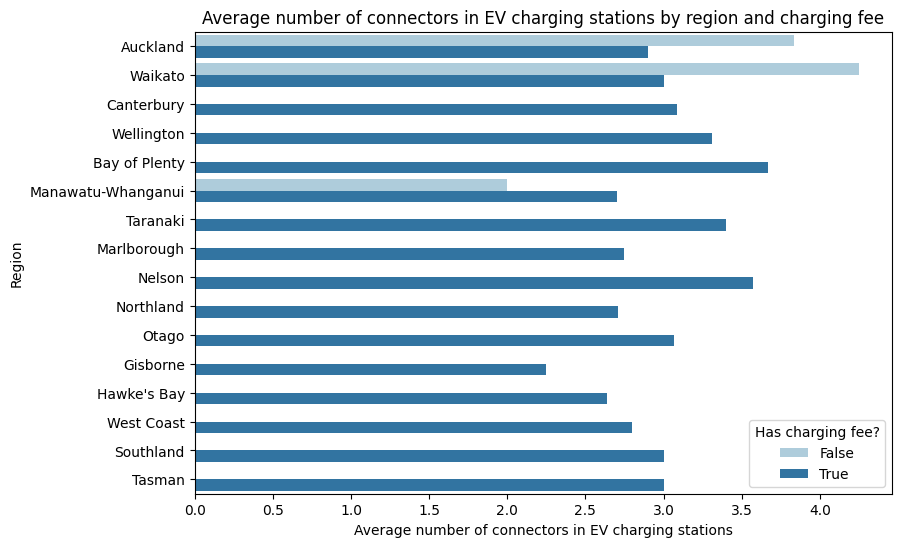

In [100]:
plt.figure(figsize=(9,6))
seaborn.barplot(data=ev_charging_stations,y="region",x="number_of_connectors",errorbar=None,hue="has_charging_cost",palette="Paired",estimator="mean")
plt.xlabel("Average number of connectors in EV charging stations")
plt.ylabel("Region")
plt.title("Average number of connectors in EV charging stations by region and charging fee")
plt.legend(title="Has charging fee?")
plt.savefig("/kaggle/working/plots/average_number_of_connectors_in_ev_charging_stations_by_region_and_charging_fee.png");

#### 💡**Insights:**
- Few of the EV charging stations in Auckland, Waikato, and Manawatu-Whanganui have free charging.
- All regions in New Zealand has EV charging stations with charging fee.

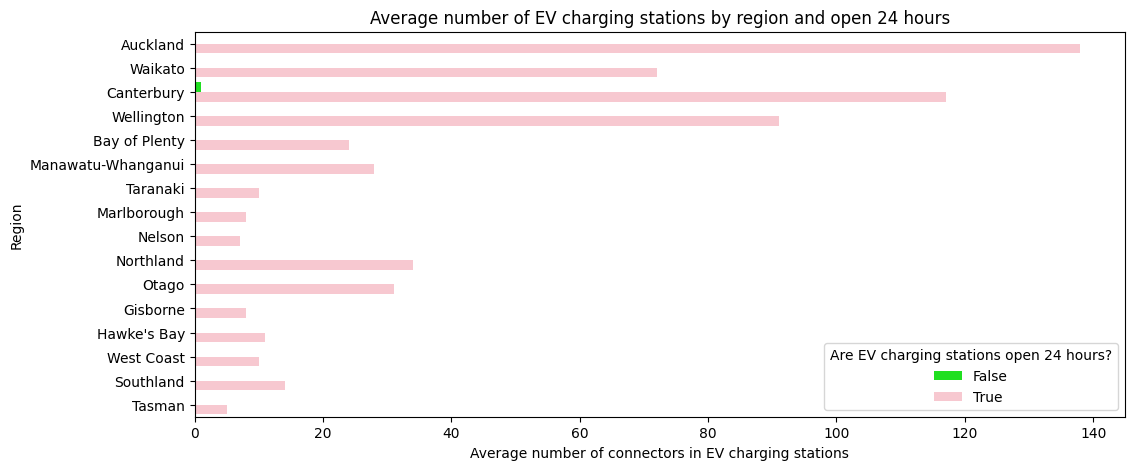

In [101]:
plt.figure(figsize=(12,5))
custom_palette = {False:"lime",True:"pink"}
seaborn.barplot(data=ev_charging_stations,y="region",x="number_of_connectors",errorbar=None,hue="is_open_24_hours",estimator="count",palette=custom_palette)
plt.xlabel("Average number of connectors in EV charging stations")
plt.ylabel("Region")
plt.title("Average number of EV charging stations by region and open 24 hours")
plt.legend(title="Are EV charging stations open 24 hours?")
plt.savefig("/kaggle/working/plots/average_number_of_ev_charging_stations_by_region_and_open_24_hours.png");

#### 💡**Insights:**
- All the regions except Canterbury have EV charging stations that are open 24 hours.
- Canterbury has most of the EV charging stations that are open 24 hours, and less than 5 charging stations that are not open for 24 hours.

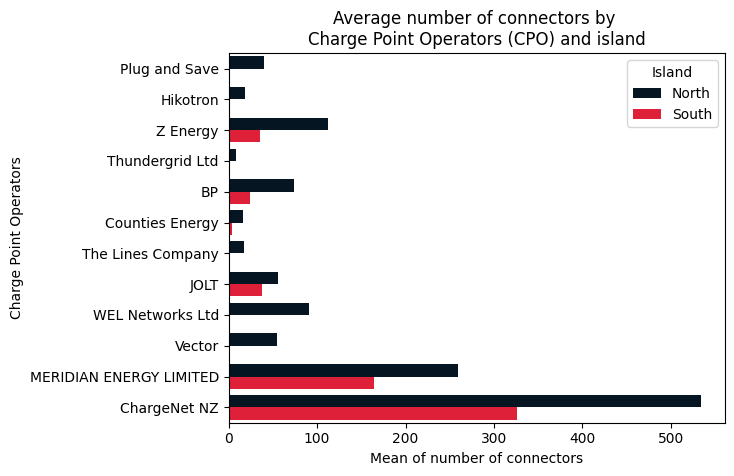

In [102]:
custom_palette = {"North":"#011627","South":"#ff0022"}
seaborn.barplot(data=ev_charging_stations,y="charge_point_operator",x="number_of_connectors",errorbar=None,hue="island",palette=custom_palette,estimator="sum")
plt.xlabel("Mean of number of connectors")
plt.ylabel("Charge Point Operators")
plt.title("Average number of connectors by \nCharge Point Operators (CPO) and island")
plt.legend(title="Island")
plt.savefig("/kaggle/working/plots/average_number_of_connectors_by_charge_point_operators_and_island.png")

#### 💡**Insights:**
- The average number of connectors by each Charge Point Operators are higher in the North island than in the South island.
- Plug and Save, Hikotron, Thundergrid Ltd, The Lines Company, WEL Networks Ltd, and Vector are the CPO with no connectors in the South island.
- ChargeNet NZ has an average of around 520 connectors in the North island, and an average of 330 connectors in the South island.

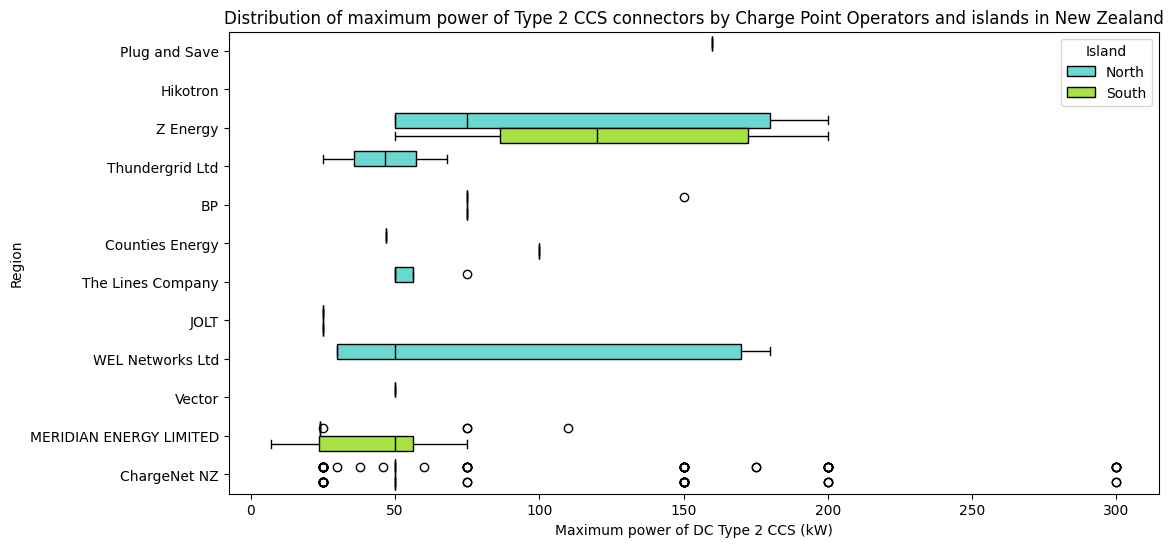

In [103]:
plt.figure(figsize=(12,6))
custom_palette={"North":"#57ebde","South":"#aefb2a"}
seaborn.boxplot(data=ev_charging_stations,y="charge_point_operator",x="max_dc_type_2_ccs_power_kw",hue="island",linecolor="k",palette=custom_palette)
plt.ylabel("Region")
plt.xlabel("Maximum power of DC Type 2 CCS (kW)")
plt.title("Distribution of maximum power of Type 2 CCS connectors by Charge Point Operators and islands in New Zealand")
plt.legend(title="Island")
plt.savefig("/kaggle/working/plots/distribution_of_the_maximum_power_of_type_2_ccs_connectors_by_charge_point_operators.png");

#### 💡**Insights:**
- Most of the connectors of ChargeNet NZ have maximum power of 50 kW for the DC Type 2 CCS connectors.
- Few of the DC Type 2 connectors of ChargeNet NZ have maximum power as high as 300 kw, and low as around 25 kW both in the North and South island.
- Most of the DC Type 2 CCS connectors of Z Energy have the maximum power ranging between 50 to 180 kW in the North island, and between 90 to 170 kW in the South island.

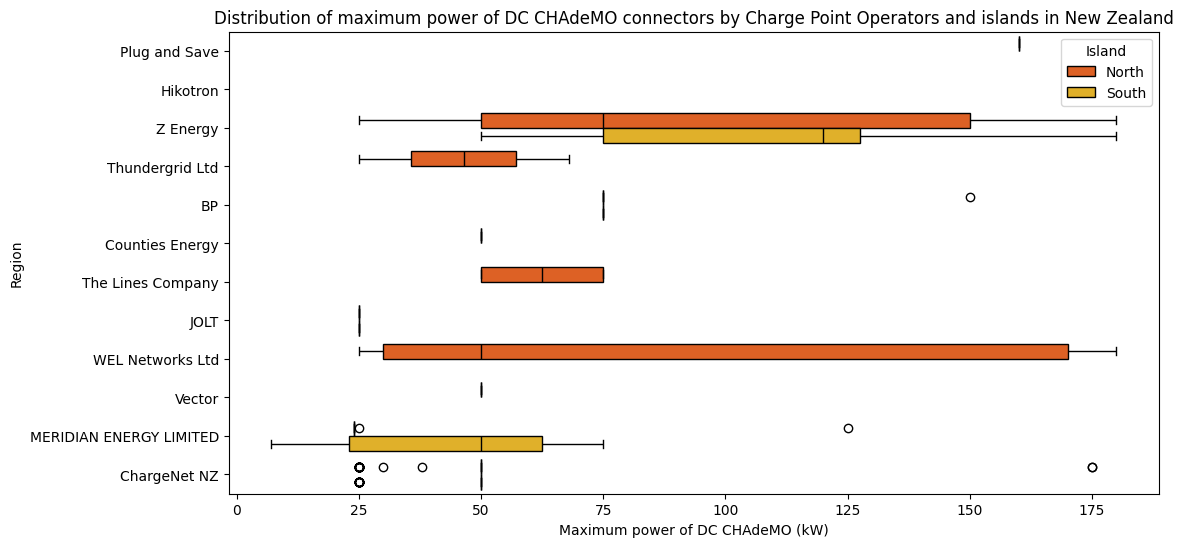

In [104]:
plt.figure(figsize=(12,6))
custom_palette={"North":"#fb5607","South":"#ffbe0b"}
seaborn.boxplot(data=ev_charging_stations,y="charge_point_operator",x="max_dc_chademo_power_kw",hue="island",linecolor="k",palette=custom_palette)
plt.ylabel("Region")
plt.xlabel("Maximum power of DC CHAdeMO (kW)")
plt.title("Distribution of maximum power of DC CHAdeMO connectors by Charge Point Operators and islands in New Zealand")
plt.legend(title="Island")
plt.savefig("/kaggle/working/plots/distribution_of_the_maximum_power_of_dc_chademo_connectors_by_charge_point_operators_and_islands_in_nz.png");

#### 💡**Insights:**
- The maximum power of DC CHAdeMO connectors in the North island by WEL Networks Ltd, and Z Energy are higher upto 175 kW.
- WEL Networks have DC CHAdeMO connectors only in the North island.

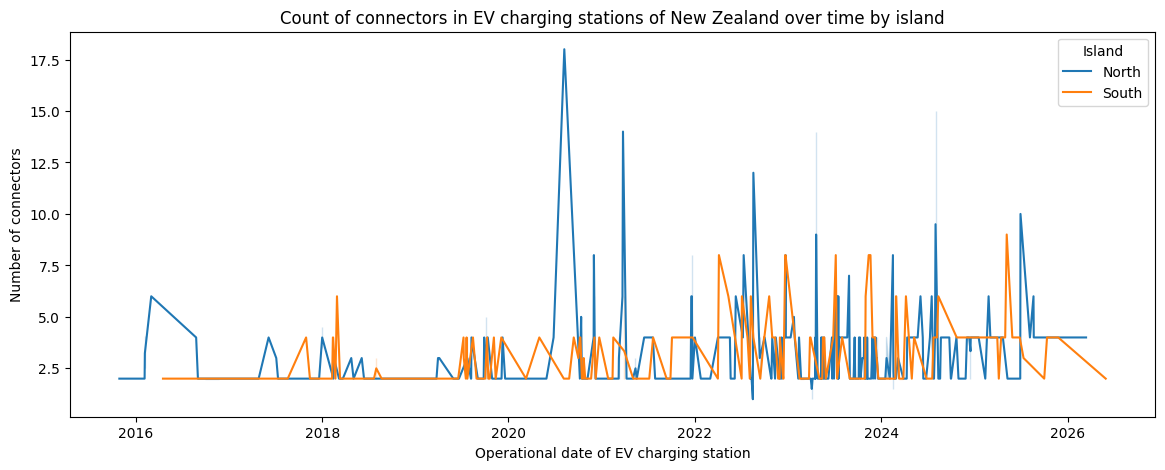

In [105]:
plt.figure(figsize=(14,5))
seaborn.lineplot(data=ev_charging_stations,x="date_first_operational",y="number_of_connectors",hue="island")
plt.xlabel("Operational date of EV charging station")
plt.ylabel("Number of connectors")
plt.title("Count of connectors in EV charging stations of New Zealand over time by island")
plt.legend(title="Island")
plt.savefig("/kaggle/working/plots/count_of_connectors_in_ev_charging_stations_of_new_zealand_over_time_by_island.png");

#### 💡**Insights:**
- The number of connectors in newly opened EV charging stations in 2016 was about 6 to 7, which got increased to around 17 connectors in the EV charging stations opened in the middle of 2020 in the North island.
- The number of connectors in the South island has increased from 6 in the EV charging stations opened in 2018 to 8 connectors in the EV charging stations opened in the year 2025.

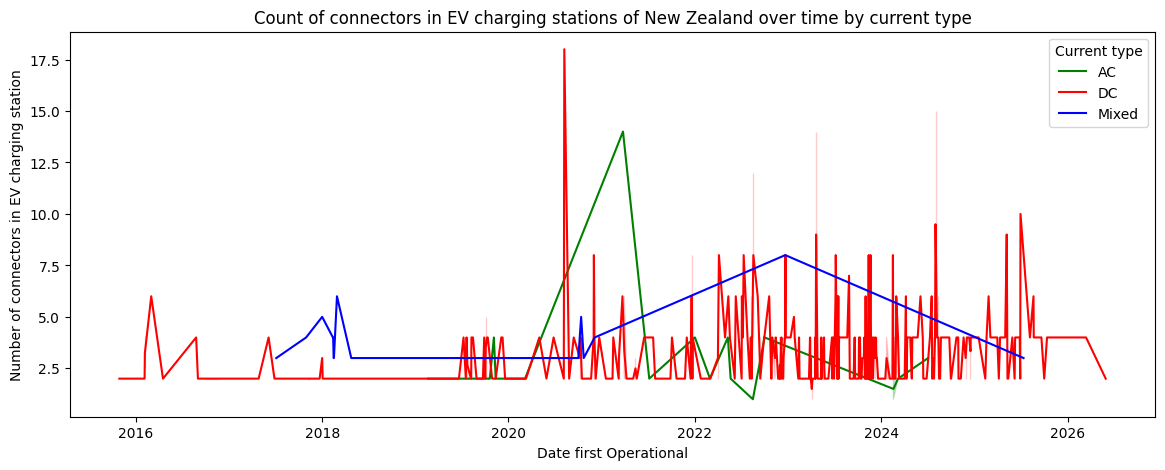

In [106]:
plt.figure(figsize=(14,5))
custom_palette = {"AC":"green","DC":"red","Mixed":"blue"}
seaborn.lineplot(data=ev_charging_stations,x="date_first_operational",y="number_of_connectors",hue="current_type",palette=custom_palette)
plt.xlabel("Date first Operational")
plt.ylabel("Number of connectors in EV charging station")
plt.legend(title="Current type")
plt.title("Count of connectors in EV charging stations of New Zealand over time by current type")
plt.savefig("/kaggle/working/plots/count_of_connectors_in_ev_charging_stations_of_nz_over_time_by_current_type.png");

#### 💡**Insights:**
- The number of EV charging stations with connectors having DC type have increased from 2 connectors in the year 2016 to around 17 connectors in the EV charging stations opened in the mid of 2020.
- The number of AC connectors in EV charging stations have increased in the year 2023, and then gradually decreased to around 3 connectors in the EV charging stations opened in the mid of 2025.
- The number of EV charging stations having AC connectors are not opened since the mid of the year 2025.

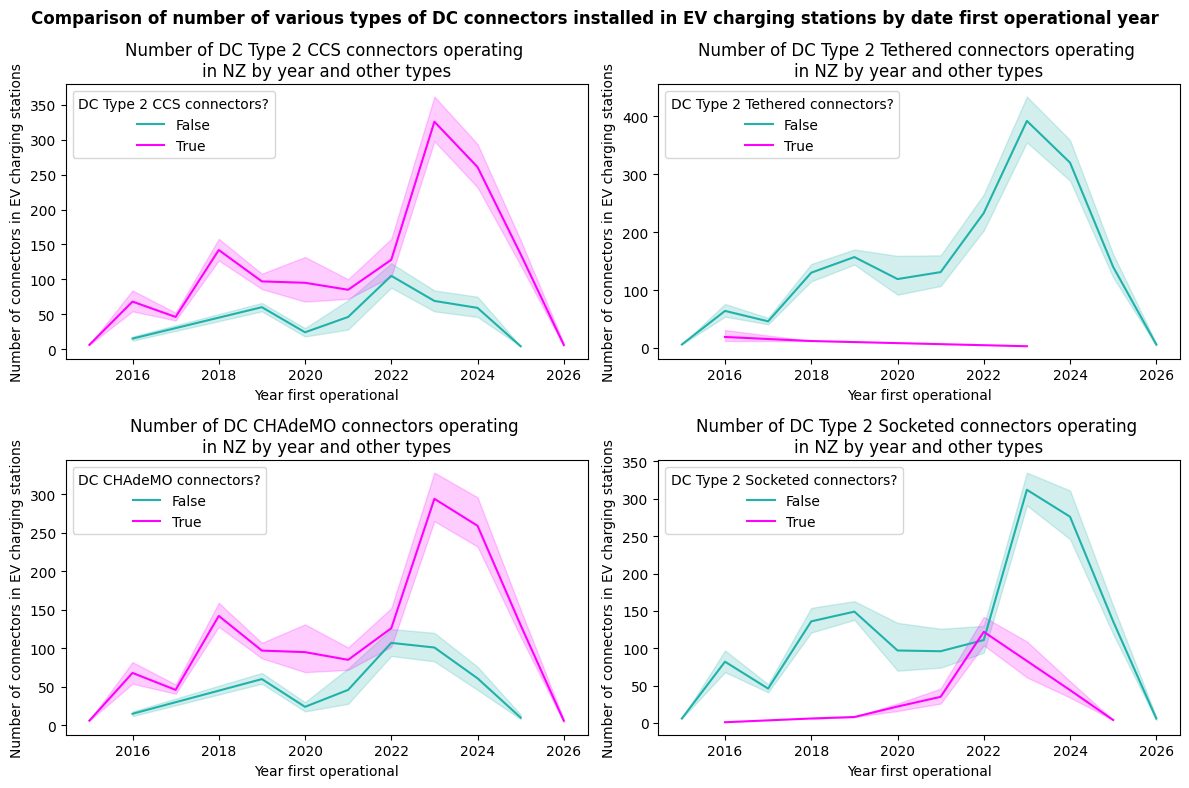

In [107]:
f,ax = plt.subplots(2,2,figsize=(12,8))
custom_palette = {True:"magenta",False:"lightseagreen"}
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="dc_type_2_ccs_connector",ax=ax[0,0],estimator="sum",palette=custom_palette)
ax[0,0].legend(title="DC Type 2 CCS connectors?")
ax[0,0].set_title("Number of DC Type 2 CCS connectors operating \nin NZ by year and other types")
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="dc_type_2_tethered_connector",ax=ax[0,1],estimator="sum",palette=custom_palette)
ax[0,1].legend(title="DC Type 2 Tethered connectors?")
ax[0,1].set_title("Number of DC Type 2 Tethered connectors operating \nin NZ by year and other types")
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="dc_chademo_connector",ax=ax[1,0],estimator="sum",palette=custom_palette)
ax[1,0].legend(title="DC CHAdeMO connectors?")
ax[1,0].set_title("Number of DC CHAdeMO connectors operating \nin NZ by year and other types")
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="dc_type_2_socketed_connector",ax=ax[1,1],estimator="sum",palette=custom_palette)
ax[1,1].legend(title="DC Type 2 Socketed connectors?")
ax[1,1].set_title("Number of DC Type 2 Socketed connectors operating \nin NZ by year and other types")
for subplot_row in range(2):
  for subplot_col in range(2):
    ax[subplot_row,subplot_col].set_xlabel("Year first operational")
    ax[subplot_row,subplot_col].set_ylabel("Number of connectors in EV charging stations")
plt.suptitle("Comparison of number of various types of DC connectors installed in EV charging stations by date first operational year",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_number_of_various_types_of_dc_connectors_installed_in_ev_charging_stations_by_date_first_operational_year.png");

#### 💡**Insights:**
- The number of EV charging stations with DC Type 2 CCS connectors have gradually increased from the year 2021 and peaked to more than 300 connectors in the year 2023.
- The number of DC Type 2 CCS connectors installed have reduced from the year 2024 slowly.
- The number of EV charging stations opened with DC Type 2 Tethered connectors have decreased from the year 2016 till 2023, and are not available after 2023.
- The number of EV charging stations with DC CHAdeMO connectors opened in the year 2021 has gradually increased till the year 2023.
- The number of EV charging stations with DC Type 2 Socketed connectors that are opened in the year 2019 has gradually increased to more than 100 connectors in the charging stations opened in the year 2022, followed by deep decline in the year 2025.

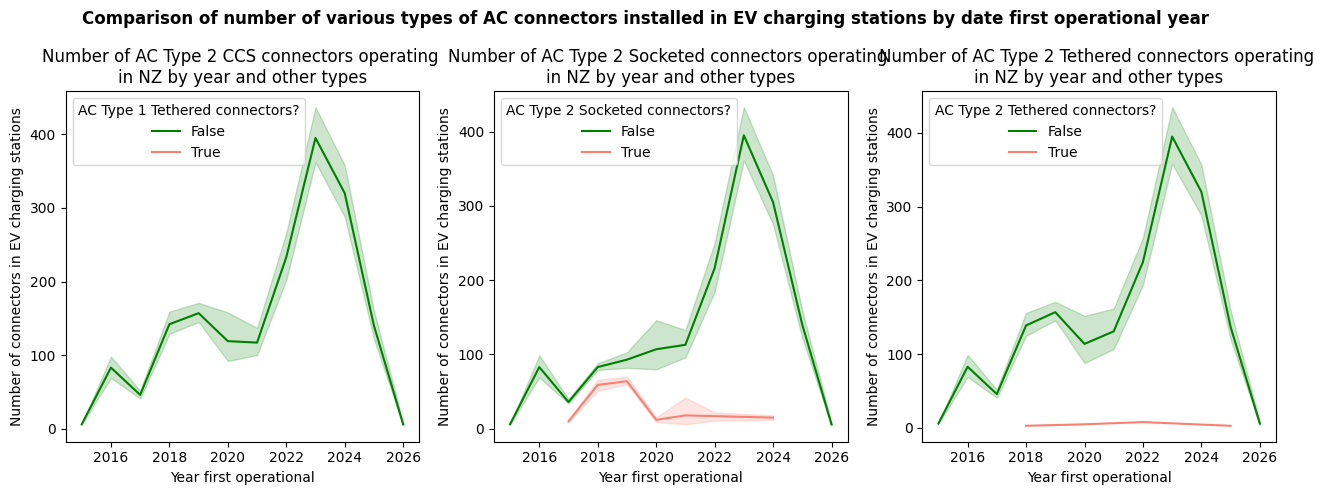

In [108]:
f,ax = plt.subplots(1,3,figsize=(13,5))
custom_palette = {True:"salmon",False:"green"}
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="ac_type_1_tethered_connector",ax=ax[0],estimator="sum",palette=custom_palette)
ax[0].legend(title="AC Type 1 Tethered connectors?")
ax[0].set_title("Number of AC Type 2 CCS connectors operating \nin NZ by year and other types")
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="ac_type_2_socketed_connector",ax=ax[1],estimator="sum",palette=custom_palette)
ax[1].legend(title="AC Type 2 Socketed connectors?")
ax[1].set_title("Number of AC Type 2 Socketed connectors operating \nin NZ by year and other types")
seaborn.lineplot(data=ev_charging_stations,x="operational_year",y="number_of_connectors",hue="ac_type_2_tethered_connector",ax=ax[2],estimator="sum",palette=custom_palette)
ax[2].legend(title="AC Type 2 Tethered connectors?")
ax[2].set_title("Number of AC Type 2 Tethered connectors operating \nin NZ by year and other types")
for _ in range(3):
    ax[_].set_xlabel("Year first operational")
    ax[_].set_ylabel("Number of connectors in EV charging stations")
plt.suptitle("Comparison of number of various types of AC connectors installed in EV charging stations by date first operational year",fontweight="bold")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/comparison_of_number_of_various_types_of_ac_connectors_installed_in_ev_charging_stations_by_date_first_operational_year.png");

#### 💡**Insights:**
- The number of EV charging stations with AC Type 2 socketed connectors have started in the year 2017 and increased to around 75 connectors in the charging stations opened in the year 2019.
- The number of EV charging stations with AC Type 2 socketed connectors are not present after the year 2024.
- The number of EV charging stations with AC Type 2 tethered connectors are less than 5 between the years 2018 to 2025.

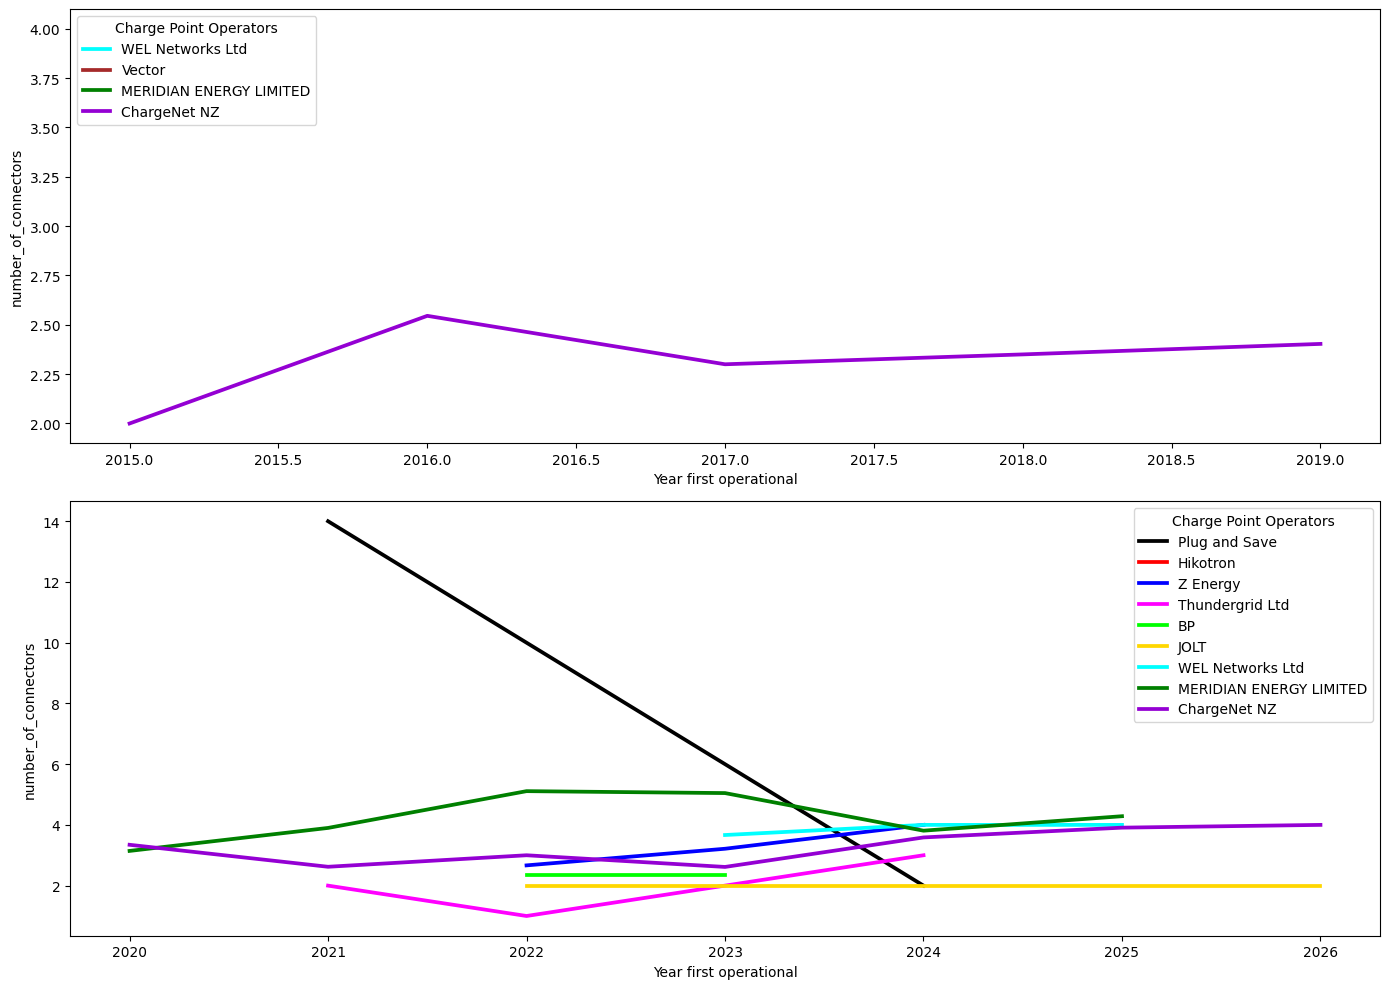

In [109]:
custom_palette = {"Plug and Save":"black","Hikotron":"red","Z Energy":"blue","Thundergrid Ltd":"magenta","BP":"lime","The Lines Company":"orangered","JOLT":"gold","WEL Networks Ltd":"cyan","Vector":"brown","MERIDIAN ENERGY LIMITED":"green","ChargeNet NZ":"darkviolet","Counties Energy":"pink"}
f,ax = plt.subplots(2,1,figsize=(14,10))
seaborn.lineplot(data=ev_charging_stations[ev_charging_stations["operational_year"]<2020],x="operational_year",y="number_of_connectors",hue="charge_point_operator",linewidth=2.7,palette=custom_palette,errorbar=None,ax=ax[0])
seaborn.lineplot(data=ev_charging_stations[ev_charging_stations["operational_year"]>=2020],x="operational_year",y="number_of_connectors",hue="charge_point_operator",linewidth=2.7,palette=custom_palette,errorbar=None,ax=ax[1])
for _ in range(2):
  ax[_].set_xlabel("Year first operational")
  ax[_].legend(title="Charge Point Operators")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/total_number_of_connectors_in_ev_charging_stations_by_year_of_establishment_and_charge_point_operators.png");

#### 💡**Insights:**
- The number of EV charging stations with ChargeNet NZ has grown steadily from 2 connectors in 2015 to upto 4 connectors in the EV charging stations opened in the year 2026.
- ChargeNet NZ has been the CPO for most of the EV charging stations opened before the year 2020.
- The EV charging stations opened in the year 2021 with Plug and Save as the Charge Point Operator with nearly 14 connectors, had a sharp decline in the number of EV charging stations opened in the year 2024.

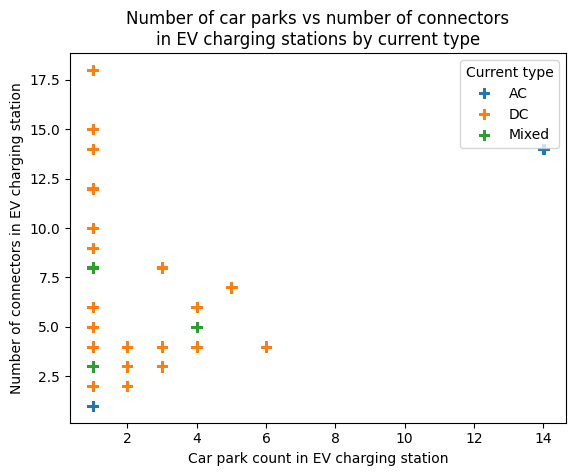

In [110]:
seaborn.scatterplot(data=ev_charging_stations,x="car_park_count",y="number_of_connectors",marker="P",s=80,hue="current_type")
plt.xlabel("Car park count in EV charging station")
plt.ylabel("Number of connectors in EV charging station")
plt.title("Number of car parks vs number of connectors\nin EV charging stations by current type")
plt.legend(title="Current type")
plt.savefig("/kaggle/working/plots/number_of_car_parks_vs_number_of_connectors_in_ev_charging_stations_by_current_type.png");

#### 💡**Insights:**
- The lesser number of car parks in EV charging stations, higher the number of DC connectors in that EV charging stations.
- The number of mixed connectors in the EV charging stations with only one car park is less to around 3 and 8.

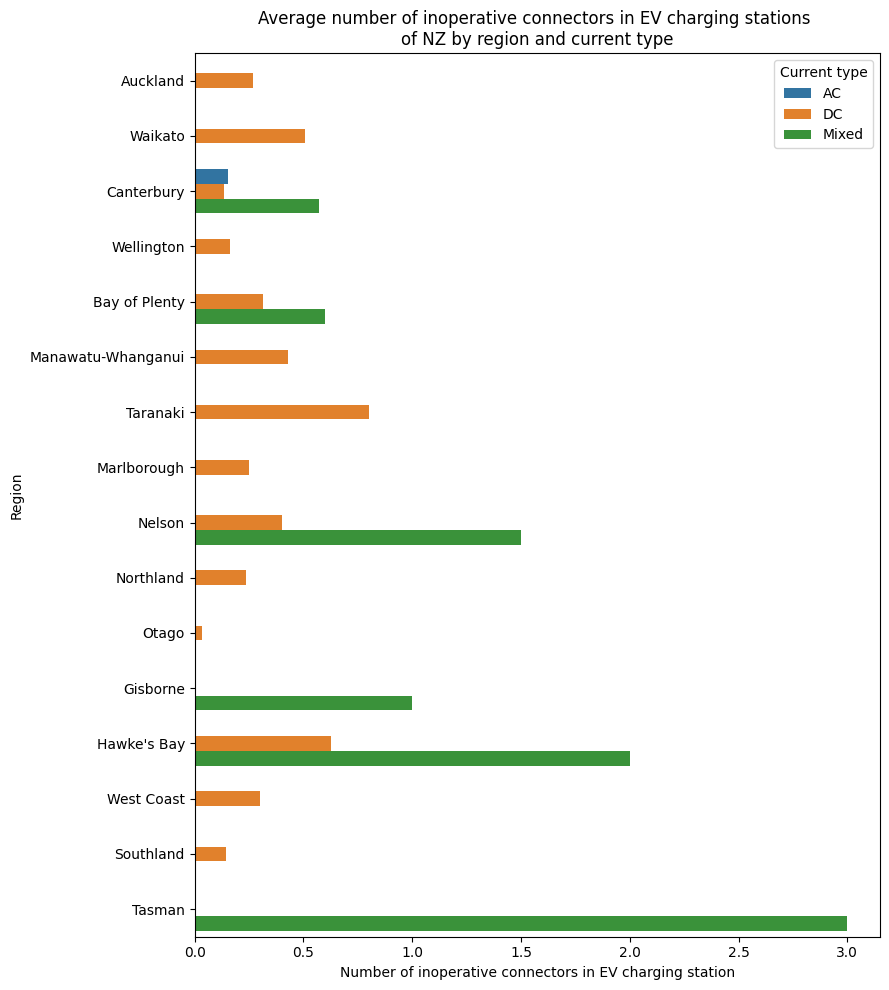

In [111]:
plt.subplots(figsize=(9,10))
seaborn.barplot(data=ev_charging_stations,y="region",x="inoperative_status_connectors",hue="current_type",errorbar=None)
plt.xlabel("Number of inoperative connectors in EV charging station")
plt.ylabel("Region")
plt.title("Average number of inoperative connectors in EV charging stations \nof NZ by region and current type")
plt.legend(title="Current type")
plt.tight_layout()
plt.savefig("/kaggle/working/plots/average_number_of_inoperative_connectors_in_ev_charging_stations_of_nz_by_region_and_current_type.png");

#### 💡**Insights:**
- Auckland has inoperative connectors of DC type.
- The EV charging stations in the Taranaki region have inoperative DC connectors.
- The EV charging stations in the Tasman region have an average of 3 inoperative connectors of mixed current type, and have no inoperative connectors in EV charging stations having AC and DC type.

#### **Geographical Locations of EV charging stations in New Zealand**

In [112]:
fig = px.scatter_map(ev_charging_stations,lat="latitude",lon="longitude",color_discrete_sequence=["#38b000"],hover_name="location_name",hover_data=["charge_point_operator","is_open_24_hours","has_carpark_cost"],title="Geographical locations of EV charging stations in New Zealand")
fig.update_geos(scope='world',center=dict(lat=-41.0, lon=173.0),projection_scale=10,visible=True)
fig.update_traces(marker=dict(size=8,symbol="fuel"))
fig.update_layout(title_font_color="black",title_x=0.5)

#### **EV charging stations in New Zealand by current type**

In [113]:
fig = px.scatter_map(ev_charging_stations, lat="latitude",lon="longitude",color="current_type",title="EV charging stations in NZ by current type")
fig.update_layout(legend_title_text="Current type",title_font_color="black",title_x=0.5,font_color="black")
fig.show()

#### **EV charging stations in New Zealand by maximum power of DC Type 2 CCS connector**s

In [114]:
fig = px.scatter_map(ev_charging_stations, lat="latitude",lon="longitude",color="max_dc_type_2_ccs_power_kw",color_continuous_scale="rainbow",title="EV charging stations in New Zealand by maximum power of DC Type 2 CCS (kW)")
fig.update_layout(coloraxis_colorbar_title_text="",title_x=0.5,title_font_color="black")
fig.update_traces(marker=dict(size=9))
fig.show()

# ⭐**Key Insights**
- Auckland has the highest number of EV charging stations, because of the highest population in the Auckland region.
- North island has more number of EV charging stations than the South island, indicating that the distribution of population is high in North island, and EV adoption is high.
- DC connectors are widely used than AC connectors in New Zealand, indicating that travelling to long distance is not a hassle because of fast charging DC connectors in stations.
- Most of the EV charging stations have free parking which shows there is much convenience for EV users.
- The fastest charging connector in the EV charging stations of New Zealand is DC Type 2 CCS connector with a maximum of 300 kW power, and more than 450 stations have it. This shows there is good infrastructure for EV buyers in New Zealand, which can further increase the sales of electric vehicles in New Zealand.
- More than 90% of EV charging stations in New Zealand has no maximum time limit for charging, which makes the EV users worry-free to access and charge their vehicles anytime.
- ChargeNet NZ is the major player as the Charge Point Operator, because the number of EV charging stations and connectors powered by ChargeNet NZ is higher. It indicates that ChargeNet NZ has a strong market presence in the EV sector.
- The regions of South island such as Tasman, Nelson, Gisborne has less number of EV charging stations which suggests EV expansion opportunities for new companies in the South island.
- The fastest charging DC connectors such as Type 2 CCS and CHAdeMO with 300 kW power is present in 4 regions in the North island, but only Canterbury region in the South island has the highest power connectors. This highlights the gap in fast charging environment for the other regions in the South island.
- The number of inoperative connectors are high in Auckland, Waikato, and Canterbury regions, which reflects that EV users in highly populated regions like Auckland can have some issues in few EV charging stations and those connectors needs to be repaired and maintained.
- The number of EV charging stations opened in 2023 is very high than between the years 2016 and 2022, which indicates that the number of electric vehicle users has significantly increased from the year 2023 in New Zealand.